## Descàrrega i emmagatzematge de dades històriques

En aquest bloc es descarreguen les dades històriques de les empreses seleccionades del S&P 500 mitjançant la llibreria `yfinance`.

Tot i disposar d'una llista àmplia de tickers del S&P 500, en aquesta fase del projecte es treballa amb una selecció reduïda d'empreses. Això permet validar primer tot el procés de descàrrega, neteja, etiquetatge i generació d'imatges abans d'escalar el pipeline a un conjunt més gran.

Les dades es descarreguen per al període comprès entre l'1 de gener de 2015 i l'1 de gener de 2026. La descàrrega es fa amb `auto_adjust=False`, ja que així es conserven les columnes originals retornades per Yahoo Finance: `Open`, `High`, `Low`, `Close`, `Adj Close` i `Volume`.

Els resultats es guarden en dues carpetes diferents:

1. **`data/raw/raw_yfinance_full.csv`**
   Conté totes les dades descarregades sense aplicar cap processament. Aquest fitxer es conserva com a còpia original per poder tornar-hi en cas que sigui necessari.

2. **`data/ohlc/ohlc_data.csv`**
   Conté únicament les columnes `Open`, `High`, `Low` i `Close`, que són les dades necessàries per generar els gràfics de veles japoneses utilitzats en el projecte.

Aquesta separació ajuda a mantenir una estructura més ordenada: d'una banda es conserven les dades originals i, de l'altra, les dades preparades per continuar amb la resta del pipeline.

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import os

# Llista manual de tickers del S&P 500 utilitzada com a punt de partida
sp500_tickers = [
    'A', 'AAPL', 'ABNB', 'ABBV', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM',
    'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB',
    'ALGN', 'ALL', 'ALLE', 'AMAT', 'AMCR', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT',
    'AMZN', 'ANET', 'AON', 'AOS', 'APA', 'APD', 'APH', 'APO', 'APP', 'APTV', 'ARE', 'ARES',
    'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX',
    'BBY', 'BDX', 'BEN', 'BF.B', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR',
    'BLK', 'BMY', 'BR', 'BRK.B', 'BRO', 'BSX', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CARR', 'CASY',
    'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'CDW', 'CEG', 'CF', 'CFG',
    'CHD', 'CHRW', 'CHTR', 'CI', 'CIEN', 'CINF', 'CL', 'CLX', 'CMA', 'CMCSA', 'CME', 'CMG',
    'CMI', 'CMS', 'CNC', 'CNP', 'COF', 'COHR', 'COIN', 'COO', 'COP', 'COST', 'CPAY', 'CPB', 'CPRT',
    'CPT', 'CRH', 'CRL', 'CRM', 'CRWD', 'CSCO', 'CSGP', 'CSX', 'CTAS', 'CTRA', 'CTSH', 'CTVA', 'CVNA', 'CVS',
    'CVX', 'D', 'DAL', 'DASH', 'DD', 'DDOG', 'DE', 'DECK', 'DELL', 'DG', 'DGX', 'DHI', 'DHR',
    'DIS', 'DLR', 'DLTR', 'DOC', 'DOV', 'DOW', 'DPZ', 'DRI', 'DTE', 'DUK', 'DVA',
    'DVN', 'DXCM', 'EA', 'EBAY', 'ECL', 'ED', 'EFX', 'EG', 'EIX', 'EL', 'ELV', 'EME',
    'EMR', 'EOG', 'EPAM', 'EQIX', 'EQR', 'EQT', 'ERIE', 'ES', 'ESS', 'ETN',
    'ETR', 'EVRG', 'EW', 'EXC', 'EXE', 'EXPD', 'EXPE', 'EXR', 'F', 'FANG', 'FAST', 'FCX',
    'FDS', 'FDX', 'FE', 'FFIV', 'FICO', 'FIS', 'FISV', 'FITB', 'FIX', 'FOX',
    'FOXA', 'FRT', 'FSLR', 'FTNT', 'FTV', 'GD', 'GDDY', 'GE', 'GEHC', 'GEN', 'GEV', 'GILD',
    'GIS', 'GL', 'GLW', 'GM', 'GNRC', 'GOOG', 'GOOGL', 'GPC', 'GPN', 'GRMN', 'GS',
    'GWW', 'HAL', 'HAS', 'HBAN', 'HCA', 'HD', 'HIG', 'HII', 'HLT',
    'HON', 'HOOD', 'HPE', 'HPQ', 'HRL', 'HSIC', 'HST', 'HSY', 'HUBB', 'HUM', 'HWM', 'IBKR', 'IBM',
    'ICE', 'IDXX', 'IEX', 'IFF', 'INCY', 'INTC', 'INTU', 'INVH', 'IP', 'IQV',
    'IR', 'IRM', 'ISRG', 'IT', 'ITW', 'IVZ', 'J', 'JBHT', 'JBL', 'JCI', 'JKHY',
    'JNJ', 'JPM', 'KDP', 'KEY', 'KEYS', 'KHC', 'KIM', 'KKR', 'KLAC',
    'KMB', 'KMI', 'KO', 'KR', 'KVUE', 'L', 'LDOS', 'LEN', 'LH', 'LHX', 'LII',
    'LIN', 'LITE', 'LLY', 'LMT', 'LNT', 'LOW', 'LRCX', 'LULU', 'LUV', 'LVS',
    'LYB', 'LYV', 'MA', 'MAA', 'MAR', 'MAS', 'MCD', 'MCHP', 'MCK', 'MCO', 'MDLZ', 'MDT',
    'MET', 'META', 'MGM', 'MKC', 'MLM', 'MMM', 'MNST', 'MO',
    'MOS', 'MPC', 'MPWR', 'MRK', 'MRNA', 'MRSH', 'MS', 'MSCI', 'MSFT', 'MSI', 'MTB',
    'MTD', 'MU', 'NCLH', 'NDAQ', 'NDSN', 'NEE', 'NEM', 'NFLX', 'NI', 'NKE',
    'NOC', 'NOW', 'NRG', 'NSC', 'NTAP', 'NTRS', 'NUE', 'NVDA', 'NVR', 'NWS', 'NWSA',
    'NXPI', 'O', 'ODFL', 'OKE', 'OMC', 'ON', 'ORCL', 'ORLY', 'OTIS', 'OXY', 'PANW',
    'PAYX', 'PCAR', 'PCG', 'PEG', 'PEP', 'PFE', 'PFG', 'PG', 'PGR',
    'PH', 'PHM', 'PKG', 'PLD', 'PLTR', 'PM', 'PNC', 'PNR', 'PNW', 'PODD', 'POOL', 'PPG',
    'PPL', 'PRU', 'PSA', 'PSKY', 'PSX', 'PTC', 'PWR', 'PYPL', 'Q', 'QCOM', 'RCL', 'REG',
    'REGN', 'RF', 'RJF', 'RL', 'RMD', 'ROK', 'ROL', 'ROP', 'ROST', 'RSG', 'RTX',
    'RVTY', 'SATS', 'SBAC', 'SBUX', 'SCHW', 'SHW', 'SJM', 'SLB', 'SMCI', 'SNA', 'SNDK', 'SNPS',
    'SO', 'SOLV', 'SPG', 'SPGI', 'SRE', 'STE', 'STLD', 'STT', 'STX', 'STZ', 'SW',
    'SWK', 'SWKS', 'SYF', 'SYK', 'SYY', 'T', 'TAP', 'TDG', 'TDY', 'TECH', 'TEL',
    'TER', 'TFC', 'TGT', 'TJX', 'TKO', 'TMO', 'TMUS', 'TPL', 'TPR', 'TRGP', 'TRMB',
    'TROW', 'TRV', 'TSCO', 'TSLA', 'TSN', 'TT', 'TTD', 'TTWO', 'TXN', 'TXT', 'TYL', 'UAL',
    'UBER', 'UDR', 'UHS', 'ULTA', 'UNH', 'UNP', 'UPS', 'URI', 'USB', 'V', 'VICI',
    'VLO', 'VLTO', 'VMC', 'VRSK', 'VRSN', 'VRT', 'VRTX', 'VST', 'VTR', 'VTRS', 'VZ', 'WAB', 'WAT',
    'WBD', 'WDAY', 'WDC', 'WEC', 'WELL', 'WFC', 'WM', 'WMB', 'WMT',
    'WRB', 'WSM', 'WST', 'WTW', 'WY', 'WYNN', 'XEL', 'XOM', 'XYL', 'XYZ', 'YUM', 'ZBH', 'ZBRA', 'ZTS'
]

NUM_TICKERS = 250
SEED = 42

# Tickers exclosos per evitar problemes durant la descàrrega o el processament
tickers_excluidos = {"CMA"}

# Adaptació del format dels tickers al format utilitzat per Yahoo Finance
sp500_tickers_yahoo = [
    ticker.replace(".", "-")
    for ticker in sp500_tickers
    if ticker not in tickers_excluidos
]

rng = np.random.default_rng(SEED)

tickers = rng.choice(
    sp500_tickers_yahoo,
    size=NUM_TICKERS,
    replace=False
).tolist()

tickers = sorted(tickers)

print("Nombre de tickers utilitzats:", len(tickers))
print("Tickers seleccionats:")
print(tickers)

# Definició de les carpetes de sortida
RAW_DIR = "data/raw"
OHLC_DIR = "data/ohlc"

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(OHLC_DIR, exist_ok=True)

# Descàrrega de les dades històriques
data = yf.download(
    tickers,
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=False,
    threads=True
)

# Emmagatzematge de les dades originals
data.to_csv(os.path.join(RAW_DIR, "raw_yfinance_full.csv"))

# Selecció de les columnes necessàries per generar les imatges OHLC
data_ohlc = data[["Open", "High", "Low", "Close"]].copy()

# Emmagatzematge de les dades OHLC
data_ohlc.to_csv(os.path.join(OHLC_DIR, "ohlc_data.csv"))

print(data_ohlc.head())

[                       0%                       ]

Número de tickers usados: 250
Tickers seleccionados:
['ABNB', 'ADM', 'ADSK', 'AEP', 'AJG', 'ALB', 'ALL', 'ALLE', 'AMAT', 'AMD', 'AMP', 'ANET', 'AOS', 'APH', 'APO', 'APP', 'ARE', 'ARES', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BG', 'BK', 'BKNG', 'BLK', 'BMY', 'BRO', 'BSX', 'BX', 'C', 'CAH', 'CBRE', 'CDNS', 'CDW', 'CEG', 'CHTR', 'CINF', 'CMCSA', 'CMS', 'CNC', 'COF', 'COHR', 'COIN', 'COST', 'CPB', 'CPRT', 'CRH', 'CRM', 'CSCO', 'CSGP', 'CTAS', 'CTRA', 'CTSH', 'CVNA', 'D', 'DASH', 'DE', 'DECK', 'DELL', 'DG', 'DGX', 'DHI', 'DLR', 'DOC', 'DPZ', 'DUK', 'DVA', 'DVN', 'DXCM', 'EA', 'EBAY', 'ED', 'EIX', 'EME', 'EOG', 'EQIX', 'EQR', 'EQT', 'ERIE', 'ES', 'ESS', 'EVRG', 'EXE', 'EXPE', 'F', 'FCX', 'FDX', 'FE', 'FISV', 'FOXA', 'FRT', 'FTNT', 'GE', 'GEHC', 'GEN', 'GILD', 'GL', 'GLW', 'GM', 'GNRC', 'GOOG', 'GOOGL', 'GPC', 'GRMN', 'GS', 'HAL', 'HBAN', 'HCA', 'HD', 'HIG', 'HII', 'HON', 'HOOD', 'HPQ', 'HRL', 'HSY', 'HUBB', 'HUM', 'IBM', 'ICE', 'IEX', 'INTC', 'IP', 'IR', 'ITW

[*********************100%***********************]  250 of 250 completed


Price      Open                                                         \
Ticker     ABNB        ADM       ADSK        AEP        AJG        ALB   
Date                                                                     
2015-01-02  NaN  52.200001  60.060001  60.880001  47.250000  60.369999   
2015-01-05  NaN  51.450001  59.150002  61.099998  46.669998  59.900002   
2015-01-06  NaN  50.459999  58.889999  60.419998  46.669998  58.439999   
2015-01-07  NaN  49.700001  57.779999  60.709999  46.869999  57.980000   
2015-01-08  NaN  49.290001  57.869999  61.630001  47.299999  57.529999   

Price                                              ...      Close             \
Ticker            ALL       ALLE       AMAT   AMD  ...        WFC         WM   
Date                                               ...                         
2015-01-02  70.589996  55.490002  24.990000  2.67  ...  54.700001  51.750000   
2015-01-05  69.680000  54.730000  24.750000  2.67  ...  53.200001  51.230000   
2015-01

## Organització del dataset en format estructurat

En aquest bloc es reorganitzen les dades OHLC descarregades prèviament per deixar-les en un format més adequat per a les etapes següents del projecte.

Les dades obtingudes amb `yfinance` es troben inicialment en un format ample, amb columnes multinivell on cada variable de preu (`Open`, `High`, `Low` i `Close`) conté els valors de diferents tickers. Tot i que aquest format és útil per a la descàrrega, no és el més còmode per treballar amb sèries temporals de diferents empreses.

Per aquest motiu, el dataset es transforma a format llarg, de manera que cada fila representa una observació concreta d'un ticker en una data determinada. A continuació, es canvien de nom de les columnes principals i s'ordenen les dades per `Ticker` i `Date`, mantenint l'ordre cronològic de cada empresa.

El resultat es guarda a:

* `data/processed/01_ordenado/ohlc_ordenado.csv`

Aquest fitxer correspon a la primera fase del processament. En aquest punt només s'ha reorganitzat i ordenat la informació; la neteja de valors nuls i la comprovació de coherència de les dades es realitzen en els blocs següents.


In [ ]:
INPUT_PATH = "data/ohlc/ohlc_data.csv"
ORDERED_DIR = "data/processed/01_ordenado"
OUTPUT_PATH = os.path.join(ORDERED_DIR, "ohlc_ordenado.csv")

os.makedirs(ORDERED_DIR, exist_ok=True)

data_ohlc = pd.read_csv(INPUT_PATH, header=[0, 1], index_col=0)

df_ordenado = data_ohlc.stack(level=1).reset_index()

# Canvi de nom de les columnes després de passar a format llarg
df_ordenado.columns = ["Date", "Ticker", "Open", "High", "Low", "Close"]

df_ordenado["Date"] = pd.to_datetime(df_ordenado["Date"], errors="coerce")

for col in ["Open", "High", "Low", "Close"]:
    df_ordenado[col] = pd.to_numeric(df_ordenado[col], errors="coerce")

df_ordenado = df_ordenado.sort_values(by=["Ticker", "Date"]).reset_index(drop=True)

df_ordenado.to_csv(OUTPUT_PATH, index=False)

print(df_ordenado.head())
print(f"Dataset ordenat guardat a: {OUTPUT_PATH}")

        Date Ticker  Open  High  Low  Close
0 2015-01-02   ABNB   NaN   NaN  NaN    NaN
1 2015-01-05   ABNB   NaN   NaN  NaN    NaN
2 2015-01-06   ABNB   NaN   NaN  NaN    NaN
3 2015-01-07   ABNB   NaN   NaN  NaN    NaN
4 2015-01-08   ABNB   NaN   NaN  NaN    NaN
Dataset ordenado guardado en: data/processed/01_ordenado\ohlc_ordenado.csv


## Anàlisi inicial de la qualitat del dataset

Abans d'aplicar la neteja de dades, es fa una primera revisió del dataset ordenat per detectar possibles problemes en la informació descarregada.

En aquest bloc s'analitzen els principals aspectes de qualitat de les dades. En primer lloc, es calcula el nombre i el percentatge de valors nuls per columna, amb l'objectiu d'identificar si hi ha variables amb dades faltants. També es comprova si existeixen files duplicades, ja que aquests registres podrien afectar les fases posteriors del projecte.

A continuació, es revisa la continuïtat temporal de les dades per a cada ticker. Per fer-ho, es compara la seqüència de dates disponible amb un rang de dies laborables utilitzat com a aproximació. Aquesta comprovació permet detectar possibles buits en les sèries temporals, tot i que alguns d'aquests buits poden correspondre a festius de mercat.

Finalment, es valida la coherència dels valors OHLC. En concret, es comprova que el preu màxim (`High`) sigui superior o igual al mínim (`Low`) i que els valors d'obertura (`Open`) i tancament (`Close`) es trobin dins d'aquest interval.

Aquesta anàlisi inicial permet conèixer l'estat del dataset abans d'aplicar els passos de neteja i filtratge.


In [ ]:
INPUT_PATH = "data/processed/01_ordenado/ohlc_ordenado.csv"
REPORT_DIR = "data/processed/01_ordenado/report"

os.makedirs(REPORT_DIR, exist_ok=True)

df_ordenado = pd.read_csv(INPUT_PATH)
df_ordenado["Date"] = pd.to_datetime(df_ordenado["Date"], errors="coerce")

# =========================================================
# 1. Valors nuls
# =========================================================
nans = df_ordenado.isna().sum()
nans_pct = (df_ordenado.isna().mean() * 100).round(4)

print("Valors nuls per columna:")
print(nans)

print("\nPercentatge de valors nuls (%):")
print(nans_pct)

# =========================================================
# 2. Duplicats
# =========================================================
duplicates = df_ordenado.duplicated().sum()
print("\nNombre de duplicats detectats:", duplicates)

# =========================================================
# 3. Calendari aproximat de mercat
# =========================================================
# Es compta en quants tickers apareix cada data
date_counts = df_ordenado.groupby("Date")["Ticker"].nunique().reset_index()
date_counts.columns = ["Date", "num_tickers"]

total_tickers = df_ordenado["Ticker"].nunique()

# Es considera data de mercat aquella que apareix
umbral = 0.8
market_dates_df = date_counts[date_counts["num_tickers"] >= total_tickers * umbral].copy()
market_dates = set(market_dates_df["Date"])

missing_dates_report = []
missing_dates_detail = []

for ticker, group in df_ordenado.groupby("Ticker"):
    group = group.sort_values("Date").copy()

    fechas_ticker = set(group["Date"].dropna().unique())
    fecha_min = group["Date"].min()
    fecha_max = group["Date"].max()

    fechas_esperadas = {
        d for d in market_dates
        if fecha_min <= d <= fecha_max
    }

    fechas_faltantes = sorted(fechas_esperadas - fechas_ticker)

    missing_dates_report.append({
        "Ticker": ticker,
        "num_fechas_faltantes": len(fechas_faltantes)
    })

    for fecha in fechas_faltantes:
        missing_dates_detail.append({
            "Ticker": ticker,
            "Date": fecha
        })

missing_df = pd.DataFrame(missing_dates_report).sort_values(
    by="num_fechas_faltantes",
    ascending=False
).reset_index(drop=True)

missing_detail_df = pd.DataFrame(missing_dates_detail)

print("\nDates faltants per ticker:")
print(missing_df)

# =========================================================
# 4. Incoherències OHLC
# =========================================================
cond_incoherentes = (
    (df_ordenado["High"] < df_ordenado["Low"]) |
    (df_ordenado["High"] < df_ordenado["Open"]) |
    (df_ordenado["High"] < df_ordenado["Close"]) |
    (df_ordenado["Low"] > df_ordenado["Open"]) |
    (df_ordenado["Low"] > df_ordenado["Close"])
)

incoherentes = df_ordenado[cond_incoherentes]

print("\nNombre de files incoherents OHLC:", len(incoherentes))

# =========================================================
# 5. Emmagatzematge dels reports
# =========================================================
report_nans = pd.DataFrame({
    "NaNs": nans,
    "NaNs_%": nans_pct
})
report_nans.to_csv(os.path.join(REPORT_DIR, "reporte_nans.csv"), index=True)

with open(os.path.join(REPORT_DIR, "reporte_duplicados.txt"), "w", encoding="utf-8") as f:
    f.write(f"Duplicats: {duplicates}")

missing_df.to_csv(os.path.join(REPORT_DIR, "reporte_fechas_faltantes_resumen.csv"), index=False)
missing_detail_df.to_csv(os.path.join(REPORT_DIR, "reporte_fechas_faltantes_detalle.csv"), index=False)
market_dates_df.to_csv(os.path.join(REPORT_DIR, "calendario_mercado_aproximado.csv"), index=False)

incoherentes.to_csv(os.path.join(REPORT_DIR, "reporte_incoherencias_ohlc.csv"), index=False)

NaNs por columna:
Date          0
Ticker        0
Open      30064
High      30064
Low       30064
Close     30064
dtype: int64

Porcentaje de NaNs (%):
Date      0.0000
Ticker    0.0000
Open      4.3477
High      4.3477
Low       4.3477
Close     4.3477
dtype: float64

Número de duplicados detectados: 0

Fechas faltantes por ticker:
    Ticker  num_fechas_faltantes
0     ABNB                     0
1      ADM                     0
2     ADSK                     0
3      AEP                     0
4      AJG                     0
..     ...                   ...
245   WYNN                     0
246    XOM                     0
247    ZBH                     0
248   ZBRA                     0
249    ZTS                     0

[250 rows x 2 columns]

Número de filas incoherentes (OHLC): 3


## Neteja del dataset: eliminació de valors nuls i incoherències

Després de l'anàlisi inicial de qualitat, s'aplica una primera neteja del dataset per eliminar registres que no són vàlids per a les etapes següents del projecte.

En primer lloc, s'eliminen les files amb valors nuls a les columnes `Open`, `High`, `Low` i `Close`. Aquestes variables són necessàries per calcular els indicadors tècnics, construir les finestres temporals i generar les imatges de veles japoneses. Per tant, les observacions que no disposen d'aquests valors no es poden utilitzar en el pipeline.

A continuació, es revisa la coherència dels valors OHLC. En concret, s'eliminen les files en què el valor `High` és inferior a `Low`, `Open` o `Close`, o bé en què el valor `Low` és superior a `Open` o `Close`. Aquestes situacions indiquen registres inconsistents amb la definició dels preus OHLC.

Un cop aplicats aquests filtres, el dataset es torna a ordenar per `Ticker` i `Date`, mantenint l'ordre cronològic de cada sèrie temporal.

El resultat es guarda a:

* `data/processed/02_limpieza/ohlc_limpio.csv`

Aquest fitxer correspon al dataset net que s'utilitzarà en les fases posteriors del projecte.


In [ ]:
INPUT_PATH = "data/processed/01_ordenado/ohlc_ordenado.csv"
CLEAN_DIR = "data/processed/02_limpieza"
OUTPUT_PATH = os.path.join(CLEAN_DIR, "ohlc_limpio.csv")

os.makedirs(CLEAN_DIR, exist_ok=True)

df_ordenado = pd.read_csv(INPUT_PATH)

# Conversió de la columna Date a format de data
df_ordenado["Date"] = pd.to_datetime(df_ordenado["Date"], errors="coerce")

df_no_nans = df_ordenado.dropna(subset=["Open", "High", "Low", "Close"]).copy()

cond_incoherentes = (
    (df_no_nans["High"] < df_no_nans["Low"]) |
    (df_no_nans["High"] < df_no_nans["Open"]) |
    (df_no_nans["High"] < df_no_nans["Close"]) |
    (df_no_nans["Low"] > df_no_nans["Open"]) |
    (df_no_nans["Low"] > df_no_nans["Close"])
)

df_clean = df_no_nans[~cond_incoherentes].copy()

df_clean = df_clean.sort_values(by=["Ticker", "Date"]).reset_index(drop=True)

print("Mida original:", df_ordenado.shape)
print("Després d'eliminar valors nuls:", df_no_nans.shape)
print("Després d'eliminar incoherències:", df_clean.shape)

print("\nValors nuls restants:")
print(df_clean[["Open", "High", "Low", "Close"]].isna().sum())

df_clean.to_csv(OUTPUT_PATH, index=False)

print(f"\nDataset net guardat a: {OUTPUT_PATH}")

Tamaño original: (691500, 6)
Tras eliminar NaNs: (661436, 6)
Tras eliminar incoherencias: (661433, 6)

NaNs restantes:
Open     0
High     0
Low      0
Close    0
dtype: int64

Dataset limpio guardado en: data/processed/02_limpieza\ohlc_limpio.csv


## Càlcul d'indicadors tècnics

En aquest bloc es calculen diferents indicadors tècnics a partir dels preus de tancament (`Close`) del dataset net. Aquests indicadors s'utilitzaran posteriorment per definir les senyals de compra associades a cada observació.

Els indicadors calculats són el **Relative Strength Index (RSI)**, el **Moving Average Convergence Divergence (MACD)** i les **Bandes de Bollinger**. El RSI permet identificar possibles situacions de sobrecompra o sobrevenda, mentre que el MACD s'utilitza per analitzar canvis en la tendència del preu. Les Bandes de Bollinger permeten estudiar la posició del preu respecte a una mitjana mòbil i la seva variabilitat.

Com que cada ticker té la seva pròpia sèrie temporal, els indicadors es calculen de manera independent per a cada empresa. D'aquesta manera s'evita barrejar dades de companyies diferents i es manté la coherència temporal de cada actiu.

El resultat es guarda a:

* `data/processed/03_indicadores/ohlc_con_indicadores.csv`

És normal que apareguin valors nuls al principi de cada sèrie temporal, ja que alguns indicadors necessiten un nombre mínim d'observacions prèvies per poder-se calcular.


In [ ]:
INPUT_PATH = "data/processed/02_limpieza/ohlc_limpio.csv"
INDICATORS_DIR = "data/processed/03_indicadores"
OUTPUT_PATH = os.path.join(INDICATORS_DIR, "ohlc_con_indicadores.csv")

os.makedirs(INDICATORS_DIR, exist_ok=True)

df_indicadores = pd.read_csv(INPUT_PATH)

# Conversió de la columna Date a format de data
df_indicadores["Date"] = pd.to_datetime(df_indicadores["Date"], errors="coerce")

# Ordenació per ticker i data abans de calcular els indicadors
df_indicadores = df_indicadores.sort_values(["Ticker", "Date"]).reset_index(drop=True)


def calcular_rsi(close, window=14):
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1/window, min_periods=window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/window, min_periods=window, adjust=False).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi


def calcular_macd(close, span_short=12, span_long=26, span_signal=9):
    ema_short = close.ewm(span=span_short, adjust=False).mean()
    ema_long = close.ewm(span=span_long, adjust=False).mean()

    macd = ema_short - ema_long
    macd_signal = macd.ewm(span=span_signal, adjust=False).mean()
    macd_hist = macd - macd_signal

    return macd, macd_signal, macd_hist


def calcular_bollinger(close, window=20, num_std=2):
    media = close.rolling(window=window, min_periods=window).mean()
    std = close.rolling(window=window, min_periods=window).std()

    banda_superior = media + num_std * std
    banda_inferior = media - num_std * std

    return media, banda_superior, banda_inferior


# Càlcul del RSI per ticker
df_indicadores["RSI_14"] = df_indicadores.groupby("Ticker")["Close"].transform(
    lambda x: calcular_rsi(x, window=14)
)


# Càlcul del MACD per ticker
def aplicar_macd(close):
    macd, macd_signal, macd_hist = calcular_macd(
        close,
        span_short=12,
        span_long=26,
        span_signal=9
    )

    return pd.DataFrame({
        "MACD": macd,
        "MACD_signal": macd_signal,
        "MACD_hist": macd_hist
    })


macd_cols = df_indicadores.groupby("Ticker")["Close"].apply(
    aplicar_macd
).reset_index(level=0, drop=True)

df_indicadores[["MACD", "MACD_signal", "MACD_hist"]] = macd_cols


# Càlcul de les Bandes de Bollinger per ticker
def aplicar_bollinger(close):
    bb_middle, bb_upper, bb_lower = calcular_bollinger(
        close,
        window=20,
        num_std=2
    )

    return pd.DataFrame({
        "BB_middle_20": bb_middle,
        "BB_upper_20": bb_upper,
        "BB_lower_20": bb_lower
    })


bb_cols = df_indicadores.groupby("Ticker")["Close"].apply(
    aplicar_bollinger
).reset_index(level=0, drop=True)

df_indicadores[["BB_middle_20", "BB_upper_20", "BB_lower_20"]] = bb_cols


# Ordenació final
df_indicadores = df_indicadores.sort_values(["Ticker", "Date"]).reset_index(drop=True)

# Emmagatzematge del dataset amb indicadors
df_indicadores.to_csv(OUTPUT_PATH, index=False)

print(f"Dataset amb indicadors guardat a: {OUTPUT_PATH}")
print(df_indicadores.columns.tolist())
print(df_indicadores.head())

Dataset con indicadores guardado en: data/processed/03_indicadores\ohlc_con_indicadores.csv
['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_middle_20', 'BB_upper_20', 'BB_lower_20']
        Date Ticker        Open        High         Low       Close  RSI_14  \
0 2020-12-10   ABNB  146.000000  165.000000  141.250000  144.710007     NaN   
1 2020-12-11   ABNB  146.550003  151.500000  135.100006  139.250000     NaN   
2 2020-12-14   ABNB  135.000000  135.300003  125.160004  130.000000     NaN   
3 2020-12-15   ABNB  126.690002  127.599998  121.500000  124.800003     NaN   
4 2020-12-16   ABNB  125.830002  142.000000  124.910004  137.990005     NaN   

       MACD  MACD_signal  MACD_hist  BB_middle_20  BB_upper_20  BB_lower_20  
0  0.000000     0.000000   0.000000           NaN          NaN          NaN  
1 -0.435556    -0.087111  -0.348445           NaN          NaN          NaN  
2 -1.509732    -0.371635  -1.138097           NaN       

## Creació de les etiquetes del dataset

En aquest bloc es construeix una etiqueta binària que indica si una observació es considera una possible senyal de compra.

El procés parteix del dataset amb els indicadors tècnics calculats prèviament, guardat a:

* `data/processed/03_indicadores/ohlc_con_indicadores.csv`

Per generar les etiquetes s'utilitzen tres criteris basats en indicadors tècnics: RSI, MACD i Bandes de Bollinger.

En primer lloc, es considera una senyal de compra quan el valor de l'RSI de 14 períodes és inferior a 30, ja que aquest llindar s'associa habitualment a situacions de sobrevenda. En segon lloc, per al MACD es detecta un creuament alcista, és a dir, quan el MACD passa d'estar per sota o igual que la seva línia de senyal a situar-se per sobre. Finalment, en el cas de les Bandes de Bollinger, es considera senyal quan el preu de tancament es troba a la banda inferior o per sota d'aquesta.

A partir d'aquests tres criteris es defineix la variable `Label`:

* `1`: si es compleix almenys una de les condicions anteriors.
* `0`: si no es compleix cap de les condicions.

Abans de generar les etiquetes, s'eliminen les files on els indicadors necessaris no estan disponibles. Aquests valors nuls apareixen principalment a l'inici de cada sèrie temporal, ja que alguns indicadors requereixen observacions prèvies per poder-se calcular.

El dataset etiquetat es guarda a:

* `data/processed/04_etiquetado/dataset_etiquetado.csv`

Aquest fitxer s'utilitzarà en les fases següents del projecte, especialment per seleccionar finestres temporals i generar les imatges de veles japoneses.


In [ ]:
INPUT_PATH = "data/processed/03_indicadores/ohlc_con_indicadores.csv"
LABEL_DIR = "data/processed/04_etiquetado"
OUTPUT_PATH = os.path.join(LABEL_DIR, "dataset_etiquetado.csv")

os.makedirs(LABEL_DIR, exist_ok=True)

df_labeled = pd.read_csv(INPUT_PATH)
df_labeled["Date"] = pd.to_datetime(df_labeled["Date"], errors="coerce")

# Ordenació per ticker i data
df_labeled = df_labeled.sort_values(["Ticker", "Date"]).reset_index(drop=True)

# Eliminació de files on els indicadors necessaris encara no estan disponibles
df_labeled = df_labeled.dropna(
    subset=["RSI_14", "MACD", "MACD_signal", "BB_lower_20"]
).reset_index(drop=True)

# Senyal basada en RSI
df_labeled["signal_rsi"] = (df_labeled["RSI_14"] < 30).astype(int)

# Senyal basada en creuament alcista del MACD
df_labeled["MACD_prev"] = df_labeled.groupby("Ticker")["MACD"].shift(1)
df_labeled["MACD_signal_prev"] = df_labeled.groupby("Ticker")["MACD_signal"].shift(1)

df_labeled["signal_macd"] = (
    (df_labeled["MACD_prev"] <= df_labeled["MACD_signal_prev"]) &
    (df_labeled["MACD"] > df_labeled["MACD_signal"])
).astype(int)

# Senyal basada en Bandes de Bollinger
df_labeled["signal_bollinger"] = (
    df_labeled["Close"] <= df_labeled["BB_lower_20"]
).astype(int)

# Etiqueta final
df_labeled["Label"] = (
    (df_labeled["signal_rsi"] == 1) |
    (df_labeled["signal_macd"] == 1) |
    (df_labeled["signal_bollinger"] == 1)
).astype(int)

# Reordenació de columnes
df_labeled = df_labeled[
    [
        "Date", "Ticker", "Open", "High", "Low", "Close",
        "RSI_14", "MACD", "MACD_signal", "MACD_hist",
        "BB_middle_20", "BB_upper_20", "BB_lower_20",
        "signal_rsi", "signal_macd", "signal_bollinger", "Label"
    ]
]

# Emmagatzematge del dataset etiquetat
df_labeled.to_csv(OUTPUT_PATH, index=False)

print(f"Dataset etiquetat guardat a: {OUTPUT_PATH}")
print(df_labeled.head(20))

print("\nDistribució de la variable Label:")
print(df_labeled["Label"].value_counts())

print("\nPercentatge de cada classe:")
print((df_labeled["Label"].value_counts(normalize=True) * 100).round(2))

Dataset etiquetado guardado en: data/processed/04_etiquetado\dataset_etiquetado.csv
         Date Ticker        Open        High         Low       Close  \
0  2021-01-08   ABNB  153.449997  155.539993  147.250000  149.770004   
1  2021-01-11   ABNB  147.990005  150.500000  144.020004  148.130005   
2  2021-01-12   ABNB  148.080002  163.880005  143.610001  160.800003   
3  2021-01-13   ABNB  160.809998  178.619995  159.350006  169.990005   
4  2021-01-14   ABNB  175.539993  187.419998  174.975006  180.500000   
5  2021-01-15   ABNB  184.580002  185.994995  164.860001  169.270004   
6  2021-01-19   ABNB  173.000000  178.600006  166.600006  173.690002   
7  2021-01-20   ABNB  176.009995  176.309998  161.000000  161.830002   
8  2021-01-21   ABNB  164.990005  183.470001  155.330002  180.399994   
9  2021-01-22   ABNB  178.089996  185.307007  175.190002  181.869995   
10 2021-01-25   ABNB  186.050003  192.470001  170.029999  177.529999   
11 2021-01-26   ABNB  180.000000  193.000000  177.30

## Construcció de finestres temporals

En aquest bloc es construeixen les finestres temporals que posteriorment s'utilitzaran per generar les imatges de veles japoneses.

El procés parteix del dataset etiquetat i es realitza de manera independent per a cada ticker. En lloc de treballar amb observacions individuals, es generen seqüències consecutives de dades OHLC, mantenint l'ordre temporal de cada empresa.

Les finestres es defineixen segons l'indicador tècnic associat a cada mostra. En aquest cas, s'utilitzen finestres de 27 períodes per a l'RSI, de 26 períodes per al MACD i de 20 períodes per a les Bandes de Bollinger. D'aquesta manera, cada mostra conserva el context temporal vinculat al criteri tècnic que genera la senyal.

Per a cada finestra es guarda informació com el ticker, l'indicador associat, les dates inicial i final, les posicions dins de la sèrie temporal, la mida de la finestra i l'etiqueta corresponent. La senyal es defineix a partir de l'últim punt de la finestra, ja que aquest representa el moment en què es produeix la possible oportunitat de compra.

El resultat es guarda a:

- `data/processed/05_ventanas/ventanas_por_indicador.csv`

Aquest fitxer servirà com a base per generar les imatges de veles japoneses en la fase següent del pipeline.

In [ ]:
INPUT_PATH = "data/processed/04_etiquetado/dataset_etiquetado.csv"
WINDOWS_DIR = "data/processed/05_ventanas"
OUTPUT_PATH = os.path.join(WINDOWS_DIR, "ventanas_por_indicador.csv")

os.makedirs(WINDOWS_DIR, exist_ok=True)

df_phase3 = pd.read_csv(INPUT_PATH)
df_phase3["Date"] = pd.to_datetime(df_phase3["Date"], errors="coerce")

# Ordenació per ticker i data
df_phase3 = df_phase3.sort_values(["Ticker", "Date"]).reset_index(drop=True)

window_config = {
    "rsi": 27,
    "macd": 26,
    "bollinger": 20
}

tickers_comunes = sorted(df_phase3["Ticker"].dropna().unique().tolist())

tickers_por_indicador = {
    "rsi": tickers_comunes,
    "macd": tickers_comunes,
    "bollinger": tickers_comunes
}

valid_windows = []

for indicador, window_size in window_config.items():

    df_indicador = df_phase3[
        df_phase3["Ticker"].isin(tickers_por_indicador[indicador])
    ].copy()

    for ticker, group in df_indicador.groupby("Ticker"):
        group = group.sort_values("Date").reset_index(drop=True)

        if len(group) < window_size:
            continue

        for end_pos in range(window_size - 1, len(group)):
            start_pos = end_pos - window_size + 1
            window_df = group.iloc[start_pos:end_pos + 1].copy()
            last_row = window_df.iloc[-1]

            # Senyal concreta de l'indicador associat a la finestra
            if indicador == "rsi":
                signal_value = int(last_row["signal_rsi"])
            elif indicador == "macd":
                signal_value = int(last_row["signal_macd"])
            elif indicador == "bollinger":
                signal_value = int(last_row["signal_bollinger"])

            valid_windows.append({
                "Ticker": ticker,
                "indicator": indicador,
                "window_size": window_size,
                "start_pos": start_pos,
                "end_pos": end_pos,
                "start_date": window_df.iloc[0]["Date"],
                "end_date": last_row["Date"],
                "signal_value": signal_value,
                "Label": signal_value
            })

df_windows = pd.DataFrame(valid_windows)

df_windows["start_date"] = pd.to_datetime(df_windows["start_date"], errors="coerce")
df_windows["end_date"] = pd.to_datetime(df_windows["end_date"], errors="coerce")

df_windows = df_windows.sort_values(["indicator", "Ticker", "end_date"]).reset_index(drop=True)

# Emmagatzematge del dataset de finestres
df_windows.to_csv(OUTPUT_PATH, index=False)

print("Nombre total de finestres generades:", len(df_windows))
print(df_windows.head())

print("\nDistribució de Label per indicador:")
print(df_windows.groupby("indicator")["Label"].value_counts())

print("\nNombre de tickers:", df_windows["Ticker"].nunique())

print(f"\nFinestres guardades a: {OUTPUT_PATH}")

Número total de ventanas generadas: 1952549
  Ticker  indicator  window_size  start_pos  end_pos start_date   end_date  \
0   ABNB  bollinger           20          0       19 2021-01-08 2021-02-05   
1   ABNB  bollinger           20          1       20 2021-01-11 2021-02-08   
2   ABNB  bollinger           20          2       21 2021-01-12 2021-02-09   
3   ABNB  bollinger           20          3       22 2021-01-13 2021-02-10   
4   ABNB  bollinger           20          4       23 2021-01-14 2021-02-11   

   signal_value  Label  
0             0      0  
1             0      0  
2             0      0  
3             0      0  
4             0      0  

Distribución de Label por indicador:
indicator  Label
bollinger  0        620237
           1         31696
macd       0        624601
           1         25832
rsi        0        627997
           1         22186
Name: count, dtype: int64

Número de tickers: 250

Ventanas guardadas en: data/processed/05_ventanas\ventanas_por_indica

## Divisió temporal i purga de solapaments

En aquest bloc es divideixen les finestres generades anteriorment en tres conjunts: entrenament, validació i test.

El procés parteix del fitxer:

* `data/processed/05_ventanas/ventanas_por_indicador.csv`

La divisió es fa seguint un criteri temporal. Per això, les finestres s'ordenen segons la seva data final (`end_date`) i es reparteixen de manera que les més antigues formen part del conjunt d'entrenament, mentre que les més recents es reserven per a validació i test.

La proporció utilitzada és del 70% per a entrenament, 15% per a validació i 15% per a test. Aquesta divisió es fa de manera independent per a cada indicador tècnic, de manera que les finestres associades a RSI, MACD i Bandes de Bollinger mantenen la seva pròpia estructura temporal.

Després del split inicial, s'aplica una purga anti-solapament entre conjunts. Aquesta purga elimina finestres de validació o test que comparteixen dies amb finestres anteriors del mateix ticker i indicador. Això és necessari perquè les mostres són finestres temporals i, per tant, dues finestres consecutives poden contenir gran part de la mateixa informació.

Finalment, s'afegeix una columna `split` per indicar a quin conjunt pertany cada finestra i es comprova que no quedin solapaments entre train, validació i test.

El resultat es guarda a:

* `data/processed/06_splits/ventanas_split.csv`


In [ ]:
import os
import pandas as pd

INPUT_PATH = "data/processed/05_ventanas/ventanas_por_indicador.csv"
SPLIT_DIR = "data/processed/06_splits"
OUTPUT_PATH = os.path.join(SPLIT_DIR, "ventanas_split.csv")

os.makedirs(SPLIT_DIR, exist_ok=True)

df_windows = pd.read_csv(INPUT_PATH)

df_windows["start_date"] = pd.to_datetime(df_windows["start_date"], errors="coerce")
df_windows["end_date"] = pd.to_datetime(df_windows["end_date"], errors="coerce")

# =========================================================
# 1. Split temporal inicial 70/15/15 per indicador
# =========================================================

split_dfs = []

for indicador, group in df_windows.groupby("indicator"):
    group = group.sort_values("end_date").reset_index(drop=True)

    n_total = len(group)
    n_train = int(n_total * 0.70)
    n_val = int(n_total * 0.15)

    df_train = group.iloc[:n_train].copy()
    df_val = group.iloc[n_train:n_train + n_val].copy()
    df_test = group.iloc[n_train + n_val:].copy()

    df_train["split"] = "train"
    df_val["split"] = "val"
    df_test["split"] = "test"

    split_dfs.extend([df_train, df_val, df_test])

df_splits = pd.concat(split_dfs, ignore_index=True)

print("Nombre total de finestres abans de la purga:", len(df_splits))

print("\nDistribució per split abans de la purga:")
print(df_splits["split"].value_counts())

print("\nDistribució per indicador i split abans de la purga:")
print(df_splits.groupby(["indicator", "split"]).size())


# =========================================================
# 2. Purga anti-solapament entre splits
# =========================================================

def purgar_solapes_entre_splits(df):
    partes_purgadas = []
    resumen_eliminadas = []

    for (indicador, ticker), group in df.groupby(["indicator", "Ticker"]):
        group = group.sort_values("end_date").copy()

        train = group[group["split"] == "train"].copy()
        val = group[group["split"] == "val"].copy()
        test = group[group["split"] == "test"].copy()

        n_val_antes = len(val)
        n_test_antes = len(test)

        # Purga entre train i validació
        if len(train) > 0 and len(val) > 0:
            limite_train = train["end_date"].max()
            val = val[val["start_date"] > limite_train].copy()

        # Purga entre conjunts anteriors i test
        anteriores_test = pd.concat([train, val], ignore_index=True)

        if len(anteriores_test) > 0 and len(test) > 0:
            limite_anteriores = anteriores_test["end_date"].max()
            test = test[test["start_date"] > limite_anteriores].copy()

        n_val_despues = len(val)
        n_test_despues = len(test)

        resumen_eliminadas.append({
            "indicator": indicador,
            "Ticker": ticker,
            "val_eliminadas": n_val_antes - n_val_despues,
            "test_eliminadas": n_test_antes - n_test_despues
        })

        partes_purgadas.extend([train, val, test])

    df_purgado = (
        pd.concat(partes_purgadas, ignore_index=True)
        .sort_values(["indicator", "end_date", "Ticker"])
        .reset_index(drop=True)
    )

    df_resumen = pd.DataFrame(resumen_eliminadas)

    return df_purgado, df_resumen


def contar_solapes_entre_splits(df):
    solapes = []

    pares_splits = [
        ("train", "val"),
        ("train", "test"),
        ("val", "test")
    ]

    for (indicador, ticker), group in df.groupby(["indicator", "Ticker"]):
        for split_a, split_b in pares_splits:
            a = group[group["split"] == split_a]
            b = group[group["split"] == split_b]

            if len(a) == 0 or len(b) == 0:
                continue

            limite_a = a["end_date"].max()
            b_solapadas = b[b["start_date"] <= limite_a]

            if len(b_solapadas) > 0:
                solapes.append({
                    "indicator": indicador,
                    "Ticker": ticker,
                    "split_anterior": split_a,
                    "split_posterior": split_b,
                    "n_solapes": len(b_solapadas)
                })

    return pd.DataFrame(solapes)


df_splits, df_purga = purgar_solapes_entre_splits(df_splits)

print("\nNombre total de finestres després de la purga:", len(df_splits))

print("\nFinestres eliminades per la purga:")
print("VAL eliminades:", int(df_purga["val_eliminadas"].sum()))
print("TEST eliminades:", int(df_purga["test_eliminadas"].sum()))

print("\nDistribució per split després de la purga:")
print(df_splits["split"].value_counts())

print("\nDistribució per indicador i split després de la purga:")
print(df_splits.groupby(["indicator", "split"]).size())

print("\nComprovació de solapaments entre splits:")
df_solapes = contar_solapes_entre_splits(df_splits)

if df_solapes.empty:
    print("OK: no s'han detectat solapaments entre train, val i test per al mateix ticker i indicador.")
else:
    print("ATENCIÓ: s'han detectat possibles solapaments.")
    print(df_solapes)

print("\nRangs temporals per indicador i split:")
for (indicador, split), group in df_splits.groupby(["indicator", "split"]):
    print(
        f"{indicador.upper()} - {split}:",
        group["end_date"].min(),
        "->",
        group["end_date"].max()
    )

df_splits.to_csv(OUTPUT_PATH, index=False)

print(f"\nSplits guardats a: {OUTPUT_PATH}")

print("\nDistribució per split, indicador i classe després de la purga:")
print(
    df_splits
    .groupby(["split", "indicator", "Label"])
    .size()
)

Número total de ventanas antes de la purga: 1952549

Distribución por split antes de la purga:
split
train    1366784
test      292885
val       292880
Name: count, dtype: int64

Distribución por indicador y split antes de la purga:
indicator  split
bollinger  test      97791
           train    456353
           val       97789
macd       test      97566
           train    455303
           val       97564
rsi        test      97528
           train    455128
           val       97527
dtype: int64

Número total de ventanas después de la purga: 1918039

Ventanas eliminadas por la purga:
VAL eliminadas: 17150
TEST eliminadas: 17360

Distribución por split después de la purga:
split
train    1366784
val       275730
test      275525
Name: count, dtype: int64

Distribución por indicador y split después de la purga:
indicator  split
bollinger  test      93079
           train    456353
           val       93134
macd       test      91366
           train    455303
           val       9

## Selecció balancejada de finestres sense solapament

En aquest bloc es selecciona un subconjunt final de finestres per als conjunts d'entrenament, validació i test. El procés parteix del fitxer generat en la fase anterior:

* `data/processed/06_splits/ventanas_split.csv`

La selecció es fa de manera independent per a cada indicador tècnic (`rsi`, `macd` i `bollinger`). Per a cada indicador es tria el mateix nombre de finestres positives (`Label = 1`) i negatives (`Label = 0`), amb l'objectiu de construir un dataset balancejat.

Els nombres de mostres utilitzats són:

* **Train:** 2800 finestres positives i 2800 negatives per indicador.
* **Validació:** 550 finestres positives i 550 negatives per indicador.
* **Test:** 550 finestres positives i 550 negatives per indicador.

Abans de fer la selecció final, el codi aplica una comprovació ràpida per verificar si aquests nombres són viables tenint en compte la disponibilitat de finestres i la restricció de no solapament temporal. Si algun dels valors manuals no és possible, el procés s'atura abans d'executar la selecció completa.

La selecció es fa de forma aleatòria però reproduïble, utilitzant una llavor fixa (`SEED = 42`). A més, es barreja l'ordre dels tickers i es seleccionen finestres en rondes per evitar que un únic ticker domini el dataset final.

També s'aplica una restricció de no solapament entre finestres seleccionades del mateix ticker i indicador. Això evita que dues mostres comparteixin dies dins de la mateixa sèrie temporal, reduint la repetició d'informació molt similar.

Finalment, es guarden els conjunts seleccionats en els fitxers següents:

* `data/processed/07_seleccion/train_selected.csv`
* `data/processed/07_seleccion/val_selected.csv`
* `data/processed/07_seleccion/test_selected.csv`
* `data/processed/07_seleccion/dataset_final_selected.csv`

Aquests fitxers contenen les finestres finals que s'utilitzaran per generar les imatges de veles japoneses.


In [ ]:
SEED = 42

INPUT_PATH = "data/processed/06_splits/ventanas_split.csv"
SELECTED_DIR = "data/processed/07_seleccion"
os.makedirs(SELECTED_DIR, exist_ok=True)

df_splits = pd.read_csv(INPUT_PATH)

df_splits["start_date"] = pd.to_datetime(df_splits["start_date"], errors="coerce")
df_splits["end_date"] = pd.to_datetime(df_splits["end_date"], errors="coerce")

df_train_windows = df_splits[df_splits["split"] == "train"].copy()
df_val_windows = df_splits[df_splits["split"] == "val"].copy()
df_test_windows = df_splits[df_splits["split"] == "test"].copy()


def seed_estable(*partes):
    texto = "|".join(str(p) for p in partes)
    offset = sum((i + 1) * ord(c) for i, c in enumerate(texto))
    return SEED + (offset % 100000)


def hay_solape(start_a, end_a, start_b, end_b):
    return not (end_a < start_b or end_b < start_a)


def seleccionar_balanceado_por_indicador(df_split, split_name, n_pos, n_neg):
    muestras_seleccionadas = []

    for indicador, group_indicador in df_split.groupby("indicator"):
        group_indicador = group_indicador.copy()

        # Finestres ja seleccionades per evitar solapaments dins del mateix indicador i split
        seleccionadas_indicador = []

        def intentar_seleccionar(df_candidates, n_needed, label_value):
            selected_rows = []

            if len(df_candidates) == 0:
                return selected_rows

            # Es barreja l'ordre dels tickers per evitar començar sempre pel mateix ordre
            tickers = (
                pd.Series(df_candidates["Ticker"].dropna().unique())
                .sample(
                    frac=1,
                    random_state=seed_estable(split_name, indicador, label_value, "tickers")
                )
                .tolist()
            )

            candidatos_por_ticker = {}

            for ticker in tickers:
                grupo_ticker = df_candidates[df_candidates["Ticker"] == ticker].copy()

                grupo_ticker = grupo_ticker.sample(
                    frac=1,
                    random_state=seed_estable(split_name, indicador, label_value, ticker)
                )

                candidatos_por_ticker[ticker] = [
                    row for _, row in grupo_ticker.iterrows()
                ]

            tickers_activos = tickers.copy()

            # Selecció en rondes per repartir les mostres entre diferents tickers
            while len(selected_rows) < n_needed and len(tickers_activos) > 0:
                nuevos_tickers_activos = []

                for ticker in tickers_activos:
                    candidatos = candidatos_por_ticker[ticker]

                    while len(candidatos) > 0:
                        row = candidatos.pop(0)

                        start_new = row["start_date"]
                        end_new = row["end_date"]
                        ticker_new = row["Ticker"]

                        solapa = False

                        for sel in seleccionadas_indicador:
                            if sel["Ticker"] != ticker_new:
                                continue

                            if hay_solape(
                                start_new,
                                end_new,
                                sel["start_date"],
                                sel["end_date"]
                            ):
                                solapa = True
                                break

                        if not solapa:
                            selected_rows.append(row)
                            seleccionadas_indicador.append(row)
                            break

                    if len(candidatos) > 0:
                        nuevos_tickers_activos.append(ticker)

                    if len(selected_rows) == n_needed:
                        break

                tickers_activos = nuevos_tickers_activos

            return selected_rows

        pos_group = group_indicador[group_indicador["Label"] == 1].copy()
        neg_group = group_indicador[group_indicador["Label"] == 0].copy()

        pos_selected = intentar_seleccionar(pos_group, n_pos, label_value=1)
        neg_selected = intentar_seleccionar(neg_group, n_neg, label_value=0)

        if len(pos_selected) < n_pos or len(neg_selected) < n_neg:
            raise ValueError(
                f"No hi ha prou mostres per a {indicador} en {split_name}. "
                f"Necessàries: {n_pos} positives i {n_neg} negatives. "
                f"Seleccionades: {len(pos_selected)} positives i {len(neg_selected)} negatives."
            )

        df_indicador_selected = pd.DataFrame(pos_selected + neg_selected)
        df_indicador_selected["split"] = split_name

        df_indicador_selected = (
            df_indicador_selected
            .sort_values(["indicator", "Ticker", "end_date"])
            .reset_index(drop=True)
        )

        muestras_seleccionadas.append(df_indicador_selected)

    df_selected = (
        pd.concat(muestras_seleccionadas, axis=0)
        .sort_values(["indicator", "Ticker", "end_date"])
        .reset_index(drop=True)
    )

    return df_selected


# =========================================================
# 1. Mides manuals i comprovació ràpida
# =========================================================

N_TRAIN_MANUAL = 2800
N_VAL_MANUAL = 550
N_TEST_MANUAL = 550

SOLO_COMPROBAR = False


def contar_maximo_sin_solape_por_grupo(df_split, columnas_grupo):
    """
    Calcula una aproximació ràpida del màxim nombre de finestres
    que es podrien seleccionar sense solapament dins de cada grup.
    """

    resultados = []

    for claves, grupo in df_split.groupby(columnas_grupo, sort=False):
        grupo = grupo.sort_values("end_date")

        contador = 0
        ultimo_end = None

        for start, end in zip(grupo["start_date"], grupo["end_date"]):
            if ultimo_end is None or start > ultimo_end:
                contador += 1
                ultimo_end = end

        if not isinstance(claves, tuple):
            claves = (claves,)

        fila = dict(zip(columnas_grupo, claves))
        fila["max_sin_solape"] = contador
        resultados.append(fila)

    return pd.DataFrame(resultados)


def comprobar_tamano_rapido(df_split, split_name, n_objetivo):
    """
    Comprova si el nombre de mostres demanat és raonable abans
    d'executar la selecció completa.
    """

    print(f"\n=== COMPROVACIÓ RÀPIDA {split_name.upper()} ===")
    print(f"Objectiu: {n_objetivo} positives i {n_objetivo} negatives per indicador")

    df_por_clase_ticker = contar_maximo_sin_solape_por_grupo(
        df_split,
        columnas_grupo=["indicator", "Label", "Ticker"]
    )

    resumen_clase = (
        df_por_clase_ticker
        .groupby(["indicator", "Label"])["max_sin_solape"]
        .sum()
        .reset_index()
    )

    print("\nMàxim ràpid sense solapament per indicador i classe:")
    print(resumen_clase)

    df_total_ticker = contar_maximo_sin_solape_por_grupo(
        df_split,
        columnas_grupo=["indicator", "Ticker"]
    )

    resumen_total = (
        df_total_ticker
        .groupby("indicator")["max_sin_solape"]
        .sum()
        .reset_index()
        .rename(columns={"max_sin_solape": "max_total_sin_solape"})
    )

    print("\nMàxim ràpid total sense solapament per indicador:")
    print(resumen_total)

    problemas = []

    for indicador in df_split["indicator"].unique():
        max_pos = resumen_clase[
            (resumen_clase["indicator"] == indicador) &
            (resumen_clase["Label"] == 1)
        ]["max_sin_solape"]

        max_neg = resumen_clase[
            (resumen_clase["indicator"] == indicador) &
            (resumen_clase["Label"] == 0)
        ]["max_sin_solape"]

        max_total = resumen_total[
            resumen_total["indicator"] == indicador
        ]["max_total_sin_solape"]

        max_pos = int(max_pos.iloc[0]) if len(max_pos) > 0 else 0
        max_neg = int(max_neg.iloc[0]) if len(max_neg) > 0 else 0
        max_total = int(max_total.iloc[0]) if len(max_total) > 0 else 0

        if max_pos < n_objetivo:
            problemas.append(
                f"{indicador}: només hi ha {max_pos} positives ràpides sense solapament, "
                f"i se'n demanen {n_objetivo}"
            )

        if max_neg < n_objetivo:
            problemas.append(
                f"{indicador}: només hi ha {max_neg} negatives ràpides sense solapament, "
                f"i se'n demanen {n_objetivo}"
            )

        if max_total < 2 * n_objetivo:
            problemas.append(
                f"{indicador}: en total només hi ha {max_total} finestres ràpides sense solapament, "
                f"i se'n demanen {2 * n_objetivo}"
            )

    if len(problemas) > 0:
        print("\nNo val la pena executar la selecció completa.")
        print("Motius:")

        for problema in problemas:
            print("-", problema)

        return False

    print("\nLa comprovació ràpida no ha detectat cap bloqueig clar.")
    return True


ok_train = comprobar_tamano_rapido(
    df_train_windows,
    split_name="train",
    n_objetivo=N_TRAIN_MANUAL
)

ok_val = comprobar_tamano_rapido(
    df_val_windows,
    split_name="val",
    n_objetivo=N_VAL_MANUAL
)

ok_test = comprobar_tamano_rapido(
    df_test_windows,
    split_name="test",
    n_objetivo=N_TEST_MANUAL
)


if not ok_train or not ok_val or not ok_test:
    raise ValueError(
        "Algun dels valors manuals no és viable segons la comprovació ràpida. "
        "Cal reduir TRAIN, VAL o TEST abans d'executar la selecció completa."
    )


N_TRAIN = N_TRAIN_MANUAL
N_VAL = N_VAL_MANUAL
N_TEST = N_TEST_MANUAL


print("\n=== MIDES MANUALS ACCEPTADES PER LA COMPROVACIÓ RÀPIDA ===")
print("TRAIN:", N_TRAIN, "positives i", N_TRAIN, "negatives per indicador")
print("VAL:  ", N_VAL, "positives i", N_VAL, "negatives per indicador")
print("TEST: ", N_TEST, "positives i", N_TEST, "negatives per indicador")


if SOLO_COMPROBAR:
    raise SystemExit(
        "Comprovació ràpida finalitzada. "
        "Per executar la selecció final, canvia SOLO_COMPROBAR = False."
    )


# =========================================================
# 2. Selecció final
# =========================================================

print("\nSeleccionant mostres finals de TRAIN...")
df_train_selected = seleccionar_balanceado_por_indicador(
    df_train_windows,
    split_name="train",
    n_pos=N_TRAIN,
    n_neg=N_TRAIN
)

print("Seleccionant mostres finals de VAL...")
df_val_selected = seleccionar_balanceado_por_indicador(
    df_val_windows,
    split_name="val",
    n_pos=N_VAL,
    n_neg=N_VAL
)

print("Seleccionant mostres finals de TEST...")
df_test_selected = seleccionar_balanceado_por_indicador(
    df_test_windows,
    split_name="test",
    n_pos=N_TEST,
    n_neg=N_TEST
)


df_train_selected = (
    df_train_selected
    .sort_values(["indicator", "Ticker", "end_date"])
    .reset_index(drop=True)
)

df_val_selected = (
    df_val_selected
    .sort_values(["indicator", "Ticker", "end_date"])
    .reset_index(drop=True)
)

df_test_selected = (
    df_test_selected
    .sort_values(["indicator", "Ticker", "end_date"])
    .reset_index(drop=True)
)


# =========================================================
# 3. Emmagatzematge dels resultats
# =========================================================

train_out = os.path.join(SELECTED_DIR, "train_selected.csv")
val_out = os.path.join(SELECTED_DIR, "val_selected.csv")
test_out = os.path.join(SELECTED_DIR, "test_selected.csv")
all_out = os.path.join(SELECTED_DIR, "dataset_final_selected.csv")

df_train_selected.to_csv(train_out, index=False)
df_val_selected.to_csv(val_out, index=False)
df_test_selected.to_csv(test_out, index=False)

df_final_selected = pd.concat(
    [df_train_selected, df_val_selected, df_test_selected],
    axis=0
).reset_index(drop=True)

df_final_selected.to_csv(all_out, index=False)


# =========================================================
# 4. Resum final
# =========================================================

print("\n=== RESUM FINAL ===")
print(f"TRAIN files finals: {len(df_train_selected)}")
print(f"VAL   files finals: {len(df_val_selected)}")
print(f"TEST  files finals: {len(df_test_selected)}")
print(f"TOTAL files finals: {len(df_final_selected)}")

print("\nDistribució per split:")
print(df_final_selected["split"].value_counts())

print("\nDistribució per indicador en TRAIN:")
print(df_train_selected["indicator"].value_counts())

print("\nDistribució per indicador en VAL:")
print(df_val_selected["indicator"].value_counts())

print("\nDistribució per indicador en TEST:")
print(df_test_selected["indicator"].value_counts())

print("\nDistribució per indicador i classe en TRAIN:")
print(df_train_selected.groupby(["indicator", "Label"]).size())

print("\nDistribució per indicador i classe en VAL:")
print(df_val_selected.groupby(["indicator", "Label"]).size())

print("\nDistribució per indicador i classe en TEST:")
print(df_test_selected.groupby(["indicator", "Label"]).size())

print("\nDistribució completa per split, indicador i classe:")
print(
    df_final_selected
    .groupby(["split", "indicator", "Label"])
    .size()
)

print("\nNombre de tickers per indicador en TRAIN:")
print(df_train_selected.groupby("indicator")["Ticker"].nunique())

print("\nNombre de tickers per indicador en VAL:")
print(df_val_selected.groupby("indicator")["Ticker"].nunique())

print("\nNombre de tickers per indicador en TEST:")
print(df_test_selected.groupby("indicator")["Ticker"].nunique())


# =========================================================
# 5. Comprovació final de solapaments
# =========================================================

def comprobar_solapes_finales(df_final):
    problemas = []

    for indicador in df_final["indicator"].unique():
        df_ind = df_final[df_final["indicator"] == indicador].copy()

        for ticker in df_ind["Ticker"].unique():
            df_ticker = df_ind[df_ind["Ticker"] == ticker].copy()

            splits = df_ticker["split"].unique()

            for split_a in splits:
                for split_b in splits:
                    if split_a >= split_b:
                        continue

                    df_a = df_ticker[df_ticker["split"] == split_a]
                    df_b = df_ticker[df_ticker["split"] == split_b]

                    for _, row_a in df_a.iterrows():
                        for _, row_b in df_b.iterrows():
                            if hay_solape(
                                row_a["start_date"],
                                row_a["end_date"],
                                row_b["start_date"],
                                row_b["end_date"]
                            ):
                                problemas.append({
                                    "indicator": indicador,
                                    "Ticker": ticker,
                                    "split_a": split_a,
                                    "start_a": row_a["start_date"],
                                    "end_a": row_a["end_date"],
                                    "split_b": split_b,
                                    "start_b": row_b["start_date"],
                                    "end_b": row_b["end_date"]
                                })

    return pd.DataFrame(problemas)


df_solapes_finales = comprobar_solapes_finales(df_final_selected)

print("\nComprovació final de solapaments entre splits:")
if len(df_solapes_finales) == 0:
    print("OK: no s'han detectat solapaments entre train, val i test en el dataset final seleccionat.")
else:
    print("ATENCIÓ: s'han detectat solapaments.")
    print(df_solapes_finales.head())
    solapes_out = os.path.join(SELECTED_DIR, "solapes_finales_detectados.csv")
    df_solapes_finales.to_csv(solapes_out, index=False)
    print("Fitxer de solapaments guardat a:", solapes_out)


print("\nFitxers guardats a:")
print(train_out)
print(val_out)
print(test_out)
print(all_out)


=== COMPROBACIÓN RÁPIDA TRAIN ===
Objetivo: 2800 positivas y 2800 negativas por indicador

Máximo rápido sin solape por indicador y clase:
   indicator  Label  max_sin_solape
0  bollinger      0           22836
1  bollinger      1            7755
2       macd      0           17667
3       macd      1           10772
4        rsi      0           16916
5        rsi      1            3023

Máximo rápido total sin solape por indicador:
   indicator  max_total_sin_solape
0  bollinger                 22859
1       macd                 17668
2        rsi                 16963

SÍ merece la pena probar la selección real.
La comprobación rápida no ha encontrado un bloqueo claro.

=== COMPROBACIÓN RÁPIDA VAL ===
Objetivo: 550 positivas y 550 negativas por indicador

Máximo rápido sin solape por indicador y clase:
   indicator  Label  max_sin_solape
0  bollinger      0            4680
1  bollinger      1            1617
2       macd      0            3694
3       macd      1            2152
4 

## Generació d'imatges de veles japoneses i metadata

En aquest bloc es generen les imatges de veles japoneses a partir de les finestres seleccionades prèviament. Aquestes imatges seran l'entrada dels models de classificació.

El procés parteix dels conjunts seleccionats en la fase anterior:

* `data/processed/07_seleccion/train_selected.csv`
* `data/processed/07_seleccion/val_selected.csv`
* `data/processed/07_seleccion/test_selected.csv`

També es carrega el dataset etiquetat complet:

* `data/processed/04_etiquetado/dataset_etiquetado.csv`

A partir d'aquests fitxers, cada finestra es reconstrueix utilitzant el ticker i les dates d'inici i final (`start_date` i `end_date`). D'aquesta manera es recuperen les dades OHLC necessàries per generar el gràfic de veles corresponent.

La mida de cada finestra ja ve definida en el dataset seleccionat mitjançant la columna `window_size`. Això permet mantenir el context temporal associat a cada indicador tècnic sense haver de tornar a definir manualment la mida de les finestres en aquest bloc.

Per a cada finestra, es genera un gràfic de veles amb la llibreria `mplfinance`, eliminant elements visuals innecessaris com els eixos o el volum. Després, la imatge es converteix a format RGB i es redimensiona a `30x30` píxels per mantenir una mida fixa d'entrada per als models.

Les imatges es guarden dins de la carpeta `dataset_candlestick`, separades únicament pel split corresponent:

* `dataset_candlestick/train`
* `dataset_candlestick/val`
* `dataset_candlestick/test`

No es creen subcarpetes per classe. La informació de la classe (`Label`), l'indicador i la resta de dades de cada mostra es conserva en el fitxer de metadata i també en el nom de cada imatge.

Cada fitxer d'imatge inclou el ticker, l'indicador, la data final de la finestra i l'etiqueta. Per exemple:

* `AAPL_rsi_20200115_label1.png`

A més de les imatges, es genera el fitxer:

* `dataset_candlestick/image_metadata_final.csv`

Aquest fitxer conté la informació necessària per traçar cada imatge: identificador, ticker, indicador, dates de la finestra, split, etiqueta, mida de la finestra, nom del fitxer i ruta de la imatge.

El resultat final d'aquest bloc és un dataset d'imatges de veles japoneses, separat en entrenament, validació i test, amb metadata associada per facilitar-ne l'ús en les fases posteriors de modelatge.


In [ ]:
import os
import shutil
import pandas as pd
import mplfinance as mpf
from PIL import Image

IMAGE_SIZE = (30, 30)
BASE_FOLDER = "dataset_candlestick"

METADATA_FILE = os.path.join(BASE_FOLDER, "image_metadata_final.csv")

TRAIN_PATH = "data/processed/07_seleccion/train_selected.csv"
VAL_PATH = "data/processed/07_seleccion/val_selected.csv"
TEST_PATH = "data/processed/07_seleccion/test_selected.csv"
DATA_PATH = "data/processed/04_etiquetado/dataset_etiquetado.csv"

if os.path.exists(BASE_FOLDER):
    shutil.rmtree(BASE_FOLDER)

# Creació de carpetes per split, sense separar per classe
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(BASE_FOLDER, split), exist_ok=True)

df_train_selected = pd.read_csv(TRAIN_PATH)
df_val_selected = pd.read_csv(VAL_PATH)
df_test_selected = pd.read_csv(TEST_PATH)

df_windows = pd.concat(
    [df_train_selected, df_val_selected, df_test_selected],
    axis=0
).reset_index(drop=True)

df_windows["start_date"] = pd.to_datetime(df_windows["start_date"], errors="coerce")
df_windows["end_date"] = pd.to_datetime(df_windows["end_date"], errors="coerce")

df_data = pd.read_csv(DATA_PATH)
df_data["Date"] = pd.to_datetime(df_data["Date"], errors="coerce")
df_data = df_data.sort_values(["Ticker", "Date"]).reset_index(drop=True)


def create_candlestick_image(window_df, output_path):
    temp_path = output_path.replace(".png", "_temp.png")

    plot_df = window_df[["Date", "Open", "High", "Low", "Close"]].copy()
    plot_df = plot_df.set_index("Date")

    mpf.plot(
        plot_df,
        type="candle",
        style="charles",
        axisoff=True,
        volume=False,
        savefig=dict(
            fname=temp_path,
            dpi=200,
            bbox_inches="tight",
            pad_inches=0
        )
    )

    with Image.open(temp_path) as img:
        img = img.convert("RGB")
        img = img.resize(IMAGE_SIZE, Image.Resampling.LANCZOS)
        img.save(output_path)

    if os.path.exists(temp_path):
        os.remove(temp_path)


metadata = []

for idx, row in df_windows.iterrows():
    ticker = row["Ticker"]
    indicator = row["indicator"]
    split = row["split"]
    label = int(row["Label"])
    window_size = int(row["window_size"])

    start_date = pd.to_datetime(row["start_date"])
    end_date = pd.to_datetime(row["end_date"])

    # Recuperació de la finestra a partir del ticker i del rang de dates
    ticker_data = (
        df_data[df_data["Ticker"] == ticker]
        .sort_values("Date")
        .reset_index(drop=True)
    )

    window = ticker_data[
        (ticker_data["Date"] >= start_date) &
        (ticker_data["Date"] <= end_date)
    ].copy()

    # Comprovació que la finestra recuperada té la mida esperada
    if len(window) != window_size:
        continue

    window = window.sort_values("Date").reset_index(drop=True)

    retrieved_start_date = window.iloc[0]["Date"]
    retrieved_end_date = window.iloc[-1]["Date"]

    # Nom del fitxer amb ticker, indicador, data final i etiqueta
    file_name = f"{ticker}_{indicator}_{retrieved_end_date.strftime('%Y%m%d')}_label{label}.png"
    output_path = os.path.join(BASE_FOLDER, split, file_name)

    try:
        create_candlestick_image(window, output_path)
    except Exception as e:
        print(f"Error amb {file_name}: {e}")
        continue

    metadata.append({
        "image_id": len(metadata),
        "Ticker": ticker,
        "indicator": indicator,
        "start_date": retrieved_start_date,
        "end_date": retrieved_end_date,
        "split": split,
        "Label": label,
        "compra": "sí" if label == 1 else "no",
        "signal_rsi": 1 if indicator == "rsi" and label == 1 else 0,
        "signal_macd": 1 if indicator == "macd" and label == 1 else 0,
        "signal_bollinger": 1 if indicator == "bollinger" and label == 1 else 0,
        "window_size": window_size,
        "file_name": file_name,
        "image_path": output_path
    })

df_metadata = pd.DataFrame(metadata)

if len(df_metadata) > 0:
    df_metadata["start_date"] = pd.to_datetime(df_metadata["start_date"])
    df_metadata["end_date"] = pd.to_datetime(df_metadata["end_date"])

    df_metadata = (
        df_metadata
        .sort_values(["split", "indicator", "Ticker", "end_date"])
        .reset_index(drop=True)
    )

    df_metadata.to_csv(METADATA_FILE, index=False)

print("Imatges generades:", len(df_metadata))
print("Metadata guardada a:", METADATA_FILE)

if len(df_metadata) > 0:
    print("\nDistribució per split:")
    print(df_metadata["split"].value_counts())

    print("\nDistribució de classes:")
    print(df_metadata["Label"].value_counts())

    print("\nDistribució per indicador:")
    print(df_metadata["indicator"].value_counts())

    print("\nCompra / no compra:")
    print(df_metadata["compra"].value_counts())

    print("\nNombre de tickers:")
    print(df_metadata["Ticker"].nunique())

    print("\nExemple de metadata:")
    print(df_metadata.head())
else:
    print("No s'han generat imatges")

Imágenes generadas: 23400
Metadata guardado en: dataset_candlestick\image_metadata_final.csv

Distribución por split:
split
train    16800
test      3300
val       3300
Name: count, dtype: int64

Distribución de clases:
Label
1    11700
0    11700
Name: count, dtype: int64

Distribución por indicador:
indicator
bollinger    7800
macd         7800
rsi          7800
Name: count, dtype: int64

Compra / no compra:
compra
sí    11700
no    11700
Name: count, dtype: int64

Número de tickers:
250

Ejemplo de metadata:
   image_id Ticker  indicator start_date   end_date split  Label compra  \
0     20100   ABNB  bollinger 2024-11-20 2024-12-18  test      1     sí   
1     20101   ABNB  bollinger 2025-02-10 2025-03-10  test      0     no   
2     20102   ABNB  bollinger 2025-05-19 2025-06-16  test      0     no   
3     20103   ABNB  bollinger 2025-10-23 2025-11-19  test      1     sí   
4     20104    ADM  bollinger 2024-08-05 2024-08-30  test      0     no   

   signal_rsi  signal_macd  sign

## Definició dels models clàssics i dels hiperparàmetres

En aquest bloc es defineixen els models clàssics d'aprenentatge automàtic que s'entrenaran posteriorment amb les imatges de veles japoneses generades en les fases anteriors.

Els models clàssics de `scikit-learn` no treballen directament amb la imatge com una xarxa neuronal convolucional. Per aquest motiu, cada imatge de `30x30` píxels en format RGB es transformarà posteriorment en un vector numèric de `30 × 30 × 3 = 2700` variables. La variable objectiu serà `Label`, que indica si la imatge correspon a una senyal de compra (`1`) o no (`0`).

En aquesta cel·la no s'entrena cap model. Només es prepara una funció que retorna un diccionari amb els classificadors i les combinacions d'hiperparàmetres que es provaran durant l'entrenament.

Per a cada model es defineixen dues parts:

* `estimator`: el classificador que es vol entrenar.
* `param_grid`: les diferents combinacions d'hiperparàmetres que es provaran.

Els models inclosos són regressió logística, Gaussian Naive Bayes, LDA, QDA, Gaussian Process, k-NN, SVM lineal, SVM amb nucli RBF, MLP, arbre de decisió, Random Forest, Extra Trees, AdaBoost, Bagging, Gradient Boosting i una variant de RBF SVM amb estimació de probabilitats.

En alguns models s'utilitza `StandardScaler` dins d'un `Pipeline`, ja que classificadors com la regressió logística, k-NN, SVM o MLP són sensibles a l'escala de les variables. En el cas de QDA, també s'aplica PCA abans del model per reduir la dimensionalitat i millorar l'estabilitat numèrica.

L'objectiu d'aquest bloc és deixar preparades les configuracions que es compararan en el bloc d'entrenament. Posteriorment, cada combinació s'entrenarà amb el conjunt d'entrenament, es valorarà amb el conjunt de validació i finalment s'avaluarà la millor configuració sobre el conjunt de test.


In [ ]:
# ============================================================
# 09 - Definició dels models clàssics i dels hiperparàmetres
# ============================================================

import warnings

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier
)

warnings.filterwarnings("ignore")

SEED = 42


def obtener_modelos_y_grids_clasicos():
    modelos_y_grids = {
        # 1. Logistic Regression
        "Logistic Regression": {
            "estimator": Pipeline([
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    max_iter=2000,
                    random_state=SEED
                ))
            ]),
            "param_grid": {
                "model__C": [0.1, 1, 10]
            }
        },

        # 2. Gaussian Naive Bayes
        "Gaussian Naive Bayes": {
            "estimator": GaussianNB(),
            "param_grid": {
                "var_smoothing": [1e-9, 1e-8, 1e-7]
            }
        },

        # 3. Linear Discriminant Analysis
        "Linear Discriminant Analysis": {
            "estimator": Pipeline([
                ("scaler", StandardScaler()),
                ("model", LinearDiscriminantAnalysis(solver="lsqr"))
            ]),
            "param_grid": {
                "model__shrinkage": [None, "auto", 0.1, 0.5]
            }
        },

        # 4. Quadratic Discriminant Analysis
        "Quadratic Discriminant Analysis": {
            "estimator": Pipeline([
                ("scaler", StandardScaler()),
                ("pca", PCA(random_state=SEED)),
                ("model", QuadraticDiscriminantAnalysis())
            ]),
            "param_grid": {
                "pca__n_components": [5, 10, 20, 30],
                "model__reg_param": [0.1, 0.3, 0.5, 0.7]
            }
        },

        # 5. Gaussian Process
        "Gaussian Process": {
            "estimator": Pipeline([
                ("scaler", StandardScaler()),
                ("model", GaussianProcessClassifier(
                    random_state=SEED
                ))
            ]),
            "param_grid": {
                "model__max_iter_predict": [100]
            }
        },

        # 6. K Nearest Neighbors
        "K Nearest Neighbors": {
            "estimator": Pipeline([
                ("scaler", StandardScaler()),
                ("model", KNeighborsClassifier())
            ]),
            "param_grid": {
                "model__n_neighbors": [3, 5, 7, 9],
                "model__weights": ["uniform", "distance"]
            }
        },

        # 7. Linear SVM
        "Linear SVM": {
            "estimator": Pipeline([
                ("scaler", StandardScaler()),
                ("model", LinearSVC(
                    max_iter=8000,
                    random_state=SEED
                ))
            ]),
            "param_grid": {
                "model__C": [0.1, 1, 10]
            }
        },

        # 8. RBF SVM
        "RBF SVM": {
            "estimator": Pipeline([
                ("scaler", StandardScaler()),
                ("model", SVC(
                    kernel="rbf",
                    random_state=SEED
                ))
            ]),
            "param_grid": {
                "model__C": [0.1, 1, 10],
                "model__gamma": ["scale", 0.01, 0.001]
            }
        },

        # 9. Deep Neural Net / MLP
        "Deep Neural Net": {
            "estimator": Pipeline([
                ("scaler", StandardScaler()),
                ("model", MLPClassifier(
                    activation="relu",
                    max_iter=500,
                    random_state=SEED
                ))
            ]),
            "param_grid": {
                "model__hidden_layer_sizes": [
                    (32, 32, 32),
                    (64, 32),
                    (64, 64),
                    (128, 64)
                ],
                "model__alpha": [0.0001, 0.001],
                "model__learning_rate_init": [0.001, 0.0005]
            }
        },

        # 10. Decision Tree
        "Decision Tree": {
            "estimator": DecisionTreeClassifier(
                random_state=SEED
            ),
            "param_grid": {
                "max_depth": [None, 5, 10, 20],
                "min_samples_split": [2, 5, 10]
            }
        },

        # 11. Random Forest
        "Random Forest": {
            "estimator": RandomForestClassifier(
                random_state=SEED,
                n_jobs=-1
            ),
            "param_grid": {
                "n_estimators": [100, 200],
                "max_depth": [None, 10, 20],
                "min_samples_split": [2, 5]
            }
        },

        # 12. Extra Randomized Forest
        "Extra Randomized Forest": {
            "estimator": ExtraTreesClassifier(
                random_state=SEED,
                n_jobs=-1
            ),
            "param_grid": {
                "n_estimators": [100, 200],
                "max_depth": [None, 10, 20],
                "min_samples_split": [2, 5]
            }
        },

        # 13. Ada Boost
        "Ada Boost": {
            "estimator": AdaBoostClassifier(
                random_state=SEED
            ),
            "param_grid": {
                "n_estimators": [50, 100, 200],
                "learning_rate": [0.5, 1.0]
            }
        },

        # 14. Bagging
        "Bagging": {
            "estimator": BaggingClassifier(
                random_state=SEED,
                n_jobs=-1
            ),
            "param_grid": {
                "n_estimators": [50, 100, 200],
                "max_samples": [0.7, 1.0]
            }
        },

        # 15. Gradient Boosting
        "Gradient Boosting": {
            "estimator": GradientBoostingClassifier(
                random_state=SEED
            ),
            "param_grid": {
                "n_estimators": [50, 100, 200],
                "learning_rate": [0.05, 0.1],
                "max_depth": [2, 3]
            }
        },

        # 16. RBF SVM amb probabilitats
        "RBF SVM Probability": {
            "estimator": Pipeline([
                ("scaler", StandardScaler()),
                ("model", SVC(
                    kernel="rbf",
                    probability=True,
                    random_state=SEED
                ))
            ]),
            "param_grid": {
                "model__C": [0.1, 1, 10],
                "model__gamma": ["scale", 0.01, 0.001]
            }
        }
    }

    return modelos_y_grids


modelos_y_grids_clasicos = obtener_modelos_y_grids_clasicos()

print("Models clàssics i hiperparàmetres definits correctament.")
print(f"Nombre total de models: {len(modelos_y_grids_clasicos)}")

for i, (nombre_modelo, config) in enumerate(modelos_y_grids_clasicos.items(), start=1):
    num_combinaciones = 1

    for valores in config["param_grid"].values():
        num_combinaciones *= len(valores)

    print(f"{i:02d}. {nombre_modelo} - {num_combinaciones} combinacions")

Modelos clásicos e hiperparámetros definidos correctamente.
Número total de modelos: 16
01. Logistic Regression - 3 combinaciones
02. Gaussian Naive Bayes - 3 combinaciones
03. Linear Discriminant Analysis - 4 combinaciones
04. Quadratic Discriminant Analysis - 16 combinaciones
05. Gaussian Process - 1 combinaciones
06. K Nearest Neighbors - 8 combinaciones
07. Linear SVM - 3 combinaciones
08. RBF SVM - 9 combinaciones
09. Deep Neural Net - 16 combinaciones
10. Decision Tree - 12 combinaciones
11. Random Forest - 12 combinaciones
12. Extra Randomized Forest - 12 combinaciones
13. Ada Boost - 6 combinaciones
14. Bagging - 6 combinaciones
15. Gradient Boosting - 12 combinaciones
16. RBF SVM Probability - 9 combinaciones


## Entrenament i ajust d'hiperparàmetres dels models clàssics

En aquest bloc s'entrenen els models clàssics definits en la secció anterior i es prova més d'una configuració d'hiperparàmetres per a cada model.

El procés parteix del fitxer:

* `dataset_candlestick/image_metadata_final.csv`

Aquest fitxer conté la informació necessària per localitzar cada imatge, saber a quin indicador pertany, quin split li correspon (`train`, `val` o `test`) i quina és la seva etiqueta real (`Label`).

Les imatges no es tornen a generar en aquesta fase. Es carreguen des del disc, es redimensionen a `30x30` píxels i es converteixen en vectors numèrics normalitzats entre 0 i 1. Com que les imatges són RGB, cada mostra queda representada per `30 × 30 × 3 = 2700` valors.

L'entrenament es fa de manera independent per a cada indicador tècnic (`bollinger`, `macd` i `rsi`). Per a cada indicador es carreguen els conjunts d'entrenament, validació i test. El conjunt d'entrenament s'utilitza per ajustar els models, el conjunt de validació per seleccionar la millor combinació d'hiperparàmetres i el conjunt de test es reserva per a l'avaluació final.

Per a cada model es proven totes les combinacions definides en el seu `param_grid`. La millor configuració es tria segons la `F1-score` obtinguda en validació. Aquesta mètrica és adequada en aquest cas perquè combina `precision` i `recall`, i permet valorar l'equilibri entre detectar senyals de compra i evitar falsos positius.

Un cop seleccionada la millor configuració de cada model, aquesta s'avalua sobre el conjunt de test. Es calculen diferents mètriques, com `accuracy`, `precision`, `recall`, `F1-score`, `balanced accuracy`, `MCC` i els valors de la matriu de confusió (`TN`, `FP`, `FN`, `TP`).

Els models entrenats es guarden a:

* `models/modelos_clasicos_tuning`

Els resultats globals es guarden a:

* `results/modelos_clasicos_tuning/resultados_modelos_clasicos_tuning.csv`

També es guarden les prediccions del conjunt de test a:

* `results/modelos_clasicos_tuning/predicciones_test_modelos_clasicos_tuning.csv`

A més, el codi comprova si un model ja ha estat entrenat anteriorment. Si el model i els seus resultats ja existeixen, se salta per evitar repetir entrenaments innecessaris.


In [ ]:
# ============================================================
# 10 - Entrenament i ajust d'hiperparàmetres
# ============================================================

import os
import time
import json
import joblib
import numpy as np
import pandas as pd

from PIL import Image

from sklearn.base import clone
from sklearn.model_selection import ParameterGrid

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    confusion_matrix
)

# ------------------------------------------------------------
# Rutes principals
# ------------------------------------------------------------

METADATA_PATH = "dataset_candlestick/image_metadata_final.csv"

RESULTS_DIR = "results/modelos_clasicos_tuning"
MODELS_DIR = "models/modelos_clasicos_tuning"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

RESULTS_PATH = os.path.join(RESULTS_DIR, "resultados_modelos_clasicos_tuning.csv")
PREDICTIONS_PATH = os.path.join(RESULTS_DIR, "predicciones_test_modelos_clasicos_tuning.csv")

IMG_SIZE = (30, 30)

# ------------------------------------------------------------
# Càrrega de la metadata
# ------------------------------------------------------------

df_metadata = pd.read_csv(METADATA_PATH)

print("Metadata carregada correctament.")
print(f"Total d'imatges: {len(df_metadata)}")
print(f"Indicadors trobats: {df_metadata['indicator'].unique().tolist()}")
print(f"Splits trobats: {df_metadata['split'].unique().tolist()}")

# ------------------------------------------------------------
# Funció per carregar imatges com a vectors
# ------------------------------------------------------------

def cargar_imagenes_para_modelos_clasicos(df, img_size=(30, 30)):
    X = []
    y = []

    for _, row in df.iterrows():
        image_path = row["image_path"]
        label = int(row["Label"])

        if not os.path.exists(image_path):
            raise FileNotFoundError(f"No existeix la imatge: {image_path}")

        img = Image.open(image_path).convert("RGB")
        img = img.resize(img_size, Image.Resampling.LANCZOS)

        arr = np.array(img, dtype=np.float32) / 255.0
        arr = arr.flatten()

        X.append(arr)
        y.append(label)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)


# ------------------------------------------------------------
# Funció de mètriques
# ------------------------------------------------------------

def evaluar_modelo(y_true, y_pred):
    """
    Calcula les principals mètriques d'avaluació.
    """

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


# ------------------------------------------------------------
# Càrrega de resultats previs, si existeixen
# ------------------------------------------------------------

if os.path.exists(RESULTS_PATH):
    df_resultados_previos = pd.read_csv(RESULTS_PATH)
    resultados = df_resultados_previos.to_dict("records")
    print(f"Resultats previs carregats: {len(df_resultados_previos)} files")
else:
    df_resultados_previos = pd.DataFrame()
    resultados = []
    print("No hi ha resultats previs. Es comença des de zero.")

predicciones_test_nuevas = []

# ------------------------------------------------------------
# Entrenament per indicador
# ------------------------------------------------------------

modelos_y_grids = obtener_modelos_y_grids_clasicos()
indicadores = sorted(df_metadata["indicator"].unique())

for indicador in indicadores:
    print("\n" + "=" * 100)
    print(f"ENTRENAMENT I AJUST PER A L'INDICADOR: {indicador.upper()}")
    print("=" * 100)

    train_df = df_metadata[
        (df_metadata["indicator"] == indicador) &
        (df_metadata["split"] == "train")
    ].copy()

    val_df = df_metadata[
        (df_metadata["indicator"] == indicador) &
        (df_metadata["split"] == "val")
    ].copy()

    test_df = df_metadata[
        (df_metadata["indicator"] == indicador) &
        (df_metadata["split"] == "test")
    ].copy()

    print(f"Train: {len(train_df)} imatges")
    print(f"Val:   {len(val_df)} imatges")
    print(f"Test:  {len(test_df)} imatges")

    if len(train_df) == 0 or len(val_df) == 0 or len(test_df) == 0:
        print(f"Se salta {indicador} perquè falta algun split.")
        continue

    print("Carregant imatges...")
    X_train, y_train = cargar_imagenes_para_modelos_clasicos(train_df, IMG_SIZE)
    X_val, y_val = cargar_imagenes_para_modelos_clasicos(val_df, IMG_SIZE)
    X_test, y_test = cargar_imagenes_para_modelos_clasicos(test_df, IMG_SIZE)

    print(f"X_train: {X_train.shape}")
    print(f"X_val:   {X_val.shape}")
    print(f"X_test:  {X_test.shape}")

    for nombre_modelo, config in modelos_y_grids.items():
        modelo_id = f"{indicador}__{nombre_modelo}"
        modelo_id = modelo_id.replace(" ", "_").replace("/", "_")

        model_path = os.path.join(MODELS_DIR, f"{modelo_id}_best.joblib")

        ya_existe_resultado = (
            not df_resultados_previos.empty
            and "indicator" in df_resultados_previos.columns
            and "model" in df_resultados_previos.columns
            and (
                (df_resultados_previos["indicator"] == indicador) &
                (df_resultados_previos["model"] == nombre_modelo) &
                (df_resultados_previos["error"].isna())
            ).any()
        )

        if os.path.exists(model_path) and ya_existe_resultado:
            print(f"Saltat, ja ajustat: {indicador} - {nombre_modelo}")
            continue

        print("\n" + "-" * 90)
        print(f"Ajustant model: {nombre_modelo}")
        print("-" * 90)

        start_time = time.time()

        estimator_base = config["estimator"]
        param_grid = list(ParameterGrid(config["param_grid"]))

        best_model = None
        best_params = None
        best_val_metrics = None
        best_val_f1 = -1
        errores_combinaciones = 0

        # ----------------------------------------------------
        # Prova de combinacions d'hiperparàmetres
        # ----------------------------------------------------

        for i, params in enumerate(param_grid, start=1):
            try:
                modelo = clone(estimator_base)
                modelo.set_params(**params)

                modelo.fit(X_train, y_train)

                y_val_pred = modelo.predict(X_val)
                metricas_val = evaluar_modelo(y_val, y_val_pred)

                val_f1 = metricas_val["f1_score"]

                if val_f1 > best_val_f1:
                    best_val_f1 = val_f1
                    best_model = modelo
                    best_params = params
                    best_val_metrics = metricas_val

                print(
                    f"Combinació {i}/{len(param_grid)} | "
                    f"Val F1: {val_f1:.4f} | "
                    f"Params: {params}"
                )

            except Exception as e:
                errores_combinaciones += 1
                print(
                    f"ERROR combinació {i}/{len(param_grid)} | "
                    f"Params: {params} | Error: {e}"
                )

        # ----------------------------------------------------
        # Avaluació en test de la millor configuració
        # ----------------------------------------------------

        try:
            if best_model is None:
                raise ValueError("No s'ha pogut entrenar cap combinació.")

            y_test_pred = best_model.predict(X_test)
            metricas_test = evaluar_modelo(y_test, y_test_pred)

            tiempo_entrenamiento = time.time() - start_time

            joblib.dump(best_model, model_path)

            fila_resultado = {
                "indicator": indicador,
                "model": nombre_modelo,
                "best_params": json.dumps(best_params, default=str),

                "train_size": len(y_train),
                "val_size": len(y_val),
                "test_size": len(y_test),

                "num_combinations": len(param_grid),
                "num_failed_combinations": errores_combinaciones,
                "training_time_seconds": round(tiempo_entrenamiento, 4),

                "val_accuracy": best_val_metrics["accuracy"],
                "val_precision": best_val_metrics["precision"],
                "val_recall": best_val_metrics["recall"],
                "val_f1_score": best_val_metrics["f1_score"],
                "val_balanced_accuracy": best_val_metrics["balanced_accuracy"],
                "val_mcc": best_val_metrics["mcc"],

                "test_accuracy": metricas_test["accuracy"],
                "test_precision": metricas_test["precision"],
                "test_recall": metricas_test["recall"],
                "test_f1_score": metricas_test["f1_score"],
                "test_balanced_accuracy": metricas_test["balanced_accuracy"],
                "test_mcc": metricas_test["mcc"],

                "test_tn": metricas_test["tn"],
                "test_fp": metricas_test["fp"],
                "test_fn": metricas_test["fn"],
                "test_tp": metricas_test["tp"],

                "model_path": model_path,
                "error": None
            }

            resultados.append(fila_resultado)

            pred_df = test_df.copy()
            pred_df["model"] = nombre_modelo
            pred_df["y_true"] = y_test
            pred_df["y_pred"] = y_test_pred
            pred_df["best_params"] = json.dumps(best_params, default=str)
            pred_df["model_path"] = model_path

            predicciones_test_nuevas.append(pred_df)

            pd.DataFrame(resultados).to_csv(RESULTS_PATH, index=False)

            print(
                f"MILLOR MODEL | "
                f"Val F1: {best_val_metrics['f1_score']:.4f} | "
                f"Test F1: {metricas_test['f1_score']:.4f} | "
                f"Test MCC: {metricas_test['mcc']:.4f} | "
                f"Params: {best_params}"
            )

        except Exception as e:
            tiempo_entrenamiento = time.time() - start_time

            print(f"ERROR final en {nombre_modelo}: {e}")

            fila_error = {
                "indicator": indicador,
                "model": nombre_modelo,
                "best_params": None,

                "train_size": len(y_train),
                "val_size": len(y_val),
                "test_size": len(y_test),

                "num_combinations": len(param_grid),
                "num_failed_combinations": errores_combinaciones,
                "training_time_seconds": round(tiempo_entrenamiento, 4),

                "val_accuracy": None,
                "val_precision": None,
                "val_recall": None,
                "val_f1_score": None,
                "val_balanced_accuracy": None,
                "val_mcc": None,

                "test_accuracy": None,
                "test_precision": None,
                "test_recall": None,
                "test_f1_score": None,
                "test_balanced_accuracy": None,
                "test_mcc": None,

                "test_tn": None,
                "test_fp": None,
                "test_fn": None,
                "test_tp": None,

                "model_path": None,
                "error": str(e)
            }

            resultados.append(fila_error)
            pd.DataFrame(resultados).to_csv(RESULTS_PATH, index=False)

# ------------------------------------------------------------
# Emmagatzematge de les prediccions de test
# ------------------------------------------------------------

if len(predicciones_test_nuevas) > 0:
    df_predicciones_nuevas = pd.concat(predicciones_test_nuevas, axis=0).reset_index(drop=True)

    if os.path.exists(PREDICTIONS_PATH):
        df_predicciones_previas = pd.read_csv(PREDICTIONS_PATH)

        df_predicciones_final = pd.concat(
            [df_predicciones_previas, df_predicciones_nuevas],
            axis=0
        ).drop_duplicates(
            subset=["indicator", "model", "image_path"],
            keep="last"
        ).reset_index(drop=True)

    else:
        df_predicciones_final = df_predicciones_nuevas

    df_predicciones_final.to_csv(PREDICTIONS_PATH, index=False)

    print("\nPrediccions guardades correctament.")
    print(f"Ruta: {PREDICTIONS_PATH}")
    print(f"Total de prediccions guardades: {len(df_predicciones_final)}")

else:
    print("\nNo s'han generat prediccions noves.")

# ------------------------------------------------------------
# Resultat final
# ------------------------------------------------------------

df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv(RESULTS_PATH, index=False)

print("\n" + "=" * 100)
print("ENTRENAMENT I AJUST FINALITZAT")
print("=" * 100)
print(f"Resultats guardats a: {RESULTS_PATH}")
print(f"Prediccions guardades a: {PREDICTIONS_PATH}")
print(f"Models guardats a: {MODELS_DIR}")

display(df_resultados)

Metadata cargada correctamente.
Total de imágenes: 23400
Indicadores encontrados: ['bollinger', 'macd', 'rsi']
Splits encontrados: ['test', 'train', 'val']
No hay resultados previos. Se empieza desde cero.

ENTRENAMIENTO Y AJUSTE PARA INDICADOR: BOLLINGER
Train: 5600 imágenes
Val:   1100 imágenes
Test:  1100 imágenes
Cargando imágenes...
X_train: (5600, 2700)
X_val:   (1100, 2700)
X_test:  (1100, 2700)

------------------------------------------------------------------------------------------
Ajustando modelo: Logistic Regression
------------------------------------------------------------------------------------------
Combinación 1/3 | Val F1: 0.9528 | Params: {'model__C': 0.1}
Combinación 2/3 | Val F1: 0.9415 | Params: {'model__C': 1}
Combinación 3/3 | Val F1: 0.9393 | Params: {'model__C': 10}
MEJOR MODELO | Val F1: 0.9528 | Test F1: 0.9528 | Test MCC: 0.9055 | Params: {'model__C': 0.1}

------------------------------------------------------------------------------------------
Ajusta

,indicator,model,best_params,train_size,val_size,test_size,num_combinations,num_failed_combinations,training_time_seconds,val_accuracy,...,test_recall,test_f1_score,test_balanced_accuracy,test_mcc,test_tn,test_fp,test_fn,test_tp,model_path,error
0,bollinger,Logistic Regression,"{""model__C"": 0.1}",5600,1100,1100,3,0,3.9539,0.951818,...,0.954545,0.952813,0.952727,0.905461,523,27,25,525,models/modelos_clasicos_tuning\bollinger__Logi...,None
1,bollinger,Gaussian Naive Bayes,"{""var_smoothing"": 1e-09}",5600,1100,1100,3,0,0.5392,0.896364,...,0.936364,0.905893,0.902727,0.807283,478,72,35,515,models/modelos_clasicos_tuning\bollinger__Gaus...,None
2,bollinger,Linear Discriminant Analysis,"{""model__shrinkage"": 0.5}",5600,1100,1100,4,0,20.7979,0.955455,...,0.974545,0.959714,0.959091,0.918621,519,31,14,536,models/modelos_clasicos_tuning\bollinger__Line...,None
3,bollinger,Quadratic Discriminant Analysis,"{""model__reg_param"": 0.1, ""pca__n_components"":...",5600,1100,1100,16,0,7.8381,0.913636,...,0.940000,0.912621,0.910000,0.821480,484,66,33,517,models/modelos_clasicos_tuning\bollinger__Quad...,None
4,bollinger,Gaussian Process,"{""model__max_iter_predict"": 100}",5600,1100,1100,1,0,50.6418,0.577273,...,0.163636,0.278638,0.576364,0.270568,544,6,460,90,models/modelos_clasicos_tuning\bollinger__Gaus...,None
5,bollinger,K Nearest Neighbors,"{""model__n_neighbors"": 3, ""model__weights"": ""u...",5600,1100,1100,8,0,6.1873,0.846364,...,0.980000,0.868654,0.851818,0.727965,398,152,11,539,models/modelos_clasicos_tuning\bollinger__K_Ne...,None
6,bollinger,Linear SVM,"{""model__C"": 1}",5600,1100,1100,3,0,6.0344,0.934545,...,0.945455,0.945455,0.945455,0.890909,520,30,30,520,models/modelos_clasicos_tuning\bollinger__Line...,None
7,bollinger,RBF SVM,"{""model__C"": 10, ""model__gamma"": ""scale""}",5600,1100,1100,9,0,9213.3800,0.956364,...,0.967273,0.962025,0.961818,0.923691,526,24,18,532,models/modelos_clasicos_tuning\bollinger__RBF_...,None
8,bollinger,Deep Neural Net,"{""model__alpha"": 0.0001, ""model__hidden_layer_...",5600,1100,1100,16,0,489.7875,0.958182,...,0.967273,0.960289,0.960000,0.920097,524,26,18,532,models/modelos_clasicos_tuning\bollinger__Deep...,None
9,bollinger,Decision Tree,"{""max_depth"": 5, ""min_samples_split"": 2}",5600,1100,1100,12,0,46.3048,0.930000,...,0.970909,0.948490,0.947273,0.895547,508,42,16,534,models/modelos_clasicos_tuning\bollinger__Deci...,None


## Entrenament de la xarxa neuronal convolucional

En aquest bloc s'entrena una xarxa neuronal convolucional, o CNN, per classificar les imatges de veles japoneses generades anteriorment.

A diferència dels models clàssics, la CNN no necessita convertir cada imatge en un vector de 2700 valors. En aquest cas, la imatge manté la seva estructura espacial original, amb 3 canals de color i una mida de `30x30` píxels. Per tant, cada mostra es representa amb el format `3 × 30 × 30`.

Les imatges no es tornen a generar en aquesta fase. El codi les carrega des del fitxer de metadata:

* `dataset_candlestick/image_metadata_final.csv`

Aquest fitxer indica la ruta de cada imatge, l'indicador tècnic associat, el split corresponent (`train`, `val` o `test`) i l'etiqueta real (`Label`).

L'entrenament es fa de manera independent per a cada indicador tècnic (`bollinger`, `macd` i `rsi`). Per a cada indicador es creen tres conjunts de dades: entrenament, validació i test.

En aquesta fase no s'entrena una única CNN fixa, sinó que es proven diverses configuracions d'hiperparàmetres. Entre aquests hiperparàmetres hi ha el nombre de canals convolucionals, la mida de la capa densa, el `dropout`, el `batch size`, la taxa d'aprenentatge, el `weight decay`, l'optimitzador i l'ús o no de `batch normalization`.

Durant l'entrenament s'aplica `early stopping`, de manera que l'entrenament d'una configuració s'atura si el rendiment en validació no millora durant diverses èpoques. A més, per a cada configuració es busca el millor llindar de classificació sobre el conjunt de validació, en lloc d'utilitzar sempre el valor 0.5.

La millor configuració de cada indicador es selecciona utilitzant les mètriques de validació. El criteri principal és el MCC, seguit de la `F1-score` i de la `balanced accuracy`. Aquest criteri ajuda a evitar seleccionar models que funcionen malament amb una de les dues classes.

Un cop seleccionada la millor CNN per a cada indicador, aquesta s'avalua sobre el conjunt de test. Es calculen les mateixes mètriques que en els models clàssics: `accuracy`, `precision`, `recall`, `F1-score`, `balanced accuracy`, MCC i els valors de la matriu de confusió (`TN`, `FP`, `FN`, `TP`).

Els resultats de totes les configuracions provades es guarden a:

* `results/cnn/resultados_cnn_tuning.csv`

Els millors resultats de cada indicador es guarden a:

* `results/cnn/resultados_cnn.csv`

Les prediccions del conjunt de test es guarden a:

* `results/cnn/predicciones_test_cnn.csv`

Finalment, els pesos dels millors models CNN es guarden a:

* `models/cnn`

Aquestes prediccions es podran utilitzar posteriorment en el sistema de hard voting.


In [ ]:
# ============================================================
# 11 - Entrenament de CNN amb ajust d'hiperparàmetres
# ============================================================

import os
import time
import copy
import random

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    confusion_matrix
)

# ------------------------------------------------------------
# Configuració general
# ------------------------------------------------------------

SEED = 42
IMG_SIZE = (30, 30)

METADATA_PATH = "dataset_candlestick/image_metadata_final.csv"

RESULTS_DIR = "results/cnn"
MODELS_DIR = "models/cnn"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

TUNING_RESULTS_PATH = os.path.join(RESULTS_DIR, "resultados_cnn_tuning.csv")
RESULTS_PATH = os.path.join(RESULTS_DIR, "resultados_cnn.csv")
PREDICTIONS_PATH = os.path.join(RESULTS_DIR, "predicciones_test_cnn.csv")

NUM_EPOCHS = 60
PATIENCE = 10

# Les imatges ja estan creades.
# Aquesta secció només obre les imatges existents indicades a la metadata.
VERIFY_IMAGE_SIZE = True
RESIZE_IF_NEEDED = False

# Si és True, s'eliminen resultats anteriors i es torna a entrenar des de zero
FORCE_RETRAIN = True

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositiu utilitzat:", device)

# ------------------------------------------------------------
# Càrrega de la metadata
# ------------------------------------------------------------

df_metadata = pd.read_csv(METADATA_PATH)

print("Metadata carregada correctament.")
print(f"Total d'imatges: {len(df_metadata)}")
print(f"Indicadors trobats: {sorted(df_metadata['indicator'].unique().tolist())}")
print(f"Splits trobats: {sorted(df_metadata['split'].unique().tolist())}")

# ------------------------------------------------------------
# Dataset per a PyTorch
# ------------------------------------------------------------

class CandlestickDataset(Dataset):
    def __init__(self, df, img_size=(30, 30), verify_image_size=True, resize_if_needed=False):
        self.df = df.reset_index(drop=True)
        self.img_size = tuple(img_size)
        self.verify_image_size = verify_image_size
        self.resize_if_needed = resize_if_needed

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row["image_path"]
        label = int(row["Label"])

        if not os.path.exists(image_path):
            raise FileNotFoundError(f"No existeix la imatge: {image_path}")

        # Es carrega la imatge ja generada prèviament
        img = Image.open(image_path).convert("RGB")

        # Si la imatge no té la mida esperada, es controla segons la configuració
        if self.verify_image_size and img.size != self.img_size:
            if self.resize_if_needed:
                img = img.resize(self.img_size, Image.Resampling.LANCZOS)
            else:
                raise ValueError(
                    f"La imatge {image_path} té mida {img.size}, "
                    f"però s'esperava {self.img_size}. "
                    "No es redimensiona perquè RESIZE_IF_NEEDED=False."
                )

        # La CNN treballa amb format C x H x W
        arr = np.array(img, dtype=np.float32) / 255.0
        arr = np.transpose(arr, (2, 0, 1))

        image_tensor = torch.tensor(arr, dtype=torch.float32)
        label_tensor = torch.tensor(label, dtype=torch.float32)

        return image_tensor, label_tensor

# ------------------------------------------------------------
# Model CNN flexible
# ------------------------------------------------------------

class FlexibleCNN(nn.Module):
    def __init__(self, channels=(32, 64, 128), dense_units=64, dropout=0.3, use_batchnorm=False):
        super(FlexibleCNN, self).__init__()

        layers = []
        in_channels = 3

        for out_channels in channels:
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))

            if use_batchnorm:
                layers.append(nn.BatchNorm2d(out_channels))

            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(kernel_size=2))

            in_channels = out_channels

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))

        self.features = nn.Sequential(*layers)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels[-1], dense_units),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dense_units, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)

# ------------------------------------------------------------
# Mètriques
# ------------------------------------------------------------

def evaluar_predicciones(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


def predecir_probabilidades_cnn(model, dataloader, device):
    model.eval()

    y_true = []
    y_prob = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)

            y_true.extend(labels.numpy().astype(int))
            y_prob.extend(probs.cpu().numpy())

    return np.array(y_true), np.array(y_prob)


def buscar_mejor_threshold(y_true, y_prob):
    thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)

    mejor_threshold = 0.5
    mejor_metricas = None
    mejor_score = (-999, -999, -999)

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        metricas = evaluar_predicciones(y_true, y_pred)

        # Criteri de selecció: primer MCC, després F1-score i finalment balanced accuracy
        score = (
            metricas["mcc"],
            metricas["f1_score"],
            metricas["balanced_accuracy"]
        )

        if score > mejor_score:
            mejor_score = score
            mejor_threshold = float(threshold)
            mejor_metricas = metricas

    return mejor_threshold, mejor_metricas


def evaluar_con_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    metricas = evaluar_predicciones(y_true, y_pred)
    return y_pred, metricas

# ------------------------------------------------------------
# Grid d'hiperparàmetres
# ------------------------------------------------------------

HYPERPARAMETER_GRID = [
    {
        "config_name": "tiny_lr1e-3_bs16_do02",
        "channels": (16, 32),
        "dense_units": 32,
        "dropout": 0.2,
        "use_batchnorm": False,
        "batch_size": 16,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "optimizer": "adam",
        "use_pos_weight": False
    },
    {
        "config_name": "base_lr1e-3_bs16_do03",
        "channels": (32, 64, 128),
        "dense_units": 64,
        "dropout": 0.3,
        "use_batchnorm": False,
        "batch_size": 16,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "optimizer": "adam",
        "use_pos_weight": False
    },
    {
        "config_name": "base_lr5e-4_bs16_do03",
        "channels": (32, 64, 128),
        "dense_units": 64,
        "dropout": 0.3,
        "use_batchnorm": False,
        "batch_size": 16,
        "learning_rate": 5e-4,
        "weight_decay": 1e-4,
        "optimizer": "adam",
        "use_pos_weight": False
    },
    {
        "config_name": "base_bn_lr5e-4_bs16_do04",
        "channels": (32, 64, 128),
        "dense_units": 64,
        "dropout": 0.4,
        "use_batchnorm": True,
        "batch_size": 16,
        "learning_rate": 5e-4,
        "weight_decay": 1e-4,
        "optimizer": "adam",
        "use_pos_weight": False
    },
    {
        "config_name": "wide_bn_lr1e-4_bs8_do05",
        "channels": (32, 64, 128),
        "dense_units": 128,
        "dropout": 0.5,
        "use_batchnorm": True,
        "batch_size": 8,
        "learning_rate": 1e-4,
        "weight_decay": 1e-3,
        "optimizer": "adamw",
        "use_pos_weight": True
    }
]

# ------------------------------------------------------------
# Preparació de sortides
# ------------------------------------------------------------

if FORCE_RETRAIN:
    for path in [TUNING_RESULTS_PATH, RESULTS_PATH, PREDICTIONS_PATH]:
        if os.path.exists(path):
            os.remove(path)
            print(f"Fitxer anterior eliminat: {path}")

resultados_tuning = []
resultados_best = []
predicciones_best = []

# ------------------------------------------------------------
# Entrenament d'una configuració concreta
# ------------------------------------------------------------

def entrenar_una_configuracion(indicador, train_df, val_df, test_df, config):
    print("\n" + "-" * 100)
    print(f"Indicador: {indicador.upper()} | Configuració: {config['config_name']}")
    print("-" * 100)

    batch_size = config["batch_size"]

    train_dataset = CandlestickDataset(
        train_df,
        IMG_SIZE,
        verify_image_size=VERIFY_IMAGE_SIZE,
        resize_if_needed=RESIZE_IF_NEEDED
    )

    val_dataset = CandlestickDataset(
        val_df,
        IMG_SIZE,
        verify_image_size=VERIFY_IMAGE_SIZE,
        resize_if_needed=RESIZE_IF_NEEDED
    )

    test_dataset = CandlestickDataset(
        test_df,
        IMG_SIZE,
        verify_image_size=VERIFY_IMAGE_SIZE,
        resize_if_needed=RESIZE_IF_NEEDED
    )

    generator = torch.Generator()
    generator.manual_seed(SEED)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    model = FlexibleCNN(
        channels=config["channels"],
        dense_units=config["dense_units"],
        dropout=config["dropout"],
        use_batchnorm=config["use_batchnorm"]
    ).to(device)

    if config["use_pos_weight"]:
        n_pos = int((train_df["Label"] == 1).sum())
        n_neg = int((train_df["Label"] == 0).sum())

        if n_pos > 0:
            pos_weight_value = n_neg / n_pos
        else:
            pos_weight_value = 1.0

        pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        pos_weight_value = None
        criterion = nn.BCEWithLogitsLoss()

    if config["optimizer"] == "adamw":
        optimizer = optim.AdamW(
            model.parameters(),
            lr=config["learning_rate"],
            weight_decay=config["weight_decay"]
        )
    else:
        optimizer = optim.Adam(
            model.parameters(),
            lr=config["learning_rate"],
            weight_decay=config["weight_decay"]
        )

    best_model_state = None
    best_epoch = 0
    best_val_score = (-999, -999, -999)
    best_val_threshold = 0.5
    epochs_without_improvement = 0

    start_time = time.time()

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        train_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

        train_loss = train_loss / len(train_loader.dataset)

        y_val_true, y_val_prob = predecir_probabilidades_cnn(model, val_loader, device)
        val_threshold, metricas_val = buscar_mejor_threshold(y_val_true, y_val_prob)

        val_score = (
            metricas_val["mcc"],
            metricas_val["f1_score"],
            metricas_val["balanced_accuracy"]
        )

        print(
            f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
            f"Loss: {train_loss:.4f} | "
            f"Val MCC: {metricas_val['mcc']:.4f} | "
            f"Val F1: {metricas_val['f1_score']:.4f} | "
            f"Val BalAcc: {metricas_val['balanced_accuracy']:.4f} | "
            f"Threshold: {val_threshold:.2f}"
        )

        if val_score > best_val_score:
            best_val_score = val_score
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())
            best_val_threshold = val_threshold
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping a l'epoch {epoch}.")
            break

    training_time = time.time() - start_time

    model.load_state_dict(best_model_state)

    y_val_true, y_val_prob = predecir_probabilidades_cnn(model, val_loader, device)
    y_val_pred, metricas_val = evaluar_con_threshold(y_val_true, y_val_prob, best_val_threshold)

    y_test_true, y_test_prob = predecir_probabilidades_cnn(model, test_loader, device)
    y_test_pred, metricas_test = evaluar_con_threshold(y_test_true, y_test_prob, best_val_threshold)

    fila_resultado = {
        "indicator": indicador,
        "model": "CNN",
        "config_name": config["config_name"],

        "train_size": len(train_df),
        "val_size": len(val_df),
        "test_size": len(test_df),

        "num_epochs_max": NUM_EPOCHS,
        "best_epoch": best_epoch,
        "patience": PATIENCE,

        "batch_size": config["batch_size"],
        "learning_rate": config["learning_rate"],
        "weight_decay": config["weight_decay"],
        "optimizer": config["optimizer"],
        "channels": str(config["channels"]),
        "dense_units": config["dense_units"],
        "dropout": config["dropout"],
        "use_batchnorm": config["use_batchnorm"],
        "use_pos_weight": config["use_pos_weight"],
        "pos_weight_value": pos_weight_value,
        "best_threshold": best_val_threshold,

        "training_time_seconds": round(training_time, 4),

        "val_accuracy": metricas_val["accuracy"],
        "val_precision": metricas_val["precision"],
        "val_recall": metricas_val["recall"],
        "val_f1_score": metricas_val["f1_score"],
        "val_balanced_accuracy": metricas_val["balanced_accuracy"],
        "val_mcc": metricas_val["mcc"],
        "val_tn": metricas_val["tn"],
        "val_fp": metricas_val["fp"],
        "val_fn": metricas_val["fn"],
        "val_tp": metricas_val["tp"],

        "test_accuracy": metricas_test["accuracy"],
        "test_precision": metricas_test["precision"],
        "test_recall": metricas_test["recall"],
        "test_f1_score": metricas_test["f1_score"],
        "test_balanced_accuracy": metricas_test["balanced_accuracy"],
        "test_mcc": metricas_test["mcc"],
        "test_tn": metricas_test["tn"],
        "test_fp": metricas_test["fp"],
        "test_fn": metricas_test["fn"],
        "test_tp": metricas_test["tp"],

        "model_path": None,
        "error": None
    }

    pred_df = test_df.copy()
    pred_df["model"] = "CNN"
    pred_df["config_name"] = config["config_name"]
    pred_df["y_true"] = y_test_true
    pred_df["y_pred"] = y_test_pred
    pred_df["y_prob"] = y_test_prob
    pred_df["threshold"] = best_val_threshold

    return model, fila_resultado, pred_df

# ------------------------------------------------------------
# Entrenament per indicador i tuning
# ------------------------------------------------------------

indicadores = sorted(df_metadata["indicator"].unique())

for indicador in indicadores:
    print("\n" + "=" * 100)
    print(f"TUNING CNN PER A L'INDICADOR: {indicador.upper()}")
    print("=" * 100)

    train_df = df_metadata[
        (df_metadata["indicator"] == indicador) &
        (df_metadata["split"] == "train")
    ].copy()

    val_df = df_metadata[
        (df_metadata["indicator"] == indicador) &
        (df_metadata["split"] == "val")
    ].copy()

    test_df = df_metadata[
        (df_metadata["indicator"] == indicador) &
        (df_metadata["split"] == "test")
    ].copy()

    print(f"Train: {len(train_df)} imatges")
    print(f"Val:   {len(val_df)} imatges")
    print(f"Test:  {len(test_df)} imatges")

    if len(train_df) == 0 or len(val_df) == 0 or len(test_df) == 0:
        print(f"Se salta {indicador} perquè falta algun split.")
        continue

    modelos_indicador = []
    resultados_indicador = []
    predicciones_indicador = []

    for config in HYPERPARAMETER_GRID:
        try:
            model, fila_resultado, pred_df = entrenar_una_configuracion(
                indicador,
                train_df,
                val_df,
                test_df,
                config
            )

            modelos_indicador.append((model, fila_resultado))
            resultados_indicador.append(fila_resultado)
            predicciones_indicador.append(pred_df)
            resultados_tuning.append(fila_resultado)

            pd.DataFrame(resultados_tuning).to_csv(TUNING_RESULTS_PATH, index=False)

        except Exception as e:
            print(f"ERROR en {indicador} - {config['config_name']}: {e}")

            fila_error = {
                "indicator": indicador,
                "model": "CNN",
                "config_name": config["config_name"],
                "train_size": len(train_df),
                "val_size": len(val_df),
                "test_size": len(test_df),
                "error": str(e)
            }

            resultados_tuning.append(fila_error)
            pd.DataFrame(resultados_tuning).to_csv(TUNING_RESULTS_PATH, index=False)

    if len(resultados_indicador) == 0:
        print(f"No s'ha entrenat cap CNN vàlida per a {indicador}.")
        continue

    # Selecció de la millor configuració amb validació, no amb test
    df_res_ind = pd.DataFrame(resultados_indicador)

    df_res_ind = df_res_ind.sort_values(
        by=["val_mcc", "val_f1_score", "val_balanced_accuracy"],
        ascending=False
    ).reset_index(drop=True)

    best_config_name = df_res_ind.loc[0, "config_name"]

    print("\n" + "*" * 100)
    print(f"MILLOR CONFIGURACIÓ PER A {indicador.upper()}: {best_config_name}")
    print(
        f"Val MCC: {df_res_ind.loc[0, 'val_mcc']:.4f} | "
        f"Val F1: {df_res_ind.loc[0, 'val_f1_score']:.4f} | "
        f"Test MCC: {df_res_ind.loc[0, 'test_mcc']:.4f} | "
        f"Test F1: {df_res_ind.loc[0, 'test_f1_score']:.4f}"
    )
    print("*" * 100)

    best_model = None
    best_row = None

    for model, row in modelos_indicador:
        if row["config_name"] == best_config_name:
            best_model = model
            best_row = row.copy()
            break

    best_model_path = os.path.join(MODELS_DIR, f"cnn_{indicador}_best.pt")
    torch.save(best_model.state_dict(), best_model_path)

    best_row["model_path"] = best_model_path
    resultados_best.append(best_row)

    best_pred_df = None

    for pred_df in predicciones_indicador:
        if pred_df["config_name"].iloc[0] == best_config_name:
            best_pred_df = pred_df.copy()
            break

    best_pred_df["model_path"] = best_model_path
    predicciones_best.append(best_pred_df)

    pd.DataFrame(resultados_best).to_csv(RESULTS_PATH, index=False)

# ------------------------------------------------------------
# Emmagatzematge de les prediccions de test de les millors CNN
# ------------------------------------------------------------

if len(predicciones_best) > 0:
    df_predicciones_final = pd.concat(predicciones_best, axis=0).reset_index(drop=True)
    df_predicciones_final.to_csv(PREDICTIONS_PATH, index=False)

    print("\nPrediccions CNN guardades correctament.")
    print(f"Ruta: {PREDICTIONS_PATH}")
    print(f"Total de prediccions guardades: {len(df_predicciones_final)}")
else:
    print("\nNo s'han generat prediccions noves.")

# ------------------------------------------------------------
# Resultat final
# ------------------------------------------------------------

df_resultados_tuning = pd.DataFrame(resultados_tuning)
df_resultados_best = pd.DataFrame(resultados_best)

df_resultados_tuning.to_csv(TUNING_RESULTS_PATH, index=False)
df_resultados_best.to_csv(RESULTS_PATH, index=False)

print("\n" + "=" * 100)
print("ENTRENAMENT CNN AMB TUNING FINALITZAT")
print("=" * 100)
print(f"Resultats de totes les configuracions guardats a: {TUNING_RESULTS_PATH}")
print(f"Millors resultats guardats a: {RESULTS_PATH}")
print(f"Prediccions guardades a: {PREDICTIONS_PATH}")
print(f"Models guardats a: {MODELS_DIR}")

try:
    display(df_resultados_best)
except NameError:
    print(df_resultados_best)

Dispositivo utilizado: cpu
Metadata cargada correctamente.
Total imágenes: 23400
Indicadores encontrados: ['bollinger', 'macd', 'rsi']
Splits encontrados: ['test', 'train', 'val']

TUNING CNN PARA INDICADOR: BOLLINGER
Train: 5600 imágenes
Val:   1100 imágenes
Test:  1100 imágenes

----------------------------------------------------------------------------------------------------
Indicador: BOLLINGER | Configuración: tiny_lr1e-3_bs16_do02
----------------------------------------------------------------------------------------------------
Epoch 01/60 | Loss: 0.6938 | Val MCC: 0.0000 | Val F1: 0.6667 | Val BalAcc: 0.5000 | Threshold: 0.10
Epoch 02/60 | Loss: 0.6935 | Val MCC: 0.0000 | Val F1: 0.6667 | Val BalAcc: 0.5000 | Threshold: 0.10
Epoch 03/60 | Loss: 0.6936 | Val MCC: 0.0000 | Val F1: 0.6667 | Val BalAcc: 0.5000 | Threshold: 0.10
Epoch 04/60 | Loss: 0.6934 | Val MCC: 0.0000 | Val F1: 0.6667 | Val BalAcc: 0.5000 | Threshold: 0.10
Epoch 05/60 | Loss: 0.6933 | Val MCC: 0.0000 | Val F

,indicator,model,config_name,train_size,val_size,test_size,num_epochs_max,best_epoch,patience,batch_size,...,test_recall,test_f1_score,test_balanced_accuracy,test_mcc,test_tn,test_fp,test_fn,test_tp,model_path,error
0,bollinger,CNN,base_lr5e-4_bs16_do03,5600,1100,1100,60,23,10,16,...,0.981818,0.980926,0.980909,0.961820,539,11,10,540,models/cnn\cnn_bollinger_best.pt,None
1,macd,CNN,base_lr5e-4_bs16_do03,5600,1100,1100,60,45,10,16,...,0.867273,0.805063,0.790000,0.587053,392,158,73,477,models/cnn\cnn_macd_best.pt,None
2,rsi,CNN,base_lr1e-3_bs16_do03,5600,1100,1100,60,26,10,16,...,0.983636,0.975654,0.975455,0.951036,532,18,9,541,models/cnn\cnn_rsi_best.pt,None


## Hard Voting

En aquest bloc es construeix un sistema de votació per majoria, o `hard voting`, a partir de les prediccions generades pels models entrenats anteriorment.

El `hard voting` combina les prediccions de diversos models i assigna com a predicció final la classe més votada. Si la majoria dels models prediuen classe `1`, la predicció final serà `1`; si la majoria prediuen classe `0`, la predicció final serà `0`.

En aquest cas es combinen les prediccions dels models clàssics ajustats amb hiperparàmetres i les prediccions de la CNN. D'aquesta manera, el resultat final no depèn d'un únic model, sinó de la decisió conjunta de diferents enfocaments.

Les prediccions utilitzades provenen dels fitxers:

* `results/modelos_clasicos_tuning/predicciones_test_modelos_clasicos_tuning.csv`
* `results/cnn/predicciones_test_cnn.csv`

El procés es fa de manera separada per a cada indicador tècnic (`bollinger`, `macd` i `rsi`), ja que cada indicador té les seves pròpies etiquetes de compra.

Per a cada imatge del conjunt de test es recullen totes les prediccions disponibles. Després es calcula la mitjana dels vots. Si aquesta mitjana és igual o superior a `0.5`, la predicció final és `1`; en cas contrari, és `0`. Això implica que, en cas d'empat, es prioritza la classe de compra.

Finalment, el sistema de `hard voting` s'avalua amb les mateixes mètriques utilitzades en els models anteriors: `accuracy`, `precision`, `recall`, `F1-score`, `balanced accuracy`, MCC i els valors de la matriu de confusió (`TN`, `FP`, `FN`, `TP`).

Aquest bloc genera dos fitxers principals:

* `results/hard_voting/resultados_hard_voting.csv`
* `results/hard_voting/predicciones_hard_voting.csv`

El primer fitxer conté les mètriques finals del sistema de votació, mentre que el segon guarda la predicció final de `hard voting` per a cada imatge del conjunt de test.


In [ ]:
# ============================================================
# 12 - Hard Voting
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    confusion_matrix
)

# ------------------------------------------------------------
# Rutes principals
# ------------------------------------------------------------

CLASSIC_PREDICTIONS_PATH = "results/modelos_clasicos_tuning/predicciones_test_modelos_clasicos_tuning.csv"
CNN_PREDICTIONS_PATH = "results/cnn/predicciones_test_cnn.csv"

RESULTS_DIR = "results/hard_voting"
os.makedirs(RESULTS_DIR, exist_ok=True)

HARD_VOTING_RESULTS_PATH = os.path.join(RESULTS_DIR, "resultados_hard_voting.csv")
HARD_VOTING_PREDICTIONS_PATH = os.path.join(RESULTS_DIR, "predicciones_hard_voting.csv")

# ------------------------------------------------------------
# Càrrega de prediccions
# ------------------------------------------------------------

df_classic = pd.read_csv(CLASSIC_PREDICTIONS_PATH)
df_cnn = pd.read_csv(CNN_PREDICTIONS_PATH)

print("Prediccions dels models clàssics carregades:", len(df_classic))
print("Prediccions de la CNN carregades:", len(df_cnn))

# ------------------------------------------------------------
# Normalització de les columnes necessàries
# ------------------------------------------------------------

columnas_necesarias = [
    "indicator",
    "image_path",
    "Label",
    "model",
    "y_true",
    "y_pred"
]

df_classic = df_classic[columnas_necesarias].copy()
df_cnn = df_cnn[columnas_necesarias].copy()

# Conversió de les etiquetes i prediccions a tipus enter
df_classic["y_true"] = df_classic["y_true"].astype(int)
df_classic["y_pred"] = df_classic["y_pred"].astype(int)

df_cnn["y_true"] = df_cnn["y_true"].astype(int)
df_cnn["y_pred"] = df_cnn["y_pred"].astype(int)

# ------------------------------------------------------------
# Unió de prediccions dels models clàssics i de la CNN
# ------------------------------------------------------------

df_all_predictions = pd.concat(
    [df_classic, df_cnn],
    axis=0
).reset_index(drop=True)

print("Total de prediccions combinades:", len(df_all_predictions))
print("Models inclosos:")
print(df_all_predictions["model"].value_counts())

# ------------------------------------------------------------
# Funció de mètriques
# ------------------------------------------------------------

def evaluar_hard_voting(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

# ------------------------------------------------------------
# Hard Voting per indicador
# ------------------------------------------------------------

resultados_hard_voting = []
predicciones_hard_voting = []

indicadores = sorted(df_all_predictions["indicator"].unique())

for indicador in indicadores:
    print("\n" + "=" * 80)
    print(f"HARD VOTING PER A L'INDICADOR: {indicador.upper()}")
    print("=" * 80)

    df_indicador = df_all_predictions[
        df_all_predictions["indicator"] == indicador
    ].copy()

    # Agrupació de totes les prediccions disponibles per imatge
    grouped = df_indicador.groupby(["indicator", "image_path"])

    filas_prediccion = []

    for (indicator_value, image_path), group in grouped:
        y_true_values = group["y_true"].unique()

        if len(y_true_values) != 1:
            raise ValueError(f"La imatge {image_path} té més d'una etiqueta real.")

        y_true = int(y_true_values[0])

        votos = group["y_pred"].astype(int).values
        vote_mean = votos.mean()

        # Si la mitjana dels vots és igual o superior a 0.5, guanya la classe 1
        y_pred_hard = int(vote_mean >= 0.5)

        filas_prediccion.append({
            "indicator": indicator_value,
            "image_path": image_path,
            "y_true": y_true,
            "y_pred": y_pred_hard,
            "num_models": len(votos),
            "votes_0": int((votos == 0).sum()),
            "votes_1": int((votos == 1).sum()),
            "vote_mean": vote_mean,
            "models_used": ", ".join(group["model"].astype(str).tolist())
        })

    df_pred_indicador = pd.DataFrame(filas_prediccion)

    y_true = df_pred_indicador["y_true"].values
    y_pred = df_pred_indicador["y_pred"].values

    metricas = evaluar_hard_voting(y_true, y_pred)

    fila_resultado = {
        "indicator": indicador,
        "model": "Hard Voting",

        "test_size": len(df_pred_indicador),
        "num_models_used_mean": df_pred_indicador["num_models"].mean(),

        "test_accuracy": metricas["accuracy"],
        "test_precision": metricas["precision"],
        "test_recall": metricas["recall"],
        "test_f1_score": metricas["f1_score"],
        "test_balanced_accuracy": metricas["balanced_accuracy"],
        "test_mcc": metricas["mcc"],

        "test_tn": metricas["tn"],
        "test_fp": metricas["fp"],
        "test_fn": metricas["fn"],
        "test_tp": metricas["tp"]
    }

    resultados_hard_voting.append(fila_resultado)
    predicciones_hard_voting.append(df_pred_indicador)

    print(
        f"Hard Voting {indicador} | "
        f"F1: {metricas['f1_score']:.4f} | "
        f"MCC: {metricas['mcc']:.4f} | "
        f"Accuracy: {metricas['accuracy']:.4f}"
    )

# ------------------------------------------------------------
# Emmagatzematge dels resultats
# ------------------------------------------------------------

df_resultados_hard_voting = pd.DataFrame(resultados_hard_voting)
df_predicciones_hard_voting = pd.concat(
    predicciones_hard_voting,
    axis=0
).reset_index(drop=True)

df_resultados_hard_voting.to_csv(HARD_VOTING_RESULTS_PATH, index=False)
df_predicciones_hard_voting.to_csv(HARD_VOTING_PREDICTIONS_PATH, index=False)

print("\n" + "=" * 80)
print("HARD VOTING FINALITZAT")
print("=" * 80)
print("Resultats guardats a:", HARD_VOTING_RESULTS_PATH)
print("Prediccions guardades a:", HARD_VOTING_PREDICTIONS_PATH)

display(df_resultados_hard_voting)

Predicciones de modelos clásicos cargadas: 52800
Predicciones de CNN cargadas: 3300
Total predicciones combinadas: 56100
Modelos incluidos:
model
Logistic Regression                3300
Gaussian Naive Bayes               3300
Linear Discriminant Analysis       3300
Quadratic Discriminant Analysis    3300
Gaussian Process                   3300
K Nearest Neighbors                3300
Linear SVM                         3300
RBF SVM                            3300
Deep Neural Net                    3300
Decision Tree                      3300
Random Forest                      3300
Extra Randomized Forest            3300
Ada Boost                          3300
Bagging                            3300
Gradient Boosting                  3300
RBF SVM Probability                3300
CNN                                3300
Name: count, dtype: int64

HARD VOTING PARA INDICADOR: BOLLINGER
Hard Voting bollinger | F1: 0.9677 | MCC: 0.9349 | Accuracy: 0.9673

HARD VOTING PARA INDICADOR: MACD
Hard Vo

,indicator,model,test_size,num_models_used_mean,test_accuracy,test_precision,test_recall,test_f1_score,test_balanced_accuracy,test_mcc,test_tn,test_fp,test_fn,test_tp
0,bollinger,Hard Voting,1100,17.0,0.967273,0.954064,0.981818,0.967742,0.967273,0.934941,524,26,10,540
1,macd,Hard Voting,1100,17.0,0.796364,0.793165,0.801818,0.797468,0.796364,0.592763,435,115,109,441
2,rsi,Hard Voting,1100,17.0,0.968182,0.949389,0.989091,0.968833,0.968182,0.937183,521,29,6,544


## Anàlisi final dels resultats

En aquest bloc es recopilen els resultats obtinguts pels diferents models entrenats al llarg del projecte.

Es combinen els resultats de tres enfocaments:

* models clàssics ajustats amb hiperparàmetres,
* xarxa neuronal convolucional,
* sistema de hard voting.

L'objectiu és construir una taula única que permeti comparar el rendiment final de tots els models. Aquesta comparació es fa de manera separada per a cada indicador tècnic (`bollinger`, `macd` i `rsi`), ja que cada indicador genera les seves pròpies etiquetes de compra.

Les mètriques principals utilitzades per comparar els models són `accuracy`, `precision`, `recall`, `F1-score`, `balanced accuracy` i MCC. El rànquing final s'ordena principalment per la `F1-score` en test i, en cas d'empat o valors similars, es té en compte també el MCC.

Aquest bloc no entrena cap model nou. Només llegeix els resultats ja generats, els unifica, elimina els models que hagin fallat, ordena els resultats i guarda els fitxers finals d'anàlisi.

Els fitxers generats són:

* `results/analisis_final/resultados_finales_todos_los_modelos.csv`
* `results/analisis_final/ranking_final_modelos.csv`
* `results/analisis_final/mejores_modelos_por_indicador.csv`

Aquests fitxers faciliten la comparació final entre models i permeten identificar quin enfocament obté el millor resultat per a cada indicador tècnic.


In [ ]:
# ============================================================
# 13 - Anàlisi final de resultats
# ============================================================

import os
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Rutes dels resultats
# ------------------------------------------------------------

CLASSIC_RESULTS_PATH = "results/modelos_clasicos_tuning/resultados_modelos_clasicos_tuning.csv"
CNN_RESULTS_PATH = "results/cnn/resultados_cnn.csv"
HARD_VOTING_RESULTS_PATH = "results/hard_voting/resultados_hard_voting.csv"

FINAL_RESULTS_DIR = "results/analisis_final"
os.makedirs(FINAL_RESULTS_DIR, exist_ok=True)

FINAL_RESULTS_PATH = os.path.join(FINAL_RESULTS_DIR, "resultados_finales_todos_los_modelos.csv")
FINAL_RANKING_PATH = os.path.join(FINAL_RESULTS_DIR, "ranking_final_modelos.csv")
BEST_MODELS_PATH = os.path.join(FINAL_RESULTS_DIR, "mejores_modelos_por_indicador.csv")

# ------------------------------------------------------------
# Càrrega dels resultats
# ------------------------------------------------------------

df_classic = pd.read_csv(CLASSIC_RESULTS_PATH)
df_cnn = pd.read_csv(CNN_RESULTS_PATH)
df_hard = pd.read_csv(HARD_VOTING_RESULTS_PATH)

print("Resultats dels models clàssics:", len(df_classic))
print("Resultats de la CNN:", len(df_cnn))
print("Resultats de Hard Voting:", len(df_hard))

# ------------------------------------------------------------
# Normalització de columnes
# ------------------------------------------------------------

columnas_finales = [
    "indicator",
    "model",
    "test_size",
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1_score",
    "test_balanced_accuracy",
    "test_mcc",
    "test_tn",
    "test_fp",
    "test_fn",
    "test_tp",
    "model_path",
    "error"
]


def preparar_resultados(df, tipo_modelo):
    df = df.copy()

    df["tipo_modelo"] = tipo_modelo

    for col in columnas_finales:
        if col not in df.columns:
            df[col] = None

    return df[columnas_finales + ["tipo_modelo"]]


df_classic_final = preparar_resultados(df_classic, "Model clàssic")
df_cnn_final = preparar_resultados(df_cnn, "CNN")
df_hard_final = preparar_resultados(df_hard, "Hard Voting")

# ------------------------------------------------------------
# Unió de tots els resultats
# ------------------------------------------------------------

df_resultados_finales = pd.concat(
    [df_classic_final, df_cnn_final, df_hard_final],
    axis=0
).reset_index(drop=True)

# Eliminació dels models amb error
df_resultados_validos = df_resultados_finales[
    df_resultados_finales["error"].isna()
].copy()

# Conversió de les mètriques a valors numèrics
metricas = [
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1_score",
    "test_balanced_accuracy",
    "test_mcc"
]

for col in metricas:
    df_resultados_validos[col] = pd.to_numeric(
        df_resultados_validos[col],
        errors="coerce"
    )

# ------------------------------------------------------------
# Rànquing final
# ------------------------------------------------------------

df_ranking_final = df_resultados_validos.sort_values(
    by=["indicator", "test_f1_score", "test_mcc"],
    ascending=[True, False, False]
).reset_index(drop=True)

# Millor model per indicador
df_mejores_por_indicador = (
    df_ranking_final
    .groupby("indicator", as_index=False)
    .first()
)

# ------------------------------------------------------------
# Emmagatzematge dels resultats
# ------------------------------------------------------------

df_resultados_finales.to_csv(FINAL_RESULTS_PATH, index=False)
df_ranking_final.to_csv(FINAL_RANKING_PATH, index=False)
df_mejores_por_indicador.to_csv(BEST_MODELS_PATH, index=False)

print("\nFitxers guardats:")
print(FINAL_RESULTS_PATH)
print(FINAL_RANKING_PATH)
print(BEST_MODELS_PATH)

print("\nRànquing final:")
display(
    df_ranking_final[
        [
            "indicator",
            "tipo_modelo",
            "model",
            "test_accuracy",
            "test_precision",
            "test_recall",
            "test_f1_score",
            "test_balanced_accuracy",
            "test_mcc"
        ]
    ]
)

print("\nMillor model per indicador:")
display(
    df_mejores_por_indicador[
        [
            "indicator",
            "tipo_modelo",
            "model",
            "test_accuracy",
            "test_precision",
            "test_recall",
            "test_f1_score",
            "test_balanced_accuracy",
            "test_mcc"
        ]
    ]
)

Resultados modelos clásicos: 48
Resultados CNN: 3
Resultados Hard Voting: 3

Archivos guardados:
results/analisis_final\resultados_finales_todos_los_modelos.csv
results/analisis_final\ranking_final_modelos.csv
results/analisis_final\mejores_modelos_por_indicador.csv

Ranking final:


,indicator,tipo_modelo,model,test_accuracy,test_precision,test_recall,test_f1_score,test_balanced_accuracy,test_mcc
0,bollinger,CNN,CNN,0.980909,0.980036,0.981818,0.980926,0.980909,0.961820
1,bollinger,Hard Voting,Hard Voting,0.967273,0.954064,0.981818,0.967742,0.967273,0.934941
2,bollinger,Modelo clásico,Random Forest,0.963636,0.948944,0.980000,0.964222,0.963636,0.927770
3,bollinger,Modelo clásico,Extra Randomized Forest,0.962727,0.948854,0.978182,0.963295,0.962727,0.925897
4,bollinger,Modelo clásico,RBF SVM,0.961818,0.956835,0.967273,0.962025,0.961818,0.923691
5,bollinger,Modelo clásico,RBF SVM Probability,0.961818,0.956835,0.967273,0.962025,0.961818,0.923691
6,bollinger,Modelo clásico,Deep Neural Net,0.960000,0.953405,0.967273,0.960289,0.960000,0.920097
7,bollinger,Modelo clásico,Linear Discriminant Analysis,0.959091,0.945326,0.974545,0.959714,0.959091,0.918621
8,bollinger,Modelo clásico,Ada Boost,0.959091,0.953321,0.965455,0.959350,0.959091,0.918256
9,bollinger,Modelo clásico,Gradient Boosting,0.956364,0.943463,0.970909,0.956989,0.956364,0.913114



Mejor modelo por indicador:


,indicator,tipo_modelo,model,test_accuracy,test_precision,test_recall,test_f1_score,test_balanced_accuracy,test_mcc
0,bollinger,CNN,CNN,0.980909,0.980036,0.981818,0.980926,0.980909,0.961820
1,macd,CNN,CNN,0.790000,0.751181,0.867273,0.805063,0.790000,0.587053
2,rsi,CNN,CNN,0.975455,0.967800,0.983636,0.975654,0.975455,0.951036


## Matrius de confusió

En aquest bloc es generen les matrius de confusió dels models finals més rellevants.

La matriu de confusió permet analitzar amb més detall el comportament d'un model de classificació binària. En concret, mostra:

- `TN`: casos negatius classificats correctament,
- `FP`: casos negatius classificats incorrectament com a positius,
- `FN`: casos positius classificats incorrectament com a negatius,
- `TP`: casos positius classificats correctament.

Aquesta informació és útil perquè permet identificar no només quants encerts té el model, sinó també quin tipus d'errors comet.

En aquest bloc es parteix del fitxer amb els millors models per indicador:

- `results/analisis_final/mejores_modelos_por_indicador.csv`

A partir dels valors `TN`, `FP`, `FN` i `TP` guardats en aquest fitxer, es construeixen i es representen les matrius de confusió corresponents.

Les figures es guarden a:

- `results/analisis_final/matrices_confusion`

Això facilita la interpretació visual del rendiment dels models seleccionats per a cada indicador tècnic.

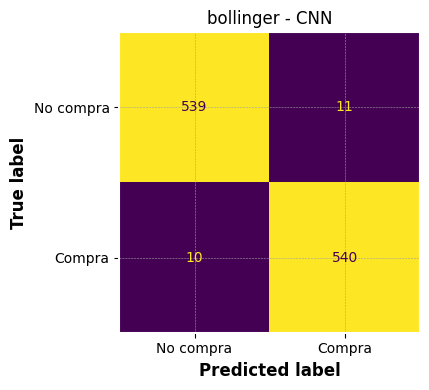

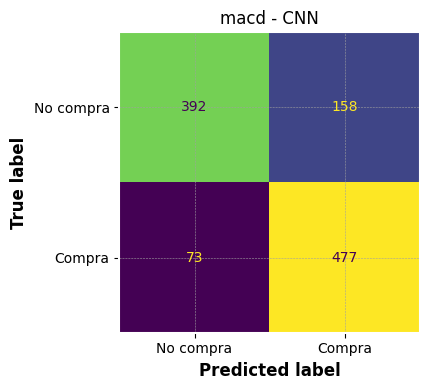

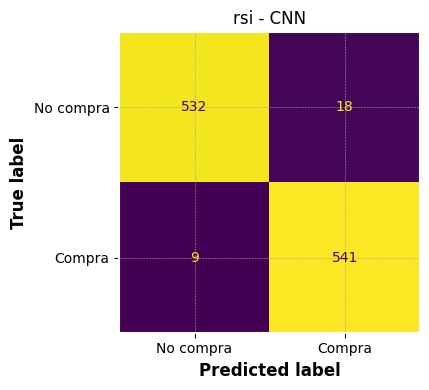

Matrices de confusión guardadas:
results/analisis_final/matrices_confusion\matriz_confusion_bollinger_CNN.png
results/analisis_final/matrices_confusion\matriz_confusion_macd_CNN.png
results/analisis_final/matrices_confusion\matriz_confusion_rsi_CNN.png


In [ ]:
# ============================================================
# 14 - Matrius de confusió
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

CONFUSION_DIR = "results/analisis_final/matrices_confusion"
os.makedirs(CONFUSION_DIR, exist_ok=True)

BEST_MODELS_PATH = "results/analisis_final/mejores_modelos_por_indicador.csv"

df_mejores = pd.read_csv(BEST_MODELS_PATH)


def plot_confusion_from_counts(row, output_dir):
    indicator = row["indicator"]
    model = row["model"]
    tipo_modelo = row["tipo_modelo"]

    tn = int(row["test_tn"])
    fp = int(row["test_fp"])
    fn = int(row["test_fn"])
    tp = int(row["test_tp"])

    cm = np.array([
        [tn, fp],
        [fn, tp]
    ])

    fig, ax = plt.subplots(figsize=(5, 4))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No compra", "Compra"]
    )

    disp.plot(ax=ax, values_format="d", colorbar=False)

    title = f"{indicator} - {model}"
    ax.set_title(title)

    plt.tight_layout()

    safe_model_name = str(model).replace(" ", "_").replace("/", "_")
    output_path = os.path.join(
        output_dir,
        f"matriu_confusio_{indicator}_{safe_model_name}.png"
    )

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return output_path


# ------------------------------------------------------------
# Matrius de confusió dels millors models per indicador
# ------------------------------------------------------------

rutas_matrices = []

for _, row in df_mejores.iterrows():
    ruta = plot_confusion_from_counts(row, CONFUSION_DIR)
    rutas_matrices.append(ruta)

print("Matrius de confusió guardades:")
for ruta in rutas_matrices:
    print(ruta)

### Matrius de confusió de la CNN i del Hard Voting

En aquest bloc es generen matrius de confusió específiques per als models de tipus `CNN` i per al sistema de `Hard Voting`.

A diferència del bloc anterior, on es representaven els millors models globals per indicador, aquí es mostren de manera explícita les matrius corresponents a aquests dos enfocaments, ja que són especialment rellevants en l'anàlisi final.

Per fer-ho, es parteix del fitxer:

- `results/analisis_final/ranking_final_modelos.csv`

A continuació, es filtren únicament les files corresponents a `CNN` i `Hard Voting`, i es construeixen les matrius de confusió a partir dels valors `TN`, `FP`, `FN` i `TP`.

Les figures es guarden a la mateixa carpeta utilitzada anteriorment:

- `results/analisis_final/matrices_confusion`

Això permet comparar visualment el comportament de la xarxa neuronal convolucional i del sistema de votació per majoria.

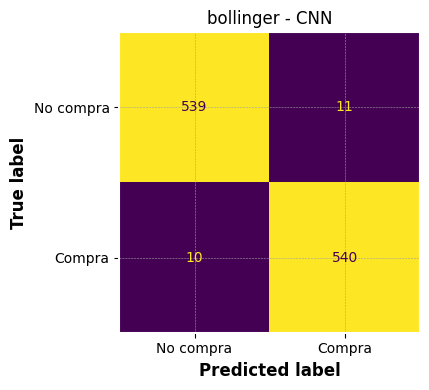

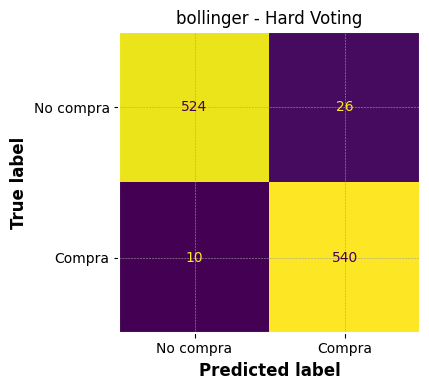

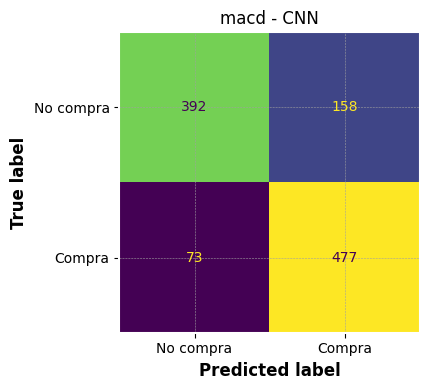

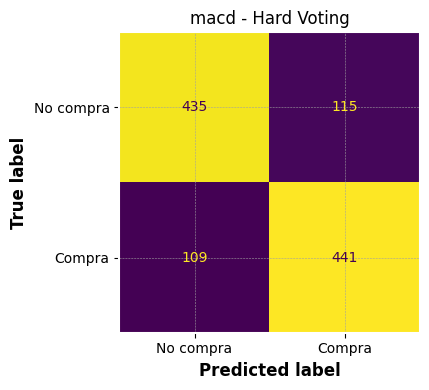

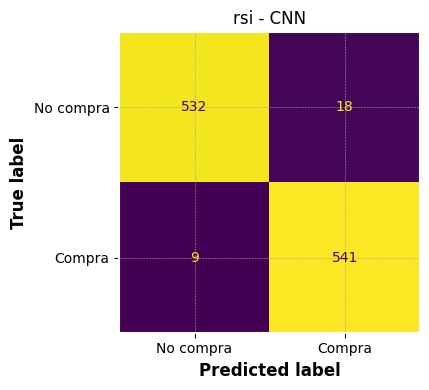

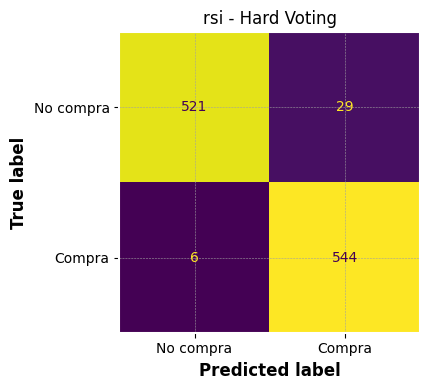

Matrices de CNN y Hard Voting guardadas:
results/analisis_final/matrices_confusion\matriz_confusion_bollinger_CNN.png
results/analisis_final/matrices_confusion\matriz_confusion_bollinger_Hard_Voting.png
results/analisis_final/matrices_confusion\matriz_confusion_macd_CNN.png
results/analisis_final/matrices_confusion\matriz_confusion_macd_Hard_Voting.png
results/analisis_final/matrices_confusion\matriz_confusion_rsi_CNN.png
results/analisis_final/matrices_confusion\matriz_confusion_rsi_Hard_Voting.png


In [ ]:
# ============================================================
# 15 - Matrius de confusió de la CNN i del Hard Voting
# ============================================================

FINAL_RANKING_PATH = "results/analisis_final/ranking_final_modelos.csv"
df_ranking_final = pd.read_csv(FINAL_RANKING_PATH)

# Selecció només dels models de tipus CNN i Hard Voting
df_cnn_hard = df_ranking_final[
    df_ranking_final["tipo_modelo"].isin(["CNN", "Hard Voting"])
].copy()

rutas_matrices_cnn_hard = []

for _, row in df_cnn_hard.iterrows():
    ruta = plot_confusion_from_counts(row, CONFUSION_DIR)
    rutas_matrices_cnn_hard.append(ruta)

print("Matrius de confusió de la CNN i del Hard Voting guardades:")
for ruta in rutas_matrices_cnn_hard:
    print(ruta)

## Anàlisi estadística de falsos positius

En aquest bloc es fa una anàlisi inicial dels errors comesos pels models, posant especial atenció en els falsos positius.

Un fals positiu es produeix quan el model prediu una senyal de compra (`y_pred = 1`), però l'etiqueta real indica que no hi havia senyal de compra (`y_true = 0`). En el context d'aquest projecte, aquest tipus d'error és important, ja que podria representar una situació en què el model detecta una possible oportunitat de compra quan realment no es compleix la condició tècnica definida.

També es calculen els falsos negatius, és a dir, els casos en què el model no detecta una senyal de compra tot i que realment sí que existia (`y_true = 1` i `y_pred = 0`).

L'anàlisi es fa a partir de les prediccions generades pels tres enfocaments principals:

* models clàssics,
* CNN,
* Hard Voting.

Els fitxers utilitzats són:

* `results/modelos_clasicos_tuning/predicciones_test_modelos_clasicos_tuning.csv`
* `results/cnn/predicciones_test_cnn.csv`
* `results/hard_voting/predicciones_hard_voting.csv`

Per a cada conjunt de prediccions es calcula el nombre total de prediccions, el nombre de falsos positius i el nombre de falsos negatius. També es mostra la distribució dels falsos positius per indicador, per model i per ticker quan aquestes columnes estan disponibles.

Cal tenir en compte que, en el cas dels models clàssics, el recompte es fa sobre totes les prediccions de tots els models. En canvi, en la CNN i en el Hard Voting el recompte correspon a les prediccions finals disponibles en cada fitxer. Per tant, aquesta anàlisi serveix principalment per detectar patrons d'error, no per substituir la comparació final de mètriques feta en els blocs anteriors.


In [ ]:
# ==========================================================
# 15.1 - Anàlisi estadística de falsos positius
# ==========================================================

import os
import pandas as pd

RUTAS = {
    "Models clàssics": "results/modelos_clasicos_tuning/predicciones_test_modelos_clasicos_tuning.csv",
    "CNN": "results/cnn/predicciones_test_cnn.csv",
    "Hard Voting": "results/hard_voting/predicciones_hard_voting.csv"
}

OUTPUT_DIR = "results/analisis_final/falsos_positivos"
os.makedirs(OUTPUT_DIR, exist_ok=True)

resumen_errores = []

for nombre, ruta in RUTAS.items():

    print("\n" + "=" * 80)
    print(nombre.upper())
    print("=" * 80)

    df = pd.read_csv(ruta)

    df["y_true"] = df["y_true"].astype(int)
    df["y_pred"] = df["y_pred"].astype(int)

    total = len(df)

    fp = df[(df["y_true"] == 0) & (df["y_pred"] == 1)].copy()
    fn = df[(df["y_true"] == 1) & (df["y_pred"] == 0)].copy()

    pct_fp = (len(fp) / total * 100) if total > 0 else 0
    pct_fn = (len(fn) / total * 100) if total > 0 else 0

    print(f"Total de prediccions: {total}")
    print(f"Falsos positius: {len(fp)} ({pct_fp:.2f}%)")
    print(f"Falsos negatius: {len(fn)} ({pct_fn:.2f}%)")

    resumen_errores.append({
        "font": nombre,
        "total_prediccions": total,
        "falsos_positius": len(fp),
        "percentatge_falsos_positius": round(pct_fp, 2),
        "falsos_negatius": len(fn),
        "percentatge_falsos_negatius": round(pct_fn, 2)
    })

    safe_name = (
        nombre.lower()
        .replace(" ", "_")
        .replace("à", "a")
        .replace("í", "i")
        .replace("ó", "o")
    )

    fp.to_csv(
        os.path.join(OUTPUT_DIR, f"falsos_positius_{safe_name}.csv"),
        index=False
    )

    fn.to_csv(
        os.path.join(OUTPUT_DIR, f"falsos_negatius_{safe_name}.csv"),
        index=False
    )

    if "indicator" in df.columns:
        print("\nFalsos positius per indicador:")
        fp_per_indicator = fp["indicator"].value_counts().reset_index()
        fp_per_indicator.columns = ["indicator", "num_falsos_positius"]
        display(fp_per_indicator)

        fp_per_indicator.to_csv(
            os.path.join(OUTPUT_DIR, f"falsos_positius_per_indicador_{safe_name}.csv"),
            index=False
        )

    if "model" in df.columns:
        print("\nFalsos positius per model:")
        fp_per_model = fp["model"].value_counts().reset_index()
        fp_per_model.columns = ["model", "num_falsos_positius"]
        display(fp_per_model)

        fp_per_model.to_csv(
            os.path.join(OUTPUT_DIR, f"falsos_positius_per_model_{safe_name}.csv"),
            index=False
        )

    if "Ticker" in df.columns:
        print("\nTop 15 tickers amb més falsos positius:")
        fp_per_ticker = fp["Ticker"].value_counts().head(15).reset_index()
        fp_per_ticker.columns = ["Ticker", "num_falsos_positius"]
        display(fp_per_ticker)

        fp_per_ticker.to_csv(
            os.path.join(OUTPUT_DIR, f"top15_tickers_falsos_positius_{safe_name}.csv"),
            index=False
        )

df_resumen_errores = pd.DataFrame(resumen_errores)

RESUMEN_PATH = os.path.join(OUTPUT_DIR, "resum_falsos_positius_i_negatius.csv")
df_resumen_errores.to_csv(RESUMEN_PATH, index=False)

print("\n" + "=" * 80)
print("RESUM GLOBAL D'ERRORS")
print("=" * 80)

display(df_resumen_errores)

print("\nFitxers guardats a:")
print(OUTPUT_DIR)


MODELOS CLÁSICOS
Total predicciones: 52800
Falsos positivos: 3468 (6.57%)
Falsos negativos: 4044 (7.66%)

Falsos positivos por indicador:


indicator
macd         2171
bollinger     651
rsi           646
Name: count, dtype: int64


Falsos positivos por modelo:


model
K Nearest Neighbors                525
Gaussian Naive Bayes               335
Quadratic Discriminant Analysis    244
Decision Tree                      243
Linear SVM                         238
Logistic Regression                216
Linear Discriminant Analysis       205
Bagging                            200
Random Forest                      190
Ada Boost                          190
Gradient Boosting                  190
Extra Randomized Forest            187
Deep Neural Net                    171
RBF SVM                            164
RBF SVM Probability                164
Gaussian Process                     6
Name: count, dtype: int64


Top 15 tickers con más falsos positivos:


...

model
CNN    187
Name: count, dtype: int64


Top 15 tickers con más falsos positivos:


Ticker
CTSH    4
WELL    3
BRO     3
FCX     3
IBM     3
TRGP    3
ALLE    2
CPB     2
O       2
SRE     2
ANET    2
APH     2
AVB     2
AZO     2
C       2
Name: count, dtype: int64


HARD VOTING
Total predicciones: 3300
Falsos positivos: 170 (5.15%)
Falsos negativos: 125 (3.79%)

Falsos positivos por indicador:


indicator
macd         115
rsi           29
bollinger     26
Name: count, dtype: int64

## Preparació de l'anàlisi visual de falsos positius

En aquest bloc es prepara una anàlisi visual dels falsos positius detectats pels diferents models.

Un fals positiu és un cas en què el model prediu una senyal de compra (`y_pred = 1`), però l'etiqueta real indica que no hi havia senyal de compra (`y_true = 0`). Aquest tipus d'error és especialment interessant en aquest projecte, ja que pot indicar situacions on el model interpreta com a patró de compra una imatge que realment no compleix la regla tècnica definida.

L'objectiu d'aquest bloc no és entrenar cap model nou, sinó preparar material per poder revisar visualment aquests errors. Per això es parteix de les prediccions generades anteriorment pels tres enfocaments principals:

* models clàssics,
* CNN,
* Hard Voting.

Els fitxers utilitzats són:

* `results/modelos_clasicos_tuning/predicciones_test_modelos_clasicos_tuning.csv`
* `results/cnn/predicciones_test_cnn.csv`
* `results/hard_voting/predicciones_hard_voting.csv`

Per a cada conjunt de prediccions es filtren els falsos positius i es guarden en fitxers CSV. També es creen resums per indicador, per model i per ticker quan aquestes columnes estan disponibles.

A més, es copien mostres d'imatges associades als falsos positius dins de carpetes específiques. Això permet revisar manualment els casos en què el model s'ha equivocat i observar si existeixen patrons visuals comuns entre aquests errors.

Els resultats es guarden a:

* `results/analisis_errores`

Aquest bloc aporta una visió més qualitativa dels errors, complementant les mètriques numèriques calculades en les seccions anteriors.


In [ ]:
# ==========================================================
# 15.2 - Preparació de l'anàlisi visual de falsos positius
# ==========================================================

import os
import shutil
import pandas as pd

# ----------------------------------------------------------
# 1. Rutes de prediccions
# ----------------------------------------------------------

RUTAS = {
    "Models_classics": "results/modelos_clasicos_tuning/predicciones_test_modelos_clasicos_tuning.csv",
    "CNN": "results/cnn/predicciones_test_cnn.csv",
    "Hard_Voting": "results/hard_voting/predicciones_hard_voting.csv"
}

OUTPUT_BASE = "results/analisis_errores"
os.makedirs(OUTPUT_BASE, exist_ok=True)

# Nombre màxim d'imatges copiades per grup per evitar crear massa fitxers
MAX_IMATGES_PER_GRUP = 25


# ----------------------------------------------------------
# 2. Funció per netejar noms de carpetes i fitxers
# ----------------------------------------------------------

def limpiar_nombre(texto):
    texto = str(texto)
    texto = texto.replace("/", "_")
    texto = texto.replace("\\", "_")
    texto = texto.replace(" ", "_")
    texto = texto.replace(":", "-")
    texto = texto.replace("|", "_")
    return texto


# ----------------------------------------------------------
# 3. Funció per copiar imatges de falsos positius
# ----------------------------------------------------------

def copiar_imatges_falsos_positius(fp, output_dir, nombre_bloque):
    if "image_path" not in fp.columns:
        print("No hi ha columna image_path. No es poden copiar imatges.")
        return pd.DataFrame()

    image_output_dir = os.path.join(output_dir, "imatges_falsos_positius")
    os.makedirs(image_output_dir, exist_ok=True)

    group_cols = []

    if "indicator" in fp.columns:
        group_cols.append("indicator")

    if "model" in fp.columns:
        group_cols.append("model")

    if len(group_cols) == 0:
        group_cols = ["__all__"]
        fp["__all__"] = "tots"

    registres_copiats = []

    for claus, group in fp.groupby(group_cols, dropna=False):
        if not isinstance(claus, tuple):
            claus = (claus,)

        carpeta_grup_parts = [limpiar_nombre(nombre_bloque)]

        for valor in claus:
            carpeta_grup_parts.append(limpiar_nombre(valor))

        carpeta_grup = os.path.join(image_output_dir, *carpeta_grup_parts)
        os.makedirs(carpeta_grup, exist_ok=True)

        group_sample = group.head(MAX_IMATGES_PER_GRUP).copy()

        for i, (_, row) in enumerate(group_sample.iterrows(), start=1):
            src_path = row["image_path"]

            if not isinstance(src_path, str) or not os.path.exists(src_path):
                continue

            ticker = row["Ticker"] if "Ticker" in row.index else "sense_ticker"
            indicator = row["indicator"] if "indicator" in row.index else "sense_indicador"
            model = row["model"] if "model" in row.index else nombre_bloque

            original_name = os.path.basename(src_path)

            dst_name = limpiar_nombre(
                f"{i:03d}_{ticker}_{indicator}_{model}_{original_name}"
            )

            dst_path = os.path.join(carpeta_grup, dst_name)

            shutil.copy2(src_path, dst_path)

            registres_copiats.append({
                "bloc": nombre_bloque,
                "indicator": indicator,
                "model": model,
                "Ticker": ticker,
                "image_path_original": src_path,
                "image_path_copiada": dst_path
            })

    return pd.DataFrame(registres_copiats)


# ----------------------------------------------------------
# 4. Funció principal d'anàlisi
# ----------------------------------------------------------

def analizar_falsos_positivos(nombre_bloque, ruta_csv):

    print("\n" + "=" * 90)
    print(f"ANÀLISI DE FALSOS POSITIUS - {nombre_bloque}")
    print("=" * 90)

    if not os.path.exists(ruta_csv):
        print(f"No s'ha trobat el fitxer: {ruta_csv}")
        return None

    df = pd.read_csv(ruta_csv)

    df["y_true"] = df["y_true"].astype(int)
    df["y_pred"] = df["y_pred"].astype(int)

    total = len(df)

    fp = df[
        (df["y_true"] == 0) &
        (df["y_pred"] == 1)
    ].copy()

    fn = df[
        (df["y_true"] == 1) &
        (df["y_pred"] == 0)
    ].copy()

    pct_fp = (len(fp) / total * 100) if total > 0 else 0
    pct_fn = (len(fn) / total * 100) if total > 0 else 0

    print(f"Total de prediccions: {total}")
    print(f"Falsos positius: {len(fp)} ({pct_fp:.2f}%)")
    print(f"Falsos negatius: {len(fn)} ({pct_fn:.2f}%)")

    # Carpeta específica per a aquest bloc
    output_dir = os.path.join(OUTPUT_BASE, limpiar_nombre(nombre_bloque))
    os.makedirs(output_dir, exist_ok=True)

    # Guardar tots els falsos positius
    fp_path = os.path.join(output_dir, f"falsos_positius_{limpiar_nombre(nombre_bloque)}.csv")
    fp.to_csv(fp_path, index=False)

    # Guardar també els falsos negatius
    fn_path = os.path.join(output_dir, f"falsos_negatius_{limpiar_nombre(nombre_bloque)}.csv")
    fn.to_csv(fn_path, index=False)

    # Resum per indicador
    if "indicator" in fp.columns:
        resumen_indicador = fp["indicator"].value_counts().reset_index()
        resumen_indicador.columns = ["indicator", "num_falsos_positius"]

        resumen_indicador_path = os.path.join(
            output_dir,
            f"resum_fp_indicador_{limpiar_nombre(nombre_bloque)}.csv"
        )

        resumen_indicador.to_csv(resumen_indicador_path, index=False)

        print("\nFalsos positius per indicador:")
        display(resumen_indicador)

    # Resum per model
    if "model" in fp.columns:
        resumen_modelo = fp["model"].value_counts().reset_index()
        resumen_modelo.columns = ["model", "num_falsos_positius"]

        resumen_modelo_path = os.path.join(
            output_dir,
            f"resum_fp_model_{limpiar_nombre(nombre_bloque)}.csv"
        )

        resumen_modelo.to_csv(resumen_modelo_path, index=False)

        print("\nFalsos positius per model:")
        display(resumen_modelo)

    # Resum per ticker
    if "Ticker" in fp.columns:
        resumen_ticker = fp["Ticker"].value_counts().reset_index()
        resumen_ticker.columns = ["Ticker", "num_falsos_positius"]

        resumen_ticker_path = os.path.join(
            output_dir,
            f"resum_fp_ticker_{limpiar_nombre(nombre_bloque)}.csv"
        )

        resumen_ticker.to_csv(resumen_ticker_path, index=False)

        print("\nTop 15 tickers amb més falsos positius:")
        display(resumen_ticker.head(15))

    # Còpia d'imatges per a l'anàlisi visual
    df_imatges_copiades = copiar_imatges_falsos_positius(
        fp=fp,
        output_dir=output_dir,
        nombre_bloque=nombre_bloque
    )

    copied_path = os.path.join(
        output_dir,
        f"imatges_falsos_positius_copiades_{limpiar_nombre(nombre_bloque)}.csv"
    )

    df_imatges_copiades.to_csv(copied_path, index=False)

    print("\nImatges de falsos positius copiades:", len(df_imatges_copiades))
    print("Carpeta de sortida:", output_dir)

    return fp


# ----------------------------------------------------------
# 5. Execució de l'anàlisi per als tres fitxers
# ----------------------------------------------------------

fps = {}

for nombre_bloque, ruta_csv in RUTAS.items():
    fp = analizar_falsos_positivos(nombre_bloque, ruta_csv)

    if fp is not None:
        fps[nombre_bloque] = fp

print("\nAnàlisi visual de falsos positius preparada.")


ANÁLISIS DE FALSOS POSITIVOS - Modelos_clasicos
Total de predicciones: 52800
Falsos positivos: 3468 (6.57%)
Falsos negativos: 4044 (7.66%)

Falsos positivos por indicador:


,indicator,num_falsos_positivos
0,macd,2171
1,bollinger,651
2,rsi,646



Falsos positivos por modelo:


,model,num_falsos_positivos
0,K Nearest Neighbors,525
1,Gaussian Naive Bayes,335
2,Quadratic Discriminant Analysis,244
3,Decision Tree,243
4,Linear SVM,238
5,Logistic Regression,216
6,Linear Discriminant Analysis,205
7,Bagging,200
8,Random Forest,190
9,Ada Boost,190



Top 15 tickers con más falsos positivos:


...


Top 15 tickers con más falsos positivos:


,Ticker,num_falsos_positivos
0,CTSH,4
1,WELL,3
2,BRO,3
3,FCX,3
4,IBM,3
5,TRGP,3
6,ALLE,2
7,CPB,2
8,O,2
9,SRE,2



ANÁLISIS DE FALSOS POSITIVOS - Hard_Voting
Total de predicciones: 3300
Falsos positivos: 170 (5.15%)
Falsos negativos: 125 (3.79%)

Falsos positivos por indicador:


,indicator,num_falsos_positivos
0,macd,115
1,rsi,29
2,bollinger,26



Análisis estadístico terminado.


## Còpia de mostres visuals de falsos positius

En aquest bloc es selecciona una mostra reduïda d'imatges corresponents a falsos positius per poder revisar-les visualment.

L'objectiu no és analitzar tots els errors generats pels models, sinó preparar un conjunt més petit d'exemples que es pugui inspeccionar manualment. Això permet observar si els falsos positius comparteixen algun patró visual comú, per exemple formes similars en les veles japoneses o estructures que el model interpreta erròniament com a senyals de compra.

El bloc parteix dels falsos positius obtinguts en l'anàlisi anterior i copia les imatges corresponents a carpetes separades segons el tipus de model i l'indicador tècnic.

Per a la selecció de mostres es defineixen dos valors:

* `N_MACD`: nombre d'imatges seleccionades per a MACD.
* `N_OTROS`: nombre d'imatges seleccionades per a la resta d'indicadors.

En aquest cas es dona més pes a MACD, ja que és un indicador especialment rellevant dins de l'anàlisi d'errors i pot concentrar un nombre elevat de falsos positius.

Les imatges copiades es guarden dins de:

* `results/analisis_errores`

També es genera un fitxer CSV amb totes les mostres seleccionades:

* `results/analisis_errores/muestras_visuales_falsos_positivos.csv`

Aquest fitxer permet saber quines imatges s'han seleccionat, de quin model provenen i a quin indicador corresponen.


In [ ]:
# ==========================================================
# 15.3 - Còpia de mostres visuals de falsos positius
# ==========================================================

import os
import shutil
import pandas as pd

OUTPUT_BASE = "results/analisis_errores"

# Nombre d'imatges seleccionades per revisar visualment
N_MACD = 25
N_OTROS = 8

muestras_totales = []


for nombre_bloque, fp in fps.items():

    print("\n" + "=" * 90)
    print(f"GENERANT MOSTRES VISUALS - {nombre_bloque}")
    print("=" * 90)

    output_img_base = os.path.join(
        OUTPUT_BASE,
        limpiar_nombre(nombre_bloque),
        "mostres_visuals_falsos_positius"
    )

    os.makedirs(output_img_base, exist_ok=True)

    if "image_path" not in fp.columns:
        print(f"{nombre_bloque}: no hi ha columna 'image_path'. No es poden copiar imatges.")
        continue

    # Si no existeix la columna indicator, es fa una mostra general
    if "indicator" not in fp.columns:
        print(f"{nombre_bloque}: no té columna 'indicator'. Es farà una mostra general.")

        muestra = fp.sample(
            min(len(fp), 30),
            random_state=42
        ).copy()

        muestra["bloque_origen"] = nombre_bloque
        muestra["tipo_muestra"] = "general"

        indicadores_a_usar = [("general", muestra)]

    else:
        indicadores_a_usar = []

        for indicador in fp["indicator"].dropna().unique():
            fp_ind = fp[fp["indicator"] == indicador].copy()

            if indicador.lower() == "macd":
                n = N_MACD
            else:
                n = N_OTROS

            muestra_ind = fp_ind.sample(
                min(len(fp_ind), n),
                random_state=42
            ).copy()

            muestra_ind["bloque_origen"] = nombre_bloque
            muestra_ind["tipo_muestra"] = indicador

            indicadores_a_usar.append((indicador, muestra_ind))

    # Còpia de les imatges seleccionades
    for indicador, muestra in indicadores_a_usar:

        indicador_limpio = limpiar_nombre(indicador)
        output_dir = os.path.join(output_img_base, indicador_limpio)
        os.makedirs(output_dir, exist_ok=True)

        rutas_copiadas = []

        for j, (i, row) in enumerate(muestra.iterrows(), start=1):

            src = row["image_path"]

            ticker = limpiar_nombre(row["Ticker"]) if "Ticker" in row.index else "ticker_desconegut"

            if "end_date" in row.index:
                try:
                    fecha = pd.to_datetime(row["end_date"]).strftime("%Y%m%d")
                except Exception:
                    fecha = limpiar_nombre(row["end_date"])
            else:
                fecha = f"idx_{i}"

            modelo = limpiar_nombre(row["model"]) if "model" in row.index else limpiar_nombre(nombre_bloque)

            filename = (
                f"FP_{j:03d}_"
                f"{limpiar_nombre(nombre_bloque)}_"
                f"{indicador_limpio}_"
                f"{modelo}_"
                f"{ticker}_"
                f"{fecha}.png"
            )

            dst = os.path.join(output_dir, filename)

            if os.path.exists(src):
                shutil.copy2(src, dst)
                rutas_copiadas.append(dst)
            else:
                print("Imatge no trobada:", src)
                rutas_copiadas.append(None)

        muestra = muestra.copy()
        muestra["image_path_copiada"] = rutas_copiadas

        muestras_totales.append(muestra)

        print(f"{nombre_bloque} - {indicador}: {len(muestra)} imatges seleccionades.")


# ----------------------------------------------------------
# Guardar CSV global amb totes les mostres seleccionades
# ----------------------------------------------------------

if len(muestras_totales) > 0:
    df_muestras = pd.concat(muestras_totales, ignore_index=True)

    muestras_path = os.path.join(
        OUTPUT_BASE,
        "muestras_visuales_falsos_positivos.csv"
    )

    df_muestras.to_csv(muestras_path, index=False)

    print("\nCSV amb totes les mostres guardat a:")
    print(muestras_path)

print("\nImatges copiades a:")
print(os.path.join(OUTPUT_BASE, "[bloc]", "mostres_visuals_falsos_positius"))


GENERANDO MUESTRAS VISUALES - Modelos_clasicos
Modelos_clasicos - bollinger: 8 imágenes seleccionadas.
Modelos_clasicos - macd: 25 imágenes seleccionadas.
Modelos_clasicos - rsi: 8 imágenes seleccionadas.

GENERANDO MUESTRAS VISUALES - CNN
CNN - bollinger: 8 imágenes seleccionadas.
CNN - macd: 25 imágenes seleccionadas.
CNN - rsi: 8 imágenes seleccionadas.

GENERANDO MUESTRAS VISUALES - Hard_Voting
Hard_Voting - bollinger: 8 imágenes seleccionadas.
Hard_Voting - macd: 25 imágenes seleccionadas.
Hard_Voting - rsi: 8 imágenes seleccionadas.

CSV con todas las muestras guardado en:
results/analisis_errores\muestras_visuales_falsos_positivos.csv

Imágenes copiadas en:
results/analisis_errores\[bloque]\imagenes_falsos_positivos


## Plantilla per a l'anàlisi manual dels falsos positius

En aquest bloc es crea una plantilla per revisar manualment les imatges seleccionades de falsos positius.

L'objectiu és facilitar una anàlisi visual més detallada dels errors del model. En concret, es vol observar si les imatges classificades incorrectament com a senyals de compra comparteixen alguns patrons comuns.

El bloc parteix del fitxer generat anteriorment:

* `results/analisis_errores/muestras_visuales_falsos_positivos.csv`

Aquest fitxer conté les mostres de falsos positius seleccionades per a la revisió visual. A partir d'aquestes mostres es crea una nova plantilla amb columnes buides que es poden omplir manualment després de mirar cada imatge.

Les columnes afegides permeten anotar si en la imatge s'observa algun dels elements següents:

* caiguda prèvia,
* rebot recent,
* alta volatilitat,
* mercat lateral,
* semblança visual amb una senyal de compra,
* comentari visual addicional.

La plantilla final es guarda a:

* `results/analisis_errores/plantilla_analisis_manual_falsos_positivos.csv`

Aquest fitxer permet documentar de manera ordenada l'anàlisi visual dels falsos positius i pot ajudar a interpretar millor per què alguns models generen errors d'aquest tipus.


In [ ]:
# ==========================================================
# 15.4 - Plantilla per a l'anàlisi manual de les imatges
# ==========================================================

import os
import pandas as pd

OUTPUT_BASE = "results/analisis_errores"

muestras_path = os.path.join(
    OUTPUT_BASE,
    "muestras_visuales_falsos_positivos.csv"
)

df_muestras = pd.read_csv(muestras_path)

# Creació d'una plantilla buida per completar manualment després de revisar les imatges
plantilla = df_muestras.copy()

plantilla["caiguda_previa"] = ""
plantilla["rebot_recent"] = ""
plantilla["alta_volatilitat"] = ""
plantilla["mercat_lateral"] = ""
plantilla["semblant_senyal_compra"] = ""
plantilla["comentari_visual"] = ""

columnas_base = []

for col in [
    "bloque_origen",
    "tipo_muestra",
    "Ticker",
    "indicator",
    "start_date",
    "end_date",
    "model",
    "y_true",
    "y_pred",
    "image_path",
    "image_path_copiada"
]:
    if col in plantilla.columns:
        columnas_base.append(col)

columnas_analisis = [
    "caiguda_previa",
    "rebot_recent",
    "alta_volatilitat",
    "mercat_lateral",
    "semblant_senyal_compra",
    "comentari_visual"
]

plantilla = plantilla[columnas_base + columnas_analisis]

plantilla_path = os.path.join(
    OUTPUT_BASE,
    "plantilla_analisis_manual_falsos_positivos.csv"
)

plantilla.to_csv(plantilla_path, index=False)

print("Plantilla creada correctament:")
print(plantilla_path)

display(plantilla.head(10))

Plantilla creada correctamente:
results/analisis_errores\plantilla_analisis_manual_falsos_positivos.csv


,bloque_origen,tipo_muestra,Ticker,indicator,start_date,end_date,model,y_true,y_pred,image_path,caida_previa,rebote_reciente,alta_volatilidad,mercado_lateral,parecido_a_senal_compra,comentario_visual
0,Modelos_clasicos,bollinger,DELL,bollinger,2024-11-12,2024-12-10,RBF SVM Probability,0,1,dataset_candlestick\test\DELL_bollinger_202412...,,,,,,
1,Modelos_clasicos,bollinger,GEN,bollinger,2025-01-15,2025-02-12,K Nearest Neighbors,0,1,dataset_candlestick\test\GEN_bollinger_2025021...,,,,,,
2,Modelos_clasicos,bollinger,FRT,bollinger,2025-02-07,2025-03-07,K Nearest Neighbors,0,1,dataset_candlestick\test\FRT_bollinger_2025030...,,,,,,
3,Modelos_clasicos,bollinger,IEX,bollinger,2025-01-13,2025-02-10,Random Forest,0,1,dataset_candlestick\test\IEX_bollinger_2025021...,,,,,,
4,Modelos_clasicos,bollinger,META,bollinger,2024-08-13,2024-09-10,Gaussian Naive Bayes,0,1,dataset_candlestick\test\META_bollinger_202409...,,,,,,
5,Modelos_clasicos,bollinger,BG,bollinger,2025-01-13,2025-02-10,Decision Tree,0,1,dataset_candlestick\test\BG_bollinger_20250210...,,,,,,
6,Modelos_clasicos,bollinger,EIX,bollinger,2025-10-16,2025-11-12,K Nearest Neighbors,0,1,dataset_candlestick\test\EIX_bollinger_2025111...,,,,,,
7,Modelos_clasicos,bollinger,AEP,bollinger,2024-06-11,2024-07-10,Quadratic Discriminant Analysis,0,1,dataset_candlestick\test\AEP_bollinger_2024071...,,,,,,
8,Modelos_clasicos,macd,UNH,macd,2025-02-03,2025-03-11,Extra Randomized Forest,0,1,dataset_candlestick\test\UNH_macd_20250311_lab...,,,,,,
9,Modelos_clasicos,macd,VLTO,macd,2025-03-07,2025-04-11,Gaussian Naive Bayes,0,1,dataset_candlestick\test\VLTO_macd_20250411_la...,,,,,,


## Generació d'imatges per a l'Apèndix A

En aquest bloc es generen imatges representatives per incloure-les a l'Apèndix A del treball.

L'objectiu és mostrar exemples visuals de finestres classificades per la CNN com a:

- **vertaders positius** (`TP`): casos en què la imatge correspon realment a una senyal de compra i el model també la prediu com a tal.
- **falsos positius** (`FP`): casos en què el model prediu una senyal de compra, però l'etiqueta real indica que no n'hi havia.

Les mostres es seleccionen de manera separada per a cada indicador tècnic:

- RSI,
- MACD,
- Bandes de Bollinger.

Per fer-ho, es parteix de les prediccions de la CNN guardades a:

- `results/cnn/predicciones_test_cnn.csv`

i del dataset etiquetat original:

- `data/processed/04_etiquetado/dataset_etiquetado.csv`

A partir d'aquesta informació, el codi reconstrueix la finestra temporal corresponent a cada mostra seleccionada i genera una nova imatge de veles japoneses a una resolució més alta. Aquestes imatges representen la mateixa finestra utilitzada pel model, però en un format molt més llegible per al document.

En total es generen sis imatges:

- un vertader positiu i un fals positiu per a RSI,
- un vertader positiu i un fals positiu per a MACD,
- un vertader positiu i un fals positiu per a Bandes de Bollinger.

Les imatges es guarden a:

- `figures/appendix`

A més, també es genera un fitxer resum amb la informació de les mostres seleccionades:

- `figures/appendix/resumen_muestras_apendix_A.csv`

Aquest fitxer permet saber quin ticker s'ha seleccionat, el rang temporal de la finestra, l'etiqueta real, la predicció del model, la probabilitat estimada per la CNN i la ruta de la imatge generada.

In [ ]:
# ==========================================================
# 15.5 - Generació d'imatges per a l'Apèndix A
# Vertaders positius i falsos positius per indicador
# ==========================================================

import os
import pandas as pd
import mplfinance as mpf
from PIL import Image

# ----------------------------------------------------------
# 1. Rutes
# ----------------------------------------------------------

PREDICCIONS_CNN_PATH = "results/cnn/predicciones_test_cnn.csv"
DATA_PATH = "data/processed/04_etiquetado/dataset_etiquetado.csv"

APPENDIX_DIR = "figures/appendix"
os.makedirs(APPENDIX_DIR, exist_ok=True)

RESUMEN_APPENDIX_PATH = os.path.join(
    APPENDIX_DIR,
    "resumen_muestras_apendix_A.csv"
)

# ----------------------------------------------------------
# 2. Càrrega de dades
# ----------------------------------------------------------

if not os.path.exists(PREDICCIONS_CNN_PATH):
    raise FileNotFoundError(
        f"No existeix el fitxer de prediccions de la CNN: {PREDICCIONS_CNN_PATH}. "
        "Executa abans el bloc d'entrenament i avaluació de la CNN."
    )

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"No existeix el dataset etiquetat: {DATA_PATH}."
    )

df_pred = pd.read_csv(PREDICCIONS_CNN_PATH)
df_data = pd.read_csv(DATA_PATH)

# Dates
df_pred["start_date"] = pd.to_datetime(df_pred["start_date"], errors="coerce")
df_pred["end_date"] = pd.to_datetime(df_pred["end_date"], errors="coerce")
df_data["Date"] = pd.to_datetime(df_data["Date"], errors="coerce")

# Tipus bàsics
df_pred["indicator"] = df_pred["indicator"].astype(str).str.lower()
df_pred["Ticker"] = df_pred["Ticker"].astype(str)
df_pred["y_true"] = pd.to_numeric(df_pred["y_true"], errors="coerce").astype(int)
df_pred["y_pred"] = pd.to_numeric(df_pred["y_pred"], errors="coerce").astype(int)

if "y_prob" in df_pred.columns:
    df_pred["y_prob"] = pd.to_numeric(df_pred["y_prob"], errors="coerce")
else:
    df_pred["y_prob"] = None

df_data["Ticker"] = df_data["Ticker"].astype(str)

df_data = (
    df_data
    .sort_values(["Ticker", "Date"])
    .reset_index(drop=True)
)

print("Prediccions carregades:", len(df_pred))
print("Indicadors disponibles:", sorted(df_pred["indicator"].dropna().unique()))

# ----------------------------------------------------------
# 3. Funcions auxiliars
# ----------------------------------------------------------

def elegir_muestra(df, indicator, tipo):
    """
    Selecciona una mostra concreta per a l'apèndix.

    tipo = "TP" -> vertader positiu:
        y_true = 1 i y_pred = 1

    tipo = "FP" -> fals positiu:
        y_true = 0 i y_pred = 1
    """

    df_ind = df[df["indicator"] == indicator].copy()

    if tipo == "TP":
        candidatos = df_ind[
            (df_ind["y_true"] == 1) &
            (df_ind["y_pred"] == 1)
        ].copy()

    elif tipo == "FP":
        candidatos = df_ind[
            (df_ind["y_true"] == 0) &
            (df_ind["y_pred"] == 1)
        ].copy()

    else:
        raise ValueError("tipo ha de ser 'TP' o 'FP'.")

    if len(candidatos) == 0:
        raise ValueError(
            f"No s'ha trobat cap mostra {tipo} per a l'indicador {indicator}."
        )

    # Si hi ha probabilitat, es tria l'exemple on la CNN està més segura
    if "y_prob" in candidatos.columns and candidatos["y_prob"].notna().any():
        candidatos = candidatos.sort_values(
            by="y_prob",
            ascending=False
        )

    # Si no hi ha probabilitat, es tria el primer ordenat per data
    else:
        candidatos = candidatos.sort_values(
            by=["Ticker", "end_date"]
        )

    return candidatos.iloc[0].copy()


def reconstruir_ventana(row, df_data):
    """
    Reconstrueix la finestra temporal original a partir del ticker,
    la data inicial i la data final.
    """

    ticker = row["Ticker"]
    start_date = row["start_date"]
    end_date = row["end_date"]

    window = df_data[
        (df_data["Ticker"] == ticker) &
        (df_data["Date"] >= start_date) &
        (df_data["Date"] <= end_date)
    ].copy()

    window = window.sort_values("Date").reset_index(drop=True)

    if len(window) == 0:
        raise ValueError(
            f"No s'ha pogut reconstruir la finestra per a {ticker} "
            f"entre {start_date} i {end_date}."
        )

    return window


def guardar_candlestick_apendice(window_df, output_path):
    """
    Guarda una imatge de veles japoneses llegible per a l'apèndix.

    Aquestes imatges es generen a més resolució per facilitar-ne
    la visualització al document. Representen la mateixa finestra
    temporal que la imatge 30x30 utilitzada pel model.
    """

    temp_path = output_path.replace(".png", "_temp.png")

    plot_df = window_df[["Date", "Open", "High", "Low", "Close"]].copy()
    plot_df = plot_df.set_index("Date")

    mpf.plot(
        plot_df,
        type="candle",
        style="charles",
        axisoff=True,
        volume=False,
        savefig=dict(
            fname=temp_path,
            dpi=250,
            bbox_inches="tight",
            pad_inches=0
        )
    )

    # Conversió a RGB per evitar problemes en visualització o compilació
    with Image.open(temp_path) as img:
        img = img.convert("RGB")
        img.save(output_path)

    if os.path.exists(temp_path):
        os.remove(temp_path)


# ----------------------------------------------------------
# 4. Selecció i generació de les 6 imatges
# ----------------------------------------------------------

config_muestras = [
    {
        "indicator": "rsi",
        "tipo": "TP",
        "output_name": "rsi_tp.png",
        "descripcion": "Vertader positiu RSI"
    },
    {
        "indicator": "rsi",
        "tipo": "FP",
        "output_name": "rsi_fp.png",
        "descripcion": "Fals positiu RSI"
    },
    {
        "indicator": "macd",
        "tipo": "TP",
        "output_name": "macd_tp.png",
        "descripcion": "Vertader positiu MACD"
    },
    {
        "indicator": "macd",
        "tipo": "FP",
        "output_name": "macd_fp.png",
        "descripcion": "Fals positiu MACD"
    },
    {
        "indicator": "bollinger",
        "tipo": "TP",
        "output_name": "bollinger_tp.png",
        "descripcion": "Vertader positiu Bandes de Bollinger"
    },
    {
        "indicator": "bollinger",
        "tipo": "FP",
        "output_name": "bollinger_fp.png",
        "descripcion": "Fals positiu Bandes de Bollinger"
    }
]

resumen_muestras = []

for config in config_muestras:

    indicator = config["indicator"]
    tipo = config["tipo"]
    output_name = config["output_name"]

    print("\n" + "=" * 80)
    print(f"Generant mostra: {indicator.upper()} - {tipo}")
    print("=" * 80)

    row = elegir_muestra(
        df=df_pred,
        indicator=indicator,
        tipo=tipo
    )

    window = reconstruir_ventana(
        row=row,
        df_data=df_data
    )

    output_path = os.path.join(APPENDIX_DIR, output_name)

    guardar_candlestick_apendice(
        window_df=window,
        output_path=output_path
    )

    info = {
        "indicator": indicator,
        "tipo": tipo,
        "descripcion": config["descripcion"],
        "Ticker": row["Ticker"],
        "start_date": row["start_date"],
        "end_date": row["end_date"],
        "y_true": row["y_true"],
        "y_pred": row["y_pred"],
        "y_prob": row["y_prob"] if "y_prob" in row.index else None,
        "model": row["model"] if "model" in row.index else "CNN",
        "output_path": output_path,
        "original_image_path_30x30": row["image_path"] if "image_path" in row.index else None,
        "num_dias_ventana": len(window)
    }

    resumen_muestras.append(info)

    print("Imatge guardada a:", output_path)
    print("Ticker:", info["Ticker"])
    print("Data inicial:", info["start_date"])
    print("Data final:", info["end_date"])
    print("Etiqueta real:", info["y_true"])
    print("Predicció:", info["y_pred"])
    print("Probabilitat CNN:", info["y_prob"])
    print("Dies de la finestra:", info["num_dias_ventana"])

# ----------------------------------------------------------
# 5. Guardar resum en CSV
# ----------------------------------------------------------

df_resumen_appendix = pd.DataFrame(resumen_muestras)
df_resumen_appendix.to_csv(RESUMEN_APPENDIX_PATH, index=False)

print("\n" + "=" * 80)
print("IMATGES DE L'APÈNDIX A GENERADES CORRECTAMENT")
print("=" * 80)

print("\nCarpeta de sortida:")
print(APPENDIX_DIR)

print("\nResum guardat a:")
print(RESUMEN_APPENDIX_PATH)

display(df_resumen_appendix)

Predicciones cargadas: 3300
Indicadores disponibles: ['bollinger', 'macd', 'rsi']

Generando muestra: RSI - TP
Imagen guardada en: figures/appendix\rsi_tp.png
Ticker: SJM
Fecha inicial: 2025-05-02 00:00:00
Fecha final: 2025-06-10 00:00:00
Etiqueta real: 1
Predicción: 1
Probabilidad CNN: 0.99999726
Días en la ventana: 27

Generando muestra: RSI - FP
Imagen guardada en: figures/appendix\rsi_fp.png
Ticker: GL
Fecha inicial: 2025-03-03 00:00:00
Fecha final: 2025-04-08 00:00:00
Etiqueta real: 0
Predicción: 1
Probabilidad CNN: 0.999597
Días en la ventana: 27

Generando muestra: MACD - TP
Imagen guardada en: figures/appendix\macd_tp.png
Ticker: IBM
Fecha inicial: 2024-12-10 00:00:00
Fecha final: 2025-01-17 00:00:00
Etiqueta real: 1
Predicción: 1
Probabilidad CNN: 0.99369687
Días en la ventana: 26

Generando muestra: MACD - FP
Imagen guardada en: figures/appendix\macd_fp.png
Ticker: PRU
Fecha inicial: 2025-06-18 00:00:00
Fecha final: 2025-07-25 00:00:00
Etiqueta real: 0
Predicción: 1
Probabili

,indicator,tipo,descripcion,Ticker,start_date,end_date,y_true,y_pred,y_prob,model,output_path,original_image_path_30x30,num_dias_ventana
0,rsi,TP,Verdader positiu RSI,SJM,2025-05-02,2025-06-10,1,1,0.999997,CNN,figures/appendix\rsi_tp.png,dataset_candlestick\test\SJM_rsi_20250610_labe...,27
1,rsi,FP,Fals positiu RSI,GL,2025-03-03,2025-04-08,0,1,0.999597,CNN,figures/appendix\rsi_fp.png,dataset_candlestick\test\GL_rsi_20250408_label...,27
2,macd,TP,Verdader positiu MACD,IBM,2024-12-10,2025-01-17,1,1,0.993697,CNN,figures/appendix\macd_tp.png,dataset_candlestick\test\IBM_macd_20250117_lab...,26
3,macd,FP,Fals positiu MACD,PRU,2025-06-18,2025-07-25,0,1,0.977246,CNN,figures/appendix\macd_fp.png,dataset_candlestick\test\PRU_macd_20250725_lab...,26
4,bollinger,TP,Verdader positiu Bandes de Bollinger,AVB,2025-07-03,2025-07-31,1,1,1.000000,CNN,figures/appendix\bollinger_tp.png,dataset_candlestick\test\AVB_bollinger_2025073...,20
5,bollinger,FP,Fals positiu Bandes de Bollinger,DELL,2024-11-12,2024-12-10,0,1,0.996140,CNN,figures/appendix\bollinger_fp.png,dataset_candlestick\test\DELL_bollinger_202412...,20


## Configuració general del backtesting i worker extern

En aquest bloc es prepara la infraestructura necessària per executar el backtesting amb la CNN entrenada.

La idea principal és evitar problemes de memòria durant la generació massiva d'imatges de veles japoneses. En fases anteriors, les imatges es generaven directament dins del notebook amb `mplfinance`, però això podia provocar un augment progressiu de l'ús de RAM, especialment quan es processaven moltes finestres.

Per reduir aquest problema, en aquest bloc es crea un script extern anomenat `worker_mpf_cnn.py`. Aquest script s'executa com un subprocés independent. Això vol dir que el notebook principal no genera directament les imatges ni fa la predicció una per una dins de la mateixa sessió.

El funcionament és el següent:

1. El notebook prepara un conjunt de finestres temporals.
2. Aquestes finestres es divideixen en blocs més petits, o `chunks`.
3. Cada `chunk` s'envia al worker extern.
4. El worker reconstrueix la finestra OHLC, genera la imatge de veles japoneses amb `mplfinance`, aplica la CNN i desa les prediccions.
5. Quan el subprocés acaba, Windows pot alliberar la memòria utilitzada.

Aquest enfocament és especialment útil perquè la generació d'imatges amb `matplotlib` i `mplfinance` pot deixar objectes en memòria encara que es tanquin les figures. En executar el procés en un subprocés separat, la memòria s'allibera de manera més segura quan aquest procés finalitza.

També es defineixen els paràmetres generals del backtesting, com el període temporal, el nombre màxim de tickers interns i externs, la mida de les imatges, el període de manteniment de l'operació i la mida dels chunks.

En aquest bloc encara no s'executa el backtesting complet. El que es fa és preparar el worker extern i definir una funció que permetrà executar les prediccions de la CNN per blocs de finestres.


In [ ]:
# ==========================================================
# 16.0 - Configuració general i worker extern
# ==========================================================
# Aquest bloc crea un script extern que genera imatges amb mplfinance.
#
# Objectiu:
# - El notebook principal no genera les imatges directament.
# - Les imatges es generen en un subprocés extern.
# - El subprocés genera la imatge, aplica la CNN i es tanca.
# - En tancar-se, Windows pot alliberar millor la memòria RAM.
# ==========================================================

import os
import sys
import gc
import subprocess
import numpy as np
import pandas as pd

# ----------------------------------------------------------
# Mode de prova
# ----------------------------------------------------------
# False = executa el procés complet.
# True  = executa una prova ràpida amb poques finestres.

MODO_PRUEBA_RAPIDA = False

MAX_WINDOWS_PRUEBA_INTERNO = 90
MAX_WINDOWS_PRUEBA_EXTERNO = 90

# ----------------------------------------------------------
# Configuració general
# ----------------------------------------------------------

BACKTEST_DIR = "results/backtesting"
EXTERNAL_DIR = os.path.join(BACKTEST_DIR, "tickers_externos")

os.makedirs(BACKTEST_DIR, exist_ok=True)
os.makedirs(EXTERNAL_DIR, exist_ok=True)

BACKTEST_TAG = "250_tickers_2019"

FECHA_INICIO_BACKTEST = "2019-01-01"
FECHA_FIN_BACKTEST = "2019-12-31"

FECHA_INICIO_BACKTEST_DT = pd.to_datetime(FECHA_INICIO_BACKTEST)
FECHA_FIN_BACKTEST_DT = pd.to_datetime(FECHA_FIN_BACKTEST)

IMAGE_SIZE = (30, 30)

MAX_TICKERS_BACKTEST = 250
MAX_TICKERS_EXTERNOS = 100

HOLDING_PERIOD = 5
PERIODS_PER_YEAR = 252 / HOLDING_PERIOD

# Mida de cada bloc enviat al subprocés extern.
# Un valor més petit és més segur per a la memòria, però pot ser més lent.
SUBPROCESS_CHUNK_SIZE = 250

# ----------------------------------------------------------
# Rutes principals
# ----------------------------------------------------------

VENTANAS_SPLIT_PATH = "data/processed/06_splits/ventanas_split.csv"
METADATA_PATH = "dataset_candlestick/image_metadata_final.csv"
CNN_RESULTS_PATH = "results/cnn/resultados_cnn.csv"

PRICE_CANDIDATES = [
    "data/processed/04_etiquetado/dataset_etiquetado.csv",
    "data/processed/03_incoherencias/ohlc_clean.csv",
    "data/processed/02_limpieza/ohlc_limpio.csv",
    "data/processed/01_ordenado/ohlc_ordenado.csv"
]

WORKER_PATH = os.path.join(
    BACKTEST_DIR,
    "worker_mpf_cnn.py"
)

# ----------------------------------------------------------
# Comprovacions inicials
# ----------------------------------------------------------

if not os.path.exists(VENTANAS_SPLIT_PATH):
    raise FileNotFoundError(f"No existeix: {VENTANAS_SPLIT_PATH}")

if not os.path.exists(METADATA_PATH):
    raise FileNotFoundError(f"No existeix: {METADATA_PATH}")

if not os.path.exists(CNN_RESULTS_PATH):
    raise FileNotFoundError(f"No existeix: {CNN_RESULTS_PATH}")

PRICE_PATH = None

for path in PRICE_CANDIDATES:
    if os.path.exists(path):
        temp_cols = pd.read_csv(path, nrows=1).columns.tolist()
        needed_cols = {"Ticker", "Date", "Open", "High", "Low", "Close"}

        if needed_cols.issubset(set(temp_cols)):
            PRICE_PATH = path
            break

if PRICE_PATH is None:
    raise FileNotFoundError(
        "No s'ha trobat cap fitxer de preus amb les columnes "
        "Ticker, Date, Open, High, Low i Close."
    )

print("Fitxer de preus utilitzat:")
print(PRICE_PATH)

print("\nMode de prova ràpida:", MODO_PRUEBA_RAPIDA)
print("Mida del chunk del subprocés:", SUBPROCESS_CHUNK_SIZE)

Archivo de precios usado:
data/processed/04_etiquetado/dataset_etiquetado.csv

Modo prueba rápida: False
Chunk subproceso: 250

Worker externo creado en:
results/backtesting\worker_mpf_cnn.py


## Preparació del backtesting intern

En aquest bloc es prepara el conjunt de finestres que s'utilitzarà per fer el backtesting intern amb la CNN entrenada.

El backtesting intern es fa amb empreses que ja formen part del conjunt utilitzat durant el projecte. L'objectiu és aplicar el model sobre finestres temporals d'un període concret, en aquest cas l'any 2019, i analitzar posteriorment quin hauria estat el comportament de les prediccions del model en un escenari temporal concret.

A diferència del dataset utilitzat per entrenar els models, en aquest cas no es força un balanceig entre classes. És a dir, es conserven les finestres disponibles amb la seva distribució real de senyals positives i negatives. Això permet que el backtesting sigui més proper a una situació real, on les senyals de compra no apareixen amb la mateixa freqüència que les no senyals.

El procés parteix del fitxer:

* `data/processed/06_splits/ventanas_split.csv`

També s'utilitza la metadata de les imatges generades prèviament per identificar els tickers que han format part del dataset del projecte:

* `dataset_candlestick/image_metadata_final.csv`

A partir d'aquests fitxers, es filtren les finestres que compleixen les condicions següents:

* pertanyen a tickers utilitzats en el dataset del projecte,
* tenen una data final dins del període de backtesting,
* disposen de les columnes necessàries per reconstruir la finestra temporal,
* mantenen la seva etiqueta original (`Label`).

El resultat es guarda a:

* `results/backtesting/ventanas_backtest_250_tickers_2019_sin_balancear.csv`

Aquest fitxer no conté encara prediccions del model. Només contiene les finestres preparades que es faran servir en el pas següent per generar les prediccions de la CNN mitjançant el worker extern.


In [ ]:
# ==========================================================
# 16.1 - Preparació del backtesting intern
# 250 tickers utilitzats en el projecte, any 2019
# ==========================================================

import os
import gc
import pandas as pd

VENTANAS_BACKTEST_PATH = os.path.join(
    BACKTEST_DIR,
    f"ventanas_backtest_{BACKTEST_TAG}_sin_balancear.csv"
)

cols_splits = [
    "Ticker",
    "indicator",
    "start_date",
    "end_date",
    "Label",
    "window_size"
]

df_splits = pd.read_csv(
    VENTANAS_SPLIT_PATH,
    usecols=lambda col: col in cols_splits
)

df_metadata = pd.read_csv(
    METADATA_PATH,
    usecols=["Ticker"]
)

df_splits["Ticker"] = df_splits["Ticker"].astype(str)
df_splits["indicator"] = df_splits["indicator"].astype(str)

df_splits["start_date"] = pd.to_datetime(
    df_splits["start_date"],
    errors="coerce"
)

df_splits["end_date"] = pd.to_datetime(
    df_splits["end_date"],
    errors="coerce"
)

df_splits["Label"] = pd.to_numeric(
    df_splits["Label"],
    errors="coerce"
)

df_splits["window_size"] = pd.to_numeric(
    df_splits["window_size"],
    errors="coerce"
)

df_splits = df_splits.dropna(
    subset=[
        "Ticker",
        "indicator",
        "start_date",
        "end_date",
        "Label",
        "window_size"
    ]
).copy()

df_splits["Label"] = df_splits["Label"].astype(int)
df_splits["window_size"] = df_splits["window_size"].astype(int)

tickers_usados = sorted(
    df_metadata["Ticker"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

df_splits_2019 = df_splits[
    (df_splits["end_date"] >= FECHA_INICIO_BACKTEST_DT) &
    (df_splits["end_date"] <= FECHA_FIN_BACKTEST_DT)
].copy()

tickers_con_datos_2019 = sorted(
    set(tickers_usados).intersection(
        set(df_splits_2019["Ticker"].dropna().astype(str).unique())
    )
)

tickers_backtest = tickers_con_datos_2019[:MAX_TICKERS_BACKTEST]

df_backtest = df_splits[
    (df_splits["Ticker"].isin(tickers_backtest)) &
    (df_splits["end_date"] >= FECHA_INICIO_BACKTEST_DT) &
    (df_splits["end_date"] <= FECHA_FIN_BACKTEST_DT)
].copy()

df_backtest = df_backtest.sort_values(
    ["Ticker", "indicator", "end_date"]
).reset_index(drop=True)

df_backtest["experimento"] = f"mateixes_empreses_{BACKTEST_TAG}_sense_balancejar"

if len(df_backtest) == 0:
    raise ValueError("El backtesting intern ha quedat buit.")

df_backtest.to_csv(
    VENTANAS_BACKTEST_PATH,
    index=False
)

print("\n" + "=" * 80)
print("16.1 - BACKTESTING INTERN PREPARAT")
print("=" * 80)

print("Període:", FECHA_INICIO_BACKTEST, "a", FECHA_FIN_BACKTEST)
print("Tickers utilitzats en el dataset:", len(tickers_usados))
print("Tickers amb dades el 2019:", len(tickers_con_datos_2019))
print("Tickers seleccionats per al backtesting:", len(tickers_backtest))
print("Finestres internes:", len(df_backtest))

print("\nDistribució per indicador i etiqueta:")
display(df_backtest.groupby(["indicator", "Label"]).size())

print("\nFitxer guardat a:")
print(VENTANAS_BACKTEST_PATH)

del df_splits_2019
del df_metadata
gc.collect()


16.1 BACKTESTING INTERNO PREPARADO
Periodo: 2019-01-01 a 2019-12-31
Tickers usados en entrenamiento: 250
Tickers con datos en 2019: 236
Tickers seleccionados para backtesting: 236
Ventanas internas: 178148

Distribución por indicador y etiqueta:


indicator  Label
bollinger  0        57297
           1         2090
macd       0        57089
           1         2292
rsi        0        58071
           1         1309
dtype: int64


Archivo guardado en:
results/backtesting\ventanas_backtest_250_tickers_2019_sin_balancear.csv


0

## Validació de les finestres internes de backtesting

En aquest bloc es validen les finestres internes preparades per al backtesting.

L'objectiu és comprovar que cada finestra temporal es pot reconstruir correctament a partir del fitxer de preus original. Abans de generar imatges i aplicar la CNN, és important assegurar que cada mostra conté exactament el nombre de dies esperat segons la seva columna `window_size`.

El procés parteix del fitxer generat en el bloc anterior:

* `results/backtesting/ventanas_backtest_250_tickers_2019_sin_balancear.csv`

També s'utilitza el fitxer de preus seleccionat prèviament, que conté les columnes `Ticker`, `Date`, `Open`, `High`, `Low` i `Close`.

Per a cada finestra es comprova:

* que el ticker existeix en el fitxer de preus,
* que les dates d'inici i final són vàlides,
* que el nombre de files recuperades entre `start_date` i `end_date` coincideix amb `window_size`.

Si una finestra compleix aquestes condicions, es guarda com a finestra vàlida. Si no les compleix, es registra l'error corresponent en un fitxer separat.

Els resultats es guarden en dos fitxers:

* `results/backtesting/ventanas_backtest_validas_250_tickers_2019_sin_imagenes.csv`
* `results/backtesting/errores_ventanas_backtesting_250_tickers_2019_sin_imagenes.csv`

Al final del bloc també es fa una revisió inicial dels errors registrats. Si existeixen errors, es mostren les primeres files per poder identificar ràpidament quin tipus de problema s'ha produït. Si no hi ha errors, s'indica que no s'han detectat finestres problemàtiques.

Aquest bloc no genera imatges ni executa prediccions. Només prepara un conjunt de finestres fiables per al pas següent del backtesting.


In [ ]:
# ==========================================================
# 16.2 - Validació de finestres internes
# ==========================================================

import os
import gc
import numpy as np
import pandas as pd

VENTANAS_VALIDAS_PATH = os.path.join(
    BACKTEST_DIR,
    f"ventanas_backtest_validas_{BACKTEST_TAG}_sin_imagenes.csv"
)

ERRORES_BACKTEST_PATH = os.path.join(
    BACKTEST_DIR,
    f"errores_ventanas_backtesting_{BACKTEST_TAG}_sin_imagenes.csv"
)

if not os.path.exists(VENTANAS_BACKTEST_PATH):
    raise FileNotFoundError(
        f"No existeix el fitxer de finestres de backtesting: {VENTANAS_BACKTEST_PATH}"
    )

df_backtest = pd.read_csv(VENTANAS_BACKTEST_PATH)

df_backtest["Ticker"] = df_backtest["Ticker"].astype(str)
df_backtest["indicator"] = df_backtest["indicator"].astype(str)

df_backtest["start_date"] = pd.to_datetime(
    df_backtest["start_date"],
    errors="coerce"
)

df_backtest["end_date"] = pd.to_datetime(
    df_backtest["end_date"],
    errors="coerce"
)

df_backtest["Label"] = pd.to_numeric(
    df_backtest["Label"],
    errors="coerce"
)

df_backtest["window_size"] = pd.to_numeric(
    df_backtest["window_size"],
    errors="coerce"
)

df_backtest = df_backtest.dropna(
    subset=[
        "Ticker",
        "indicator",
        "start_date",
        "end_date",
        "Label",
        "window_size"
    ]
).copy()

df_backtest["Label"] = df_backtest["Label"].astype(int)
df_backtest["window_size"] = df_backtest["window_size"].astype(int)

df_prices_validacion = pd.read_csv(
    PRICE_PATH,
    usecols=["Ticker", "Date", "Open", "High", "Low", "Close"]
)

df_prices_validacion["Ticker"] = df_prices_validacion["Ticker"].astype(str)

df_prices_validacion["Date"] = pd.to_datetime(
    df_prices_validacion["Date"],
    errors="coerce"
)

df_prices_validacion = df_prices_validacion.dropna(
    subset=["Ticker", "Date", "Open", "High", "Low", "Close"]
).copy()

df_prices_validacion = df_prices_validacion.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)

fechas_por_ticker = {}

for ticker, grupo in df_prices_validacion.groupby("Ticker"):
    fechas_por_ticker[ticker] = (
        grupo["Date"]
        .sort_values()
        .to_numpy(dtype="datetime64[ns]")
    )

ventanas_validas = []
errores = []

for idx, row in df_backtest.iterrows():

    ticker = row["Ticker"]
    indicator = row["indicator"]
    window_size = int(row["window_size"])

    start_date = np.datetime64(pd.to_datetime(row["start_date"]))
    end_date = np.datetime64(pd.to_datetime(row["end_date"]))

    if ticker not in fechas_por_ticker:
        errores.append({
            "idx": idx,
            "Ticker": ticker,
            "indicator": indicator,
            "start_date": row["start_date"],
            "end_date": row["end_date"],
            "error": "Ticker no trobat en el fitxer de preus"
        })
        continue

    fechas = fechas_por_ticker[ticker]

    left = np.searchsorted(fechas, start_date, side="left")
    right = np.searchsorted(fechas, end_date, side="right")

    num_filas = right - left

    if num_filas != window_size:
        errores.append({
            "idx": idx,
            "Ticker": ticker,
            "indicator": indicator,
            "start_date": row["start_date"],
            "end_date": row["end_date"],
            "error": f"Mida incorrecta: {num_filas} files en lloc de {window_size}"
        })
        continue

    ventanas_validas.append(row.to_dict())

df_ventanas_validas = pd.DataFrame(ventanas_validas)
df_errores = pd.DataFrame(errores)

df_ventanas_validas.to_csv(
    VENTANAS_VALIDAS_PATH,
    index=False
)

df_errores.to_csv(
    ERRORES_BACKTEST_PATH,
    index=False
)

print("\n" + "=" * 80)
print("16.2 - FINESTRES INTERNES VALIDADES")
print("=" * 80)

print("Finestres vàlides:", len(df_ventanas_validas))
print("Errors:", len(df_errores))

if len(df_ventanas_validas) == 0:
    raise ValueError("No hi ha finestres internes vàlides.")

print("\nDistribució vàlida per indicador i etiqueta:")
display(df_ventanas_validas.groupby(["indicator", "Label"]).size())

print("\nFinestres vàlides guardades a:")
print(VENTANAS_VALIDAS_PATH)

print("\nErrors guardats a:")
print(ERRORES_BACKTEST_PATH)


# ----------------------------------------------------------
# Revisió inicial dels errors detectats
# ----------------------------------------------------------

print("\n" + "-" * 80)
print("Revisió inicial dels errors de validació")
print("-" * 80)

try:
    df_errores_revision = pd.read_csv(ERRORES_BACKTEST_PATH)

    print("Errors trobats:", len(df_errores_revision))

    if len(df_errores_revision) > 0:
        display(df_errores_revision.head(20))
    else:
        print("No hi ha errors registrats.")

except pd.errors.EmptyDataError:
    print("El fitxer d'errors està buit.")
    print("Això significa que no s'han registrat errors.")


del df_prices_validacion
del fechas_por_ticker
gc.collect()


16.2 VENTANAS INTERNAS VALIDADAS
Ventanas válidas: 178148
Errores: 0

Distribución válida por indicador y etiqueta:


indicator  Label
bollinger  0        57297
           1         2090
macd       0        57089
           1         2292
rsi        0        58071
           1         1309
dtype: int64


Ventanas válidas guardadas en:
results/backtesting\ventanas_backtest_validas_250_tickers_2019_sin_imagenes.csv

Errores guardados en:
results/backtesting\errores_ventanas_backtesting_250_tickers_2019_sin_imagenes.csv


0

## Prediccions internes amb subprocesos

En aquest bloc s'executen les prediccions de la CNN sobre les finestres internes de backtesting validades en el bloc anterior.

El procés parteix del fitxer:

* `results/backtesting/ventanas_backtest_validas_250_tickers_2019_sin_imagenes.csv`

Aquest fitxer conté les finestres internes que s'han pogut reconstruir correctament a partir de les dades de preus. A partir d'aquestes finestres, es genera la imatge de veles japoneses corresponent i s'aplica la CNN entrenada.

Per evitar problemes de memòria, les prediccions no es fan directament dins del notebook. En lloc d'això, s'utilitza la funció definida anteriorment per executar el worker extern en subprocesos. Cada subprocés processa un conjunt reduït de finestres, genera les imatges, aplica la CNN i desa les prediccions. Quan el subprocés finalitza, la memòria utilitzada es pot alliberar de manera més segura.

Si el mode de prova ràpida està activat, només es processa una mostra reduïda de finestres. Si no està activat, es processen totes les finestres internes validades.

Les prediccions finals es guarden a:

* `results/backtesting/predicciones_backtesting_cnn_250_tickers_2019.csv`

Al final del bloc es mostra un resum amb el nombre total de prediccions generades, la distribució de les etiquetes reals, la distribució de les prediccions del model i el nombre de prediccions per indicador tècnic.


In [ ]:
# ==========================================================
# 16.3 - Prediccions internes amb subprocesos
# ==========================================================

import os
import gc
import pandas as pd

PREDICCIONES_BACKTEST_PATH = os.path.join(
    BACKTEST_DIR,
    f"predicciones_backtesting_cnn_{BACKTEST_TAG}.csv"
)

if not os.path.exists(VENTANAS_VALIDAS_PATH):
    raise FileNotFoundError(
        f"No existeix el fitxer de finestres vàlides: {VENTANAS_VALIDAS_PATH}"
    )

max_windows_interno = (
    MAX_WINDOWS_PRUEBA_INTERNO
    if MODO_PRUEBA_RAPIDA
    else None
)

ejecutar_predicciones_cnn_en_subprocesos(
    windows_path=VENTANAS_VALIDAS_PATH,
    prices_path=PRICE_PATH,
    cnn_results_path=CNN_RESULTS_PATH,
    output_path=PREDICCIONES_BACKTEST_PATH,
    chunk_size=SUBPROCESS_CHUNK_SIZE,
    image_size=IMAGE_SIZE,
    device="auto",
    max_windows=max_windows_interno
)

df_pred_backtest = pd.read_csv(PREDICCIONES_BACKTEST_PATH)

print("\n" + "=" * 80)
print("16.3 - PREDICCIONS INTERNES GENERADES")
print("=" * 80)

print("Prediccions internes:", len(df_pred_backtest))

print("\nDistribució real:")
display(df_pred_backtest["y_true"].value_counts())

print("\nDistribució predita:")
display(df_pred_backtest["y_pred"].value_counts())

print("\nPrediccions per indicador:")
display(pd.crosstab(df_pred_backtest["indicator"], df_pred_backtest["y_pred"]))

display(df_pred_backtest.head())

del df_pred_backtest
gc.collect()


Procesando indicador en subprocesos: bollinger
Ventanas: 59387
bollinger: procesadas 250 / 59387 | predicciones acumuladas: 250
bollinger: procesadas 500 / 59387 | predicciones acumuladas: 500
bollinger: procesadas 750 / 59387 | predicciones acumuladas: 750
bollinger: procesadas 1000 / 59387 | predicciones acumuladas: 1000
bollinger: procesadas 1250 / 59387 | predicciones acumuladas: 1250
bollinger: procesadas 1500 / 59387 | predicciones acumuladas: 1500
bollinger: procesadas 1750 / 59387 | predicciones acumuladas: 1750
bollinger: procesadas 2000 / 59387 | predicciones acumuladas: 2000
bollinger: procesadas 2250 / 59387 | predicciones acumuladas: 2250
bollinger: procesadas 2500 / 59387 | predicciones acumuladas: 2500
bollinger: procesadas 2750 / 59387 | predicciones acumuladas: 2750
bollinger: procesadas 3000 / 59387 | predicciones acumuladas: 3000
bollinger: procesadas 3250 / 59387 | predicciones acumuladas: 3250
bollinger: procesadas 3500 / 59387 | predicciones acumuladas: 3500
boll

y_true
0    172457
1      5691
Name: count, dtype: int64


Distribución predicha:


y_pred
0    152152
1     25996
Name: count, dtype: int64


Predicciones por indicador:


y_pred,0,1
indicator,,
bollinger,56128,3259
macd,41226,18155
rsi,54798,4582


,Ticker,indicator,window_size,start_date,end_date,Label,experimento,y_true,y_pred,y_prob,threshold,modelo,model_path
0,ADM,bollinger,20,2018-12-03,2019-01-02,0,mismas_empresas_250_tickers_2019_sin_balancear,0,0,0.000365,0.85,CNN,models/cnn\cnn_bollinger_best.pt
1,ADM,bollinger,20,2018-12-04,2019-01-03,0,mismas_empresas_250_tickers_2019_sin_balancear,0,0,0.000431,0.85,CNN,models/cnn\cnn_bollinger_best.pt
2,ADM,bollinger,20,2018-12-06,2019-01-04,0,mismas_empresas_250_tickers_2019_sin_balancear,0,0,0.000189,0.85,CNN,models/cnn\cnn_bollinger_best.pt
3,ADM,bollinger,20,2018-12-07,2019-01-07,0,mismas_empresas_250_tickers_2019_sin_balancear,0,0,0.000219,0.85,CNN,models/cnn\cnn_bollinger_best.pt
4,ADM,bollinger,20,2018-12-10,2019-01-08,0,mismas_empresas_250_tickers_2019_sin_balancear,0,0,0.000103,0.85,CNN,models/cnn\cnn_bollinger_best.pt


0

## Preparació dels retorns del backtesting intern

En aquest bloc es preparen els retorns associats a les prediccions generades per la CNN durant el backtesting intern.

El procés parteix del fitxer de prediccions creat en el bloc anterior:

* `results/backtesting/predicciones_backtesting_cnn_250_tickers_2019.csv`

Aquest fitxer indica, per a cada finestra temporal, si la CNN ha predit una senyal de compra (`y_pred = 1`) o no (`y_pred = 0`). A partir d'aquestes prediccions, es calcula el retorn que hauria tingut una operació si s'hagués entrat al mercat després de la senyal.

La regla utilitzada és la següent:

* entrada a l'operació: preu d'obertura del dia següent, `Open(t+1)`;
* sortida de l'operació: preu de tancament després del període de manteniment definit, `Close(t+5)`.

Això evita utilitzar informació del mateix dia de la predicció i fa que el càlcul sigui més proper a una situació realista. Primer el model genera la senyal i, posteriorment, l'entrada es faria a l'obertura de la sessió següent.

El retorn de cada possible operació es calcula com:

`trade_return = exit_close / entry_open - 1`

Després, només es consideren operacions reals aquelles files on la CNN ha predit classe positiva (`y_pred = 1`). En aquests casos, el retorn de l'estratègia coincideix amb el retorn de l'operació. Quan la predicció és negativa (`y_pred = 0`), no es considera cap operació.

Els resultats es guarden en dos fitxers:

* `results/backtesting/backtesting_preparado_cnn_250_tickers_2019.csv`
* `results/backtesting/operaciones_cnn_250_tickers_2019.csv`

El primer fitxer conté totes les prediccions amb els retorns associats, mentre que el segon només conté les operacions que realment s'haurien executat segons les prediccions de la CNN.


In [ ]:
# ==========================================================
# 16.4 - Preparació de retorns interns
# Entrada Open(t+1), sortida Close(t+5)
# ==========================================================

import os
import gc
import numpy as np
import pandas as pd

BT_PREP_PATH = os.path.join(
    BACKTEST_DIR,
    f"backtesting_preparado_cnn_{BACKTEST_TAG}.csv"
)

OPERACIONES_PATH = os.path.join(
    BACKTEST_DIR,
    f"operaciones_cnn_{BACKTEST_TAG}.csv"
)

if not os.path.exists(PREDICCIONES_BACKTEST_PATH):
    raise FileNotFoundError(
        f"No existeix el fitxer de prediccions del backtesting: {PREDICCIONES_BACKTEST_PATH}"
    )

if not os.path.exists(PRICE_PATH):
    raise FileNotFoundError(
        f"No existeix el fitxer de preus: {PRICE_PATH}"
    )

df_pred = pd.read_csv(PREDICCIONES_BACKTEST_PATH)

df_pred["Ticker"] = df_pred["Ticker"].astype(str)

df_pred["end_date"] = pd.to_datetime(
    df_pred["end_date"],
    errors="coerce"
)

df_pred["y_pred"] = pd.to_numeric(
    df_pred["y_pred"],
    errors="coerce"
)

df_pred["y_true"] = pd.to_numeric(
    df_pred["y_true"],
    errors="coerce"
)

df_pred["y_prob"] = pd.to_numeric(
    df_pred["y_prob"],
    errors="coerce"
)

df_pred = df_pred.dropna(
    subset=["Ticker", "end_date", "y_pred", "y_true", "y_prob"]
).copy()

df_pred["y_pred"] = df_pred["y_pred"].astype(int)
df_pred["y_true"] = df_pred["y_true"].astype(int)

df_prices = pd.read_csv(
    PRICE_PATH,
    usecols=["Ticker", "Date", "Open", "High", "Low", "Close"]
)

df_prices["Ticker"] = df_prices["Ticker"].astype(str)

df_prices["Date"] = pd.to_datetime(
    df_prices["Date"],
    errors="coerce"
)

for col in ["Open", "High", "Low", "Close"]:
    df_prices[col] = pd.to_numeric(
        df_prices[col],
        errors="coerce"
    )

df_prices = df_prices.dropna(
    subset=["Ticker", "Date", "Open", "High", "Low", "Close"]
).copy()

df_prices = df_prices.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)

# Data i preu d'entrada: obertura de la sessió següent
df_prices["entry_date"] = (
    df_prices
    .groupby("Ticker", sort=False)["Date"]
    .shift(-1)
)

df_prices["entry_open"] = (
    df_prices
    .groupby("Ticker", sort=False)["Open"]
    .shift(-1)
)

# Data i preu de sortida: tancament després del període de manteniment
df_prices["exit_date"] = (
    df_prices
    .groupby("Ticker", sort=False)["Date"]
    .shift(-HOLDING_PERIOD)
)

df_prices["exit_close"] = (
    df_prices
    .groupby("Ticker", sort=False)["Close"]
    .shift(-HOLDING_PERIOD)
)

df_prices["trade_return"] = (
    df_prices["exit_close"] / df_prices["entry_open"] - 1
)

df_prices_returns = df_prices[[
    "Ticker",
    "Date",
    "entry_date",
    "entry_open",
    "exit_date",
    "exit_close",
    "trade_return"
]].copy()

del df_prices
gc.collect()

df_bt = df_pred.merge(
    df_prices_returns,
    left_on=["Ticker", "end_date"],
    right_on=["Ticker", "Date"],
    how="left"
)

df_bt = df_bt.rename(
    columns={"Date": "signal_date"}
)

df_bt = df_bt.dropna(
    subset=["entry_date", "entry_open", "exit_date", "exit_close", "trade_return"]
).copy()

df_bt["hay_operacion"] = df_bt["y_pred"].astype(int) == 1

df_bt["strategy_return"] = np.where(
    df_bt["hay_operacion"],
    df_bt["trade_return"],
    np.nan
)

df_bt["entry_rule"] = "Open(t+1)"
df_bt["exit_rule"] = f"Close(t+{HOLDING_PERIOD})"
df_bt["holding_period"] = HOLDING_PERIOD
df_bt["estrategia"] = "CNN"

df_operaciones = df_bt[df_bt["hay_operacion"]].copy()

df_bt.to_csv(BT_PREP_PATH, index=False)
df_operaciones.to_csv(OPERACIONES_PATH, index=False)

print("\n" + "=" * 80)
print("16.4 - RETORNS INTERNS PREPARATS")
print("=" * 80)

print("Backtesting preparat:", len(df_bt))
print("Operacions generades:", len(df_operaciones))

if len(df_operaciones) > 0:
    print("Tickers amb operacions:", df_operaciones["Ticker"].nunique())

    print("\nOperacions per indicador:")
    display(df_operaciones.groupby("indicator").size())

    print("\nRetorn mitjà de les operacions per indicador:")
    display(df_operaciones.groupby("indicator")["trade_return"].mean())
else:
    print("La CNN no ha generat operacions.")

print("\nFitxer complet:")
print(BT_PREP_PATH)

print("\nFitxer d'operacions:")
print(OPERACIONES_PATH)

del df_bt
del df_prices_returns
gc.collect()


16.4 RETORNOS INTERNOS PREPARADOS
Backtesting preparado: 178148
Operaciones generadas: 25996
Tickers con operaciones: 236

Operaciones por indicador:


indicator
bollinger     3259
macd         18155
rsi           4582
dtype: int64


Archivo completo:
results/backtesting\backtesting_preparado_cnn_250_tickers_2019.csv

Archivo operaciones:
results/backtesting\operaciones_cnn_250_tickers_2019.csv


0

## Comprovació d'operacions duplicades

En aquest bloc es revisa si les operacions generades per la CNN contenen duplicats o senyals repetides.

El procés parteix del fitxer creat en el bloc anterior:

* `results/backtesting/operaciones_cnn_250_tickers_2019.csv`

Aquest fitxer només conté les files en què la CNN ha predit una senyal de compra (`y_pred = 1`) i, per tant, les operacions que s'haurien executat segons l'estratègia.

En primer lloc, es comproven els duplicats exactes. Es considera duplicat exacte una operació amb el mateix `Ticker`, el mateix indicador i la mateixa data de senyal (`end_date`). Aquest cas seria problemàtic, ja que indicaria que la mateixa senyal s'ha registrat més d'una vegada.

En segon lloc, es revisen les operacions repetides per al mateix ticker i la mateixa data d'entrada (`entry_date`). Aquest cas no necessàriament és un error, ja que pot passar que diferents indicadors, com RSI i MACD, generin una senyal de compra per al mateix actiu en la mateixa data. Tot i així, és important detectar-ho perquè, en una mètrica global de trading, podria no tenir sentit comptar diverses compres del mateix ticker en el mateix dia.

Aquest bloc no modifica les operacions ni elimina cap fila. Només fa una revisió de control per entendre si hi ha senyals duplicades o solapades abans de calcular les mètriques finals del backtesting.


In [ ]:
# ==========================================================
# 16.4.1 - Comprovació d'operacions duplicades
# ==========================================================

import os
import gc
import pandas as pd

# ----------------------------------------------------------
# Configuració
# ----------------------------------------------------------

OPERACIONES_PATH = os.path.join(
    BACKTEST_DIR,
    f"operaciones_cnn_{BACKTEST_TAG}.csv"
)

DUPLICADOS_EXACTOS_PATH = os.path.join(
    BACKTEST_DIR,
    f"duplicados_exactos_operaciones_cnn_{BACKTEST_TAG}.csv"
)

OPERACIONES_REPETIDAS_PATH = os.path.join(
    BACKTEST_DIR,
    f"operaciones_repetidas_ticker_fecha_cnn_{BACKTEST_TAG}.csv"
)

RESUMEN_REPETIDAS_PATH = os.path.join(
    BACKTEST_DIR,
    f"resumen_operaciones_repetidas_cnn_{BACKTEST_TAG}.csv"
)

# ----------------------------------------------------------
# Comprovacions prèvies
# ----------------------------------------------------------

if not os.path.exists(OPERACIONES_PATH):
    raise FileNotFoundError(
        f"No existeix el fitxer d'operacions: {OPERACIONES_PATH}. "
        "Executa abans el bloc 16.4."
    )

# ----------------------------------------------------------
# Càrrega d'operacions
# ----------------------------------------------------------

df_operaciones = pd.read_csv(OPERACIONES_PATH)

if len(df_operaciones) == 0:
    print("No hi ha operacions.")
    print("La CNN no ha predit cap compra.")
    print("No hi ha duplicats per revisar.")

else:
    df_operaciones["Ticker"] = df_operaciones["Ticker"].astype(str)
    df_operaciones["indicator"] = df_operaciones["indicator"].astype(str)

    df_operaciones["end_date"] = pd.to_datetime(
        df_operaciones["end_date"],
        errors="coerce"
    )

    df_operaciones["entry_date"] = pd.to_datetime(
        df_operaciones["entry_date"],
        errors="coerce"
    )

    df_operaciones["exit_date"] = pd.to_datetime(
        df_operaciones["exit_date"],
        errors="coerce"
    )

    print("\n" + "=" * 80)
    print("16.4.1 - COMPROVACIÓ D'OPERACIONS DUPLICADES")
    print("=" * 80)

    print("Operacions totals:", len(df_operaciones))
    print("Tickers amb operacions:", df_operaciones["Ticker"].nunique())
    print("Indicadors:", df_operaciones["indicator"].nunique())

    # ------------------------------------------------------
    # Duplicats exactes
    # ------------------------------------------------------
    # Mateix Ticker + mateix indicador + mateixa data de senyal.
    # Aquest cas sí que seria estrany i convé revisar-lo.

    duplicados_exactos = df_operaciones.duplicated(
        subset=["Ticker", "indicator", "end_date"]
    ).sum()

    print("\nDuplicats exactes Ticker + indicador + end_date:", duplicados_exactos)

    if duplicados_exactos == 0:
        print("Correcte: no hi ha duplicats exactes.")

        df_dup_exactos = pd.DataFrame()
        df_dup_exactos.to_csv(DUPLICADOS_EXACTOS_PATH, index=False)

    else:
        print("AVÍS: hi ha duplicats exactes. Convé revisar-los.")

        df_dup_exactos = df_operaciones[
            df_operaciones.duplicated(
                subset=["Ticker", "indicator", "end_date"],
                keep=False
            )
        ].sort_values(["Ticker", "indicator", "end_date"])

        df_dup_exactos.to_csv(DUPLICADOS_EXACTOS_PATH, index=False)

        display(df_dup_exactos.head(30))

    # ------------------------------------------------------
    # Senyals repetides per diversos indicadors
    # ------------------------------------------------------
    # Aquest cas no necessàriament és un error.
    #
    # Exemple:
    # AAPL pot tenir una senyal de compra per RSI i també per MACD
    # en la mateixa data d'entrada.
    #
    # Per a mètriques globals de trading, pot convenir comptar una sola
    # operació per ticker i data d'entrada.

    df_repes = df_operaciones[
        df_operaciones.duplicated(
            subset=["Ticker", "entry_date"],
            keep=False
        )
    ].sort_values(["Ticker", "entry_date", "indicator"])

    print(
        "\nFiles implicades en operacions repetides del mateix "
        "Ticker + entry_date:",
        len(df_repes)
    )

    df_repes.to_csv(OPERACIONES_REPETIDAS_PATH, index=False)

    if len(df_repes) > 0:
        print("\nExemples de senyals repetides per diversos indicadors:")

        columnas_mostrar = [
            "Ticker",
            "indicator",
            "end_date",
            "entry_date",
            "exit_date",
            "strategy_return",
            "y_prob",
            "threshold"
        ]

        columnas_mostrar = [
            col for col in columnas_mostrar
            if col in df_repes.columns
        ]

        display(df_repes[columnas_mostrar].head(30))

        resumen_indicadores = (
            df_operaciones
            .groupby(["Ticker", "entry_date"])["indicator"]
            .nunique()
            .value_counts()
            .sort_index()
            .rename("num_casos")
            .reset_index()
            .rename(columns={"indicator": "num_indicadores_activats"})
        )

        resumen_indicadores.to_csv(RESUMEN_REPETIDAS_PATH, index=False)

        print("\nResum de quants indicadors s'activen per ticker i data:")
        display(resumen_indicadores)

    else:
        print("\nNo hi ha operacions repetides del mateix ticker en la mateixa data.")

        resumen_indicadores = pd.DataFrame(
            columns=["num_indicadores_activats", "num_casos"]
        )
        resumen_indicadores.to_csv(RESUMEN_REPETIDAS_PATH, index=False)

    print("\nFitxers de revisió guardats:")
    print(DUPLICADOS_EXACTOS_PATH)
    print(OPERACIONES_REPETIDAS_PATH)
    print(RESUMEN_REPETIDAS_PATH)

# ----------------------------------------------------------
# Neteja
# ----------------------------------------------------------

gc.collect()

print("\nResum:")
print("Aquest bloc només revisa duplicats.")
print("No crea imatges.")
print("No utilitza matplotlib.")

Operaciones totales: 25996
Tickers con operaciones: 236
Indicadores: 3

Duplicados exactos Ticker + indicador + end_date: 0
Correcto: no hay duplicados exactos.

Filas implicadas en operaciones repetidas del mismo Ticker + entry_date: 5831

Ejemplos de señales repetidas por varios indicadores:


,Ticker,indicator,end_date,entry_date,exit_date,strategy_return,y_prob,threshold
3259,ADM,macd,2019-01-03,2019-01-04,2019-01-10,0.053437,0.537273,0.45
21415,ADM,rsi,2019-01-03,2019-01-04,2019-01-10,0.053437,0.475539,0.10
3,ADM,bollinger,2019-04-25,2019-04-26,2019-05-02,0.047894,0.999941,0.85
21416,ADM,rsi,2019-04-25,2019-04-26,2019-05-02,0.047894,0.515255,0.10
4,ADM,bollinger,2019-04-26,2019-04-29,2019-05-03,0.046489,0.999983,0.85
21417,ADM,rsi,2019-04-26,2019-04-29,2019-05-03,0.046489,0.999852,0.10
5,ADM,bollinger,2019-05-13,2019-05-14,2019-05-20,-0.023062,0.998619,0.85
21418,ADM,rsi,2019-05-13,2019-05-14,2019-05-20,-0.023062,0.220385,0.10
3289,ADM,macd,2019-05-29,2019-05-30,2019-06-05,0.015516,0.534221,0.45
21423,ADM,rsi,2019-05-29,2019-05-30,2019-06-05,0.015516,0.677230,0.10



Resumen de cuántos indicadores se activan por ticker y fecha:


,num_indicadores_activados,num_casos
0,1,20165
1,2,2833
2,3,55



Resumen:
Este bloque solo revisa duplicados.
No crea imágenes.
No usa matplotlib.


## Funcions per al càlcul de mètriques bursàries

En aquest bloc es defineixen les funcions necessàries per calcular mètriques bursàries a partir dels retorns generats en el backtesting.

Aquestes funcions permeten analitzar el rendiment de l'estratègia no només des del punt de vista de classificació, sinó també des d'una perspectiva financera. Això és important perquè un model pot obtenir unes mètriques de classificació acceptables, però no necessàriament generar una estratègia rendible.

Les mètriques calculades són:

* `Total Return`: rendiment total acumulat.
* `CAGR`: taxa de creixement anual composta.
* `Sharpe Ratio`: relació entre rendiment mitjà i volatilitat.
* `Sortino Ratio`: variant del Sharpe Ratio que només penalitza la volatilitat negativa.
* `Maximum Drawdown`: pèrdua màxima respecte al màxim acumulat anterior.
* `Calmar Ratio`: relació entre el CAGR i el drawdown màxim.

Abans de calcular les mètriques, els retorns es netegen eliminant valors nuls, infinits o no numèrics. Això evita errors en els càlculs i assegura que les mètriques es calculin només sobre observacions vàlides.

En aquest bloc es manté el paràmetre d'anualització utilitzat en l'execució del backtesting (`periods_per_year = 252`) per conservar la coherència amb els resultats generats.


In [ ]:
# ==========================================================
# 16.5 - Funcions per a mètriques bursàries
# ==========================================================

import numpy as np
import pandas as pd


def limpiar_retornos(retornos):
    retornos = pd.Series(retornos)
    retornos = pd.to_numeric(retornos, errors="coerce")
    retornos = retornos.replace([np.inf, -np.inf], np.nan)
    retornos = retornos.dropna()

    return retornos


def calcular_max_drawdown(retornos):
    retornos = limpiar_retornos(retornos)

    if len(retornos) == 0:
        return np.nan

    equity_curve = (1 + retornos).cumprod()
    running_max = equity_curve.cummax()
    drawdown = equity_curve / running_max - 1

    return drawdown.min()


def calcular_cagr(retornos, periods_per_year=252):
    retornos = limpiar_retornos(retornos)

    if len(retornos) == 0:
        return np.nan

    total_return = (1 + retornos).prod() - 1
    num_periodos = len(retornos)
    years = num_periodos / periods_per_year

    if years <= 0:
        return np.nan

    if total_return <= -1:
        return -1.0

    return (1 + total_return) ** (1 / years) - 1


def calcular_sharpe(retornos, periods_per_year=252, risk_free_rate=0.0):
    retornos = limpiar_retornos(retornos)

    if len(retornos) < 2:
        return np.nan

    exceso = retornos - (risk_free_rate / periods_per_year)
    std = exceso.std()

    if std == 0 or np.isnan(std):
        return np.nan

    return np.sqrt(periods_per_year) * exceso.mean() / std


def calcular_sortino(retornos, periods_per_year=252, risk_free_rate=0.0):
    retornos = limpiar_retornos(retornos)

    if len(retornos) < 2:
        return np.nan

    exceso = retornos - (risk_free_rate / periods_per_year)
    downside = exceso[exceso < 0]

    if len(downside) < 2:
        return np.nan

    downside_std = downside.std()

    if downside_std == 0 or np.isnan(downside_std):
        return np.nan

    return np.sqrt(periods_per_year) * exceso.mean() / downside_std


def calcular_calmar(cagr, max_drawdown):
    if pd.isna(cagr) or pd.isna(max_drawdown):
        return np.nan

    if max_drawdown == 0:
        return np.nan

    return cagr / abs(max_drawdown)


def calcular_metricas(retornos, periods_per_year=252):
    retornos = limpiar_retornos(retornos)

    if len(retornos) == 0:
        return {
            "CAGR": np.nan,
            "Sharpe Ratio": np.nan,
            "Sortino Ratio": np.nan,
            "Maximum Drawdown": np.nan,
            "Calmar Ratio": np.nan,
            "Total Return": np.nan,
            "Num Observaciones": 0
        }

    total_return = (1 + retornos).prod() - 1

    cagr = calcular_cagr(
        retornos,
        periods_per_year=periods_per_year
    )

    sharpe = calcular_sharpe(
        retornos,
        periods_per_year=periods_per_year
    )

    sortino = calcular_sortino(
        retornos,
        periods_per_year=periods_per_year
    )

    max_drawdown = calcular_max_drawdown(retornos)

    calmar = calcular_calmar(
        cagr,
        max_drawdown
    )

    return {
        "CAGR": cagr,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Maximum Drawdown": max_drawdown,
        "Calmar Ratio": calmar,
        "Total Return": total_return,
        "Num Observaciones": len(retornos)
    }


print("Funcions de mètriques bursàries definides correctament.")

Funciones de métricas bursátiles definidas correctamente.


## Mètriques bursàries internes per indicador

En aquest bloc es calculen les mètriques bursàries del backtesting intern separades per indicador tècnic.

El procés parteix del fitxer d'operacions generat anteriorment:

* `results/backtesting/operaciones_cnn_250_tickers_2019.csv`

Aquest fitxer conté només les operacions que s'haurien executat segons les prediccions positives de la CNN. És a dir, només inclou els casos en què el model ha predit una possible senyal de compra.

Les mètriques es calculen de manera independent per a cada indicador tècnic (`rsi`, `macd` i `bollinger`). Per fer-ho, primer es filtren les operacions de cada indicador i després s'agrupen per data d'entrada (`entry_date`). Quan hi ha més d'una operació en la mateixa data, es calcula la mitjana dels retorns d'aquell dia. Això permet obtenir una sèrie temporal de retorns per indicador.

A partir d'aquesta sèrie de retorns es calculen les mètriques bursàries definides en el bloc anterior:

* `CAGR`,
* `Sharpe Ratio`,
* `Sortino Ratio`,
* `Maximum Drawdown`,
* `Calmar Ratio`,
* `Total Return`,
* nombre d'observacions.

També s'afegeixen altres dades descriptives, com el nombre total d'operacions generades i el nombre de tickers diferents amb operacions.

L'anualització de les mètriques es fa utilitzant el valor `PERIODS_PER_YEAR` definit a la configuració general del backtesting, mantenint així la coherència amb l'execució real del notebook.

Els resultats es guarden a:

* `results/backtesting/metricas_bursatiles_cnn_250_tickers_2019.csv`

Aquest bloc permet comparar quin indicador genera un comportament bursari més favorable quan les seves senyals són filtrades per la CNN.


In [ ]:
# ==========================================================
# 16.6 MÉTRICAS INTERNAS POR INDICADOR
# ==========================================================

import os
import gc
import pandas as pd

METRICAS_PATH = os.path.join(
    BACKTEST_DIR,
    f"metricas_bursatiles_cnn_{BACKTEST_TAG}.csv"
)

df_operaciones = pd.read_csv(OPERACIONES_PATH)

cols_metricas = [
    "indicator",
    "estrategia",
    "entry_rule",
    "exit_rule",
    "holding_period",
    "CAGR",
    "Sharpe Ratio",
    "Sortino Ratio",
    "Maximum Drawdown",
    "Calmar Ratio",
    "Total Return",
    "Num Observaciones",
    "Num Operaciones",
    "Num Tickers"
]

if len(df_operaciones) == 0:

    df_metricas = pd.DataFrame(columns=cols_metricas)

else:

    df_operaciones["Ticker"] = df_operaciones["Ticker"].astype(str)
    df_operaciones["indicator"] = df_operaciones["indicator"].astype(str)

    df_operaciones["entry_date"] = pd.to_datetime(
        df_operaciones["entry_date"],
        errors="coerce"
    )

    df_operaciones["strategy_return"] = pd.to_numeric(
        df_operaciones["strategy_return"],
        errors="coerce"
    )

    df_operaciones = df_operaciones.dropna(
        subset=["Ticker", "indicator", "entry_date", "strategy_return"]
    ).copy()

    resultados = []

    for indicador in sorted(df_operaciones["indicator"].dropna().unique()):

        df_ind = df_operaciones[
            df_operaciones["indicator"] == indicador
        ]

        retornos_indicador = (
            df_ind
            .groupby("entry_date")["strategy_return"]
            .mean()
            .sort_index()
        )

        metricas = calcular_metricas(
            retornos_indicador,
            periods_per_year=PERIODS_PER_YEAR
        )

        metricas["indicator"] = indicador
        metricas["estrategia"] = "CNN"
        metricas["entry_rule"] = "Open(t+1)"
        metricas["exit_rule"] = f"Close(t+{HOLDING_PERIOD})"
        metricas["holding_period"] = HOLDING_PERIOD
        metricas["Num Operaciones"] = len(df_ind)
        metricas["Num Tickers"] = df_ind["Ticker"].nunique()

        resultados.append(metricas)

    df_metricas = pd.DataFrame(resultados)
    df_metricas = df_metricas[cols_metricas]

df_metricas.to_csv(METRICAS_PATH, index=False)

print("\n" + "="*80)
print("16.6 MÉTRICAS INTERNAS POR INDICADOR")
print("="*80)

print("Guardado en:")
print(METRICAS_PATH)

display(df_metricas)

gc.collect()


16.6 MÉTRICAS INTERNAS POR INDICADOR
Guardado en:
results/backtesting\metricas_bursatiles_cnn_250_tickers_2019.csv


,indicator,estrategia,entry_rule,exit_rule,holding_period,CAGR,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,Calmar Ratio,Total Return,Num Observaciones,Num Operaciones,Num Tickers
0,bollinger,CNN,Open(t+1),Close(t+5),5,-0.095654,0.167790,0.130648,-0.884034,-0.108201,-0.375495,236,3259,236
1,macd,CNN,Open(t+1),Close(t+5),5,0.323071,2.475462,3.897363,-0.182816,1.767189,3.054296,252,18155,236
2,rsi,CNN,Open(t+1),Close(t+5),5,1.120125,1.838098,8.209811,-0.333573,3.357962,38.170144,246,4582,231


0

## Mètriques bursàries internes globals deduplicades

En aquest bloc es calculen les mètriques bursàries globals del backtesting intern utilitzant les operacions generades per la CNN.

A diferència del bloc anterior, on les mètriques es calculaven per separat per a cada indicador tècnic, aquí es construeix una visió global de l'estratègia. Per fer-ho, es parteix del fitxer d'operacions generat anteriorment:

* `results/backtesting/operaciones_cnn_250_tickers_2019.csv`

Com que una mateixa empresa pot generar senyals de compra en la mateixa data a través de diversos indicadors, abans de calcular les mètriques globals s'aplica una deduplicació. Aquesta deduplicació agrupa les operacions amb el mateix `Ticker`, la mateixa data d'entrada (`entry_date`) i la mateixa data de sortida (`exit_date`).

Això evita comptar diverses vegades una mateixa operació quan més d'un indicador ha activat una senyal per al mateix actiu en el mateix moment. En aquests casos, es manté una única operació global i es registra quins indicadors s'havien activat.

Després de deduplicar les operacions, es calcula una sèrie de retorns globals agrupant per data d'entrada. Quan hi ha diverses operacions en una mateixa data, es calcula la mitjana dels seus retorns. A partir d'aquesta sèrie es calculen les mètriques bursàries definides prèviament:

* `CAGR`,
* `Sharpe Ratio`,
* `Sortino Ratio`,
* `Maximum Drawdown`,
* `Calmar Ratio`,
* `Total Return`.

També es guarden dades addicionals, com el nombre d'operacions originals, el nombre d'operacions després de la deduplicació, el nombre d'operacions eliminades i el nombre de tickers diferents.

Els resultats es guarden en dos fitxers:

* `results/backtesting/operaciones_cnn_global_deduplicadas_250_tickers_2019.csv`
* `results/backtesting/metricas_bursatiles_globales_cnn_250_tickers_2019.csv`

Aquest bloc permet obtenir una mesura global del comportament bursari de l'estratègia CNN, evitant que una mateixa operació quedi comptabilitzada diverses vegades per haver estat detectada per més d'un indicador.


In [ ]:
# ==========================================================
# 16.7 - Mètriques internes globals deduplicades
# ==========================================================

import os
import gc
import pandas as pd

OPERACIONES_DEDUP_PATH = os.path.join(
    BACKTEST_DIR,
    f"operaciones_cnn_global_deduplicadas_{BACKTEST_TAG}.csv"
)

METRICAS_GLOBALES_PATH = os.path.join(
    BACKTEST_DIR,
    f"metricas_bursatiles_globales_cnn_{BACKTEST_TAG}.csv"
)

df_operaciones = pd.read_csv(OPERACIONES_PATH)

cols_metricas_globales = [
    "indicator",
    "estrategia",
    "entry_rule",
    "exit_rule",
    "holding_period",
    "CAGR",
    "Sharpe Ratio",
    "Sortino Ratio",
    "Maximum Drawdown",
    "Calmar Ratio",
    "Total Return",
    "Num Observaciones",
    "Num Operaciones",
    "Num Operaciones Originales",
    "Num Operaciones Eliminadas",
    "Num Tickers"
]

if len(df_operaciones) == 0:

    df_operaciones_dedup = pd.DataFrame()
    df_operaciones_dedup.to_csv(OPERACIONES_DEDUP_PATH, index=False)

    df_metricas_globales = pd.DataFrame(columns=cols_metricas_globales)

else:

    df_operaciones["Ticker"] = df_operaciones["Ticker"].astype(str)
    df_operaciones["indicator"] = df_operaciones["indicator"].astype(str)

    df_operaciones["entry_date"] = pd.to_datetime(
        df_operaciones["entry_date"],
        errors="coerce"
    )

    df_operaciones["exit_date"] = pd.to_datetime(
        df_operaciones["exit_date"],
        errors="coerce"
    )

    for col in ["strategy_return", "trade_return", "entry_open", "exit_close", "y_prob", "threshold"]:
        if col in df_operaciones.columns:
            df_operaciones[col] = pd.to_numeric(
                df_operaciones[col],
                errors="coerce"
            )

    df_operaciones = df_operaciones.dropna(
        subset=["Ticker", "indicator", "entry_date", "exit_date", "strategy_return"]
    ).copy()

    df_operaciones_dedup = (
        df_operaciones
        .groupby(["Ticker", "entry_date", "exit_date"], as_index=False)
        .agg({
            "strategy_return": "mean",
            "trade_return": "mean",
            "entry_open": "mean",
            "exit_close": "mean",
            "indicator": lambda x: ",".join(sorted(set(x))),
            "y_prob": "max",
            "threshold": "mean"
        })
    )

    df_num_indicadores = (
        df_operaciones
        .groupby(["Ticker", "entry_date", "exit_date"])["indicator"]
        .nunique()
        .reset_index()
        .rename(columns={"indicator": "num_indicadores_activados"})
    )

    df_operaciones_dedup = df_operaciones_dedup.merge(
        df_num_indicadores,
        on=["Ticker", "entry_date", "exit_date"],
        how="left"
    )

    df_operaciones_dedup["estrategia"] = "CNN global deduplicada"
    df_operaciones_dedup["entry_rule"] = "Open(t+1)"
    df_operaciones_dedup["exit_rule"] = f"Close(t+{HOLDING_PERIOD})"
    df_operaciones_dedup["holding_period"] = HOLDING_PERIOD

    df_operaciones_dedup.to_csv(
        OPERACIONES_DEDUP_PATH,
        index=False
    )

    retornos_globales = (
        df_operaciones_dedup
        .groupby("entry_date")["strategy_return"]
        .mean()
        .sort_index()
    )

    metricas_globales = calcular_metricas(
        retornos_globales,
        periods_per_year=PERIODS_PER_YEAR
    )

    metricas_globales["indicator"] = "global_deduplicado"
    metricas_globales["estrategia"] = "CNN"
    metricas_globales["entry_rule"] = "Open(t+1)"
    metricas_globales["exit_rule"] = f"Close(t+{HOLDING_PERIOD})"
    metricas_globales["holding_period"] = HOLDING_PERIOD
    metricas_globales["Num Operaciones"] = len(df_operaciones_dedup)
    metricas_globales["Num Operaciones Originales"] = len(df_operaciones)
    metricas_globales["Num Operaciones Eliminadas"] = (
        len(df_operaciones) - len(df_operaciones_dedup)
    )
    metricas_globales["Num Tickers"] = df_operaciones_dedup["Ticker"].nunique()

    df_metricas_globales = pd.DataFrame([metricas_globales])
    df_metricas_globales = df_metricas_globales[cols_metricas_globales]

df_metricas_globales.to_csv(
    METRICAS_GLOBALES_PATH,
    index=False
)

print("\n" + "=" * 80)
print("16.7 - MÈTRIQUES INTERNES GLOBALS")
print("=" * 80)

print("Operacions originals:", len(df_operaciones))
print("Operacions deduplicades:", len(df_operaciones_dedup))

print("\nOperacions deduplicades guardades a:")
print(OPERACIONES_DEDUP_PATH)

print("\nMètriques globals guardades a:")
print(METRICAS_GLOBALES_PATH)

display(df_metricas_globales)

gc.collect()


16.7 MÉTRICAS INTERNAS GLOBALES
Operaciones originales: 25996
Operaciones deduplicadas: 23053

Operaciones deduplicadas guardadas en:
results/backtesting\operaciones_cnn_global_deduplicadas_250_tickers_2019.csv

Métricas globales guardadas en:
results/backtesting\metricas_bursatiles_globales_cnn_250_tickers_2019.csv


,indicator,estrategia,entry_rule,exit_rule,holding_period,CAGR,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,Calmar Ratio,Total Return,Num Observaciones,Num Operaciones,Num Operaciones Originales,Num Operaciones Eliminadas,Num Tickers
0,global_deduplicado,CNN,Open(t+1),Close(t+5),5,0.354427,2.535517,4.06137,-0.239835,1.477796,3.558033,252,23053,25996,2943,236


0

## Backtesting amb tickers externs

En aquest bloc es realitza un backtesting addicional utilitzant tickers externs que no formen part del conjunt utilitzat durant el projecte.

L'objectiu és comprovar si la CNN entrenada manté un comportament raonable quan s'aplica a empreses diferents de les utilitzades en les fases anteriors. Això permet fer una avaluació més exigent del model, ja que no només es prova sobre dades internes, sinó també sobre actius externs.

El procés segueix una estructura similar al backtesting intern. En primer lloc, es defineix una llista de tickers candidats i s'eliminen aquells que ja havien estat utilitzats en el projecte. A continuació, es descarreguen les dades OHLC dels tickers externs mitjançant `yfinance`, utilitzant un període ampli que permet calcular indicadors tècnics abans de l'any de backtesting.

Després de descarregar les dades, es calculen els mateixos indicadors tècnics utilitzats en el projecte:

* RSI,
* MACD,
* Bandes de Bollinger.

A partir d'aquests indicadors es generen finestres temporals sense balancejar per a l'any 2019. Aquestes finestres mantenen la distribució real de senyals positives i negatives, de manera semblant al backtesting intern.

Un cop creades les finestres, es fan les prediccions amb la CNN entrenada. Igual que en el cas intern, les imatges no es guarden en disc. En canvi, es generen temporalment dins de subprocesos externs mitjançant `mplfinance`. Cada subprocés genera la imatge, aplica la CNN i es tanca, cosa que ajuda a alliberar la memòria RAM.

Finalment, es preparen els retorns de les operacions utilitzant la mateixa regla definida anteriorment:

* entrada: `Open(t+1)`,
* sortida: `Close(t+5)`.

A partir d'aquestes operacions es calculen mètriques bursàries per indicador i també mètriques globals deduplicades, evitant comptar diverses vegades una mateixa operació quan més d'un indicador genera senyal per al mateix ticker i la mateixa data.

Aquest bloc genera fitxers amb les dades externes, les finestres creades, les prediccions de la CNN, les operacions generades i les mètriques bursàries externes. També confirma que no s'ha entrenat cap model nou, sinó que només s'ha aplicat la CNN ja entrenada sobre un conjunt extern de tickers.


In [12]:
# ==========================================================
# 16.8 BACKTESTING CON 100 TICKERS EXTERNOS
# ==========================================================
# Igual que el interno:
# - No guardamos imágenes.
# - Generamos ventana.
# - El subproceso crea imagen con mplfinance.
# - Predice.
# - Guarda resultado.
# - El subproceso se cierra.
# ==========================================================

import os
import gc
import numpy as np
import pandas as pd
import yfinance as yf

# ----------------------------------------------------------
# Rutas externas
# ----------------------------------------------------------

DATOS_EXTERNOS_PATH = os.path.join(
    EXTERNAL_DIR,
    "datos_externos_ohlc_2019.csv"
)

DESCARTADOS_EXTERNOS_PATH = os.path.join(
    EXTERNAL_DIR,
    "tickers_externos_descartados_2019.csv"
)

VENTANAS_EXTERNAS_PATH = os.path.join(
    EXTERNAL_DIR,
    "ventanas_backtesting_tickers_externos_2019.csv"
)

ERRORES_EXTERNOS_PATH = os.path.join(
    EXTERNAL_DIR,
    "errores_ventanas_tickers_externos_2019.csv"
)

PREDICCIONES_EXTERNOS_PATH = os.path.join(
    EXTERNAL_DIR,
    "predicciones_backtesting_cnn_tickers_externos_2019.csv"
)

BT_EXTERNOS_PREP_PATH = os.path.join(
    EXTERNAL_DIR,
    "backtesting_preparado_cnn_tickers_externos_2019.csv"
)

OPERACIONES_EXTERNOS_PATH = os.path.join(
    EXTERNAL_DIR,
    "operaciones_cnn_tickers_externos_2019.csv"
)

OPERACIONES_EXTERNOS_DEDUP_PATH = os.path.join(
    EXTERNAL_DIR,
    "operaciones_cnn_global_deduplicadas_tickers_externos_2019.csv"
)

METRICAS_EXTERNOS_PATH = os.path.join(
    EXTERNAL_DIR,
    "metricas_bursatiles_cnn_tickers_externos_2019.csv"
)

METRICAS_EXTERNOS_GLOBALES_PATH = os.path.join(
    EXTERNAL_DIR,
    "metricas_bursatiles_globales_cnn_tickers_externos_2019.csv"
)

# ----------------------------------------------------------
# Configuración externa
# ----------------------------------------------------------

FECHA_INICIO_DESCARGA = "2018-01-01"
FECHA_FIN_DESCARGA = "2020-01-10"

WINDOW_CONFIG = {
    "rsi": 27,
    "macd": 26,
    "bollinger": 20
}

# ----------------------------------------------------------
# Candidatos externos
# ----------------------------------------------------------

TICKERS_EXTERNOS_CANDIDATOS = [
    "TSM", "ASML", "SAP", "SONY", "TM",
    "BABA", "BIDU", "JD", "NTES", "PDD",
    "MELI", "SE", "SPOT", "SHOP", "SQ",
    "SHEL", "BP", "HSBC", "UL", "RY",
    "BNS", "TD", "BCS", "ING", "SAN",
    "BBVA", "TEF", "NOK", "ERIC", "VOD",
    "RIO", "VALE", "GSK", "AZN", "NVS",
    "SNY", "DEO", "BTI", "BUD", "LYG",
    "DB", "UBS", "HDB", "IBN",
    "TWLO", "DOCU", "OKTA", "ESTC", "FSLY",
    "ZM", "PINS", "UBER", "LYFT", "NET",
    "GOLD", "SBSW", "AU", "E", "PBR",
    "YPF", "CX", "AMX", "FMX", "DESP",
    "TAL", "EDU", "YY", "ATHM",
    "CP", "CNQ", "SU", "TRP", "ENB",
    "BCE", "TU", "MFC", "SLF", "CM",
    "INFY", "WIT",
    "ITUB", "BBD", "ABEV", "SID", "GGB",
    "NIO", "XPEV", "LI", "BEKE", "TME",
    "GRAB", "CPNG", "YMM", "ZTO",
    "LOGI", "STM", "NXPI", "UMC", "AUO",
    "SIRI", "ROKU", "SNAP", "PATH", "PLTR",
    "RBLX", "U", "DDOG", "MDB", "SNOW",
    "TEAM", "ZS", "CRWD", "PANW", "FTNT",
    "TOST", "AFRM", "HOOD", "COIN", "RIVN",
    "LCID", "F", "GM", "STLA", "HMC",
    "ALC", "BNTX", "MRNA", "BMRN", "ARGX",
    "NU", "MFG", "SMFG", "MUFG", "KB",
    "KT", "SKM", "CHT", "TLK", "VIV",
    "ORAN", "WPP", "RELX", "FERG", "PUK",
    "AIG", "MT", "PKX", "TX", "CIG",
    "EC", "OMAB", "ASR", "PAC", "VLRS",
    "CAAP", "GLOB", "STNE", "XP", "DLO",
    "BCH", "BSAC", "CIB", "GGAL", "SUPV",
    "TGS", "IRS", "LOMA", "CEPU", "PAM",
    "ERJ", "CPA", "AVAL", "IFS", "BVN",
    "SQM", "LTM", "ENIC", "CCU",
    "WDS", "BHP", "EQNR", "SSL", "SCCO",
    "TECK", "FCX", "WPM", "FNV", "PAAS",
    "HL", "CDE"
]

TICKERS_EXTERNOS_CANDIDATOS = list(dict.fromkeys(TICKERS_EXTERNOS_CANDIDATOS))

print("\n" + "="*80)
print("16.8 BACKTESTING EXTERNO")
print("="*80)

print("Candidatos externos iniciales:", len(TICKERS_EXTERNOS_CANDIDATOS))

# ----------------------------------------------------------
# Excluir tickers usados en entrenamiento
# ----------------------------------------------------------

df_metadata_proyecto = pd.read_csv(
    METADATA_PATH,
    usecols=["Ticker"]
)

tickers_usados_proyecto = set(
    df_metadata_proyecto["Ticker"]
    .dropna()
    .astype(str)
    .unique()
)

tickers_candidatos_filtrados = [
    ticker for ticker in TICKERS_EXTERNOS_CANDIDATOS
    if ticker not in tickers_usados_proyecto
]

del df_metadata_proyecto
gc.collect()

print("Tickers usados en el proyecto:", len(tickers_usados_proyecto))
print("Candidatos tras excluir usados:", len(tickers_candidatos_filtrados))

# ----------------------------------------------------------
# Descargar externos
# ----------------------------------------------------------

datos_externos = []
descartados = []

min_filas_2019 = max(WINDOW_CONFIG.values())

for ticker in tickers_candidatos_filtrados:

    if len(datos_externos) >= MAX_TICKERS_EXTERNOS:
        break

    print(f"Descargando {ticker}...")

    try:
        data = yf.download(
            ticker,
            start=FECHA_INICIO_DESCARGA,
            end=FECHA_FIN_DESCARGA,
            auto_adjust=False,
            progress=False,
            threads=False
        )

        if data is None or len(data) == 0:
            descartados.append({
                "Ticker": ticker,
                "motivo": "Sin datos descargados"
            })
            continue

        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        data = data.reset_index()

        if "Date" not in data.columns and "Datetime" in data.columns:
            data = data.rename(columns={"Datetime": "Date"})

        needed = {"Date", "Open", "High", "Low", "Close"}

        if not needed.issubset(set(data.columns)):
            descartados.append({
                "Ticker": ticker,
                "motivo": "Faltan columnas OHLC"
            })
            continue

        data = data[["Date", "Open", "High", "Low", "Close"]].copy()
        data["Ticker"] = ticker

        data["Date"] = pd.to_datetime(
            data["Date"],
            errors="coerce"
        )

        for col in ["Open", "High", "Low", "Close"]:
            data[col] = pd.to_numeric(
                data[col],
                errors="coerce"
            )

        data = data.dropna(
            subset=["Date", "Open", "High", "Low", "Close"]
        )

        data = data.sort_values("Date").reset_index(drop=True)

        data_2019 = data[
            (data["Date"] >= FECHA_INICIO_BACKTEST_DT) &
            (data["Date"] <= FECHA_FIN_BACKTEST_DT)
        ]

        if len(data_2019) < min_filas_2019:
            descartados.append({
                "Ticker": ticker,
                "motivo": f"Pocas filas en 2019: {len(data_2019)}"
            })
            continue

        datos_externos.append(data)

        print(f"Correcto: {ticker} con {len(data_2019)} filas en 2019.")

        del data_2019

    except Exception as e:
        descartados.append({
            "Ticker": ticker,
            "motivo": str(e)
        })
        continue

    gc.collect()

if len(datos_externos) == 0:
    raise ValueError("No se ha conseguido descargar ningún ticker externo válido.")

df_externos = pd.concat(datos_externos, ignore_index=True)

del datos_externos
gc.collect()

tickers_externos_efectivos = sorted(
    df_externos["Ticker"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

df_descartados = pd.DataFrame(descartados)

df_externos.to_csv(DATOS_EXTERNOS_PATH, index=False)
df_descartados.to_csv(DESCARTADOS_EXTERNOS_PATH, index=False)

print("\nTickers externos efectivos:", len(tickers_externos_efectivos))
print(tickers_externos_efectivos)

print("\nDatos externos guardados en:")
print(DATOS_EXTERNOS_PATH)

print("\nDescartados guardados en:")
print(DESCARTADOS_EXTERNOS_PATH)

# ----------------------------------------------------------
# Calcular indicadores externos
# ----------------------------------------------------------

def calcular_indicadores_por_ticker(df_ticker):
    df_ticker = df_ticker.sort_values("Date").copy()

    delta = df_ticker["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=14, min_periods=14).mean()
    avg_loss = loss.rolling(window=14, min_periods=14).mean()

    rs = avg_gain / avg_loss
    df_ticker["RSI"] = 100 - (100 / (1 + rs))

    df_ticker["signal_rsi"] = (
        df_ticker["RSI"] < 30
    ).fillna(False).astype(int)

    ema_12 = df_ticker["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = df_ticker["Close"].ewm(span=26, adjust=False).mean()

    df_ticker["MACD"] = ema_12 - ema_26

    df_ticker["MACD_signal"] = (
        df_ticker["MACD"]
        .ewm(span=9, adjust=False)
        .mean()
    )

    df_ticker["signal_macd"] = (
        (df_ticker["MACD"].shift(1) <= df_ticker["MACD_signal"].shift(1)) &
        (df_ticker["MACD"] > df_ticker["MACD_signal"])
    ).fillna(False).astype(int)

    df_ticker["BB_middle"] = (
        df_ticker["Close"]
        .rolling(window=20, min_periods=20)
        .mean()
    )

    df_ticker["BB_std"] = (
        df_ticker["Close"]
        .rolling(window=20, min_periods=20)
        .std()
    )

    df_ticker["BB_lower"] = df_ticker["BB_middle"] - 2 * df_ticker["BB_std"]

    df_ticker["signal_bollinger"] = (
        df_ticker["Close"] <= df_ticker["BB_lower"]
    ).fillna(False).astype(int)

    return df_ticker


partes_indicadores = []

for ticker, grupo in df_externos.groupby("Ticker"):
    partes_indicadores.append(
        calcular_indicadores_por_ticker(grupo)
    )

df_externos_ind = pd.concat(
    partes_indicadores,
    ignore_index=True
)

del partes_indicadores
gc.collect()

df_externos_ind.to_csv(DATOS_EXTERNOS_PATH, index=False)

print("\nIndicadores externos calculados.")

print("\nSeñales positivas:")
display(
    df_externos_ind[[
        "signal_rsi",
        "signal_macd",
        "signal_bollinger"
    ]].sum()
)

# ----------------------------------------------------------
# Crear ventanas externas
# ----------------------------------------------------------

ventanas_externas = []
errores_externos = []

for ticker, grupo in df_externos_ind.groupby("Ticker"):

    grupo = grupo.sort_values("Date").reset_index(drop=True)

    for indicador, window_size in WINDOW_CONFIG.items():

        signal_col = f"signal_{indicador}"

        if signal_col not in grupo.columns:
            errores_externos.append({
                "Ticker": ticker,
                "indicator": indicador,
                "error": f"No existe columna {signal_col}"
            })
            continue

        for pos in range(window_size - 1, len(grupo)):

            end_date = grupo.loc[pos, "Date"]

            if end_date < FECHA_INICIO_BACKTEST_DT:
                continue

            if end_date > FECHA_FIN_BACKTEST_DT:
                continue

            start_pos = pos - window_size + 1
            start_date = grupo.loc[start_pos, "Date"]

            label = int(grupo.loc[pos, signal_col])

            ventanas_externas.append({
                "Ticker": ticker,
                "indicator": indicador,
                "start_date": start_date,
                "end_date": end_date,
                "Label": label,
                "window_size": window_size,
                "experimento": "tickers_externos_2019_sin_balancear"
            })

df_ventanas_externas = pd.DataFrame(ventanas_externas)
df_errores_externos = pd.DataFrame(errores_externos)

if len(df_ventanas_externas) == 0:
    raise ValueError("No se han creado ventanas externas.")

df_ventanas_externas = df_ventanas_externas.sort_values(
    ["Ticker", "indicator", "end_date"]
).reset_index(drop=True)

df_ventanas_externas.to_csv(
    VENTANAS_EXTERNAS_PATH,
    index=False
)

df_errores_externos.to_csv(
    ERRORES_EXTERNOS_PATH,
    index=False
)

print("\nVentanas externas creadas:", len(df_ventanas_externas))
print("Tickers externos en ventanas:", df_ventanas_externas["Ticker"].nunique())

print("\nDistribución externa por indicador y etiqueta:")
display(df_ventanas_externas.groupby(["indicator", "Label"]).size())

print("\nVentanas externas guardadas en:")
print(VENTANAS_EXTERNAS_PATH)

del ventanas_externas
del errores_externos
gc.collect()

# ----------------------------------------------------------
# Predicciones externas con subprocesos
# ----------------------------------------------------------

max_windows_externo = (
    MAX_WINDOWS_PRUEBA_EXTERNO
    if MODO_PRUEBA_RAPIDA
    else None
)

ejecutar_predicciones_cnn_en_subprocesos(
    windows_path=VENTANAS_EXTERNAS_PATH,
    prices_path=DATOS_EXTERNOS_PATH,
    cnn_results_path=CNN_RESULTS_PATH,
    output_path=PREDICCIONES_EXTERNOS_PATH,
    chunk_size=SUBPROCESS_CHUNK_SIZE,
    image_size=IMAGE_SIZE,
    device="auto",
    max_windows=max_windows_externo
)

df_pred_externos = pd.read_csv(PREDICCIONES_EXTERNOS_PATH)

print("\nPredicciones externas:", len(df_pred_externos))

print("\nDistribución real externa:")
display(df_pred_externos["y_true"].value_counts())

print("\nDistribución predicha externa:")
display(df_pred_externos["y_pred"].value_counts())

print("\nPredicciones externas por indicador:")
display(pd.crosstab(df_pred_externos["indicator"], df_pred_externos["y_pred"]))

# ----------------------------------------------------------
# Preparar retornos externos
# ----------------------------------------------------------

df_pred_externos["Ticker"] = df_pred_externos["Ticker"].astype(str)

df_pred_externos["end_date"] = pd.to_datetime(
    df_pred_externos["end_date"],
    errors="coerce"
)

df_pred_externos["y_pred"] = pd.to_numeric(
    df_pred_externos["y_pred"],
    errors="coerce"
)

df_pred_externos["y_true"] = pd.to_numeric(
    df_pred_externos["y_true"],
    errors="coerce"
)

df_pred_externos["y_prob"] = pd.to_numeric(
    df_pred_externos["y_prob"],
    errors="coerce"
)

df_pred_externos = df_pred_externos.dropna(
    subset=["Ticker", "end_date", "y_pred", "y_true", "y_prob"]
).copy()

df_pred_externos["y_pred"] = df_pred_externos["y_pred"].astype(int)
df_pred_externos["y_true"] = df_pred_externos["y_true"].astype(int)

df_prices_ext = df_externos_ind[[
    "Ticker",
    "Date",
    "Open",
    "High",
    "Low",
    "Close"
]].copy()

df_prices_ext["Ticker"] = df_prices_ext["Ticker"].astype(str)

df_prices_ext["Date"] = pd.to_datetime(
    df_prices_ext["Date"],
    errors="coerce"
)

for col in ["Open", "High", "Low", "Close"]:
    df_prices_ext[col] = pd.to_numeric(
        df_prices_ext[col],
        errors="coerce"
    )

df_prices_ext = df_prices_ext.dropna(
    subset=["Ticker", "Date", "Open", "High", "Low", "Close"]
)

df_prices_ext = df_prices_ext.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)

df_prices_ext["entry_date"] = (
    df_prices_ext
    .groupby("Ticker", sort=False)["Date"]
    .shift(-1)
)

df_prices_ext["entry_open"] = (
    df_prices_ext
    .groupby("Ticker", sort=False)["Open"]
    .shift(-1)
)

df_prices_ext["exit_date"] = (
    df_prices_ext
    .groupby("Ticker", sort=False)["Date"]
    .shift(-HOLDING_PERIOD)
)

df_prices_ext["exit_close"] = (
    df_prices_ext
    .groupby("Ticker", sort=False)["Close"]
    .shift(-HOLDING_PERIOD)
)

df_prices_ext["trade_return"] = (
    df_prices_ext["exit_close"] / df_prices_ext["entry_open"] - 1
)

df_bt_ext = df_pred_externos.merge(
    df_prices_ext[[
        "Ticker",
        "Date",
        "entry_date",
        "entry_open",
        "exit_date",
        "exit_close",
        "trade_return"
    ]],
    left_on=["Ticker", "end_date"],
    right_on=["Ticker", "Date"],
    how="left"
)

df_bt_ext = df_bt_ext.dropna(
    subset=[
        "entry_date",
        "entry_open",
        "exit_date",
        "exit_close",
        "trade_return"
    ]
).copy()

df_bt_ext["hay_operacion"] = df_bt_ext["y_pred"].astype(int) == 1

df_bt_ext["strategy_return"] = np.where(
    df_bt_ext["hay_operacion"],
    df_bt_ext["trade_return"],
    np.nan
)

df_bt_ext["entry_rule"] = "Open(t+1)"
df_bt_ext["exit_rule"] = f"Close(t+{HOLDING_PERIOD})"
df_bt_ext["holding_period"] = HOLDING_PERIOD
df_bt_ext["estrategia"] = "CNN - tickers externos"

df_operaciones_ext = df_bt_ext[df_bt_ext["hay_operacion"]].copy()

df_bt_ext.to_csv(BT_EXTERNOS_PREP_PATH, index=False)
df_operaciones_ext.to_csv(OPERACIONES_EXTERNOS_PATH, index=False)

print("\nBacktesting externo preparado:", len(df_bt_ext))
print("Operaciones externas:", len(df_operaciones_ext))

if len(df_operaciones_ext) > 0:
    print("Tickers externos con operaciones:", df_operaciones_ext["Ticker"].nunique())
    print("\nOperaciones externas por indicador:")
    display(df_operaciones_ext.groupby("indicator").size())
else:
    print("La CNN no ha generado operaciones externas.")

# ----------------------------------------------------------
# Métricas externas por indicador
# ----------------------------------------------------------

cols_metricas_externas = [
    "indicator",
    "estrategia",
    "entry_rule",
    "exit_rule",
    "holding_period",
    "CAGR",
    "Sharpe Ratio",
    "Sortino Ratio",
    "Maximum Drawdown",
    "Calmar Ratio",
    "Total Return",
    "Num Observaciones",
    "Num Operaciones",
    "Num Tickers"
]

if len(df_operaciones_ext) == 0:

    df_metricas_externos = pd.DataFrame(
        columns=cols_metricas_externas
    )

else:

    resultados_externos = []

    for indicador in sorted(df_operaciones_ext["indicator"].dropna().unique()):

        df_ind = df_operaciones_ext[
            df_operaciones_ext["indicator"] == indicador
        ]

        retornos_indicador = (
            df_ind
            .groupby("entry_date")["strategy_return"]
            .mean()
            .sort_index()
        )

        metricas = calcular_metricas(
            retornos_indicador,
            periods_per_year=PERIODS_PER_YEAR
        )

        metricas["indicator"] = indicador
        metricas["estrategia"] = "CNN - tickers externos"
        metricas["entry_rule"] = "Open(t+1)"
        metricas["exit_rule"] = f"Close(t+{HOLDING_PERIOD})"
        metricas["holding_period"] = HOLDING_PERIOD
        metricas["Num Operaciones"] = len(df_ind)
        metricas["Num Tickers"] = df_ind["Ticker"].nunique()

        resultados_externos.append(metricas)

    df_metricas_externos = pd.DataFrame(resultados_externos)
    df_metricas_externos = df_metricas_externos[cols_metricas_externas]

df_metricas_externos.to_csv(
    METRICAS_EXTERNOS_PATH,
    index=False
)

print("\nMétricas externas por indicador:")
display(df_metricas_externos)

# ----------------------------------------------------------
# Métricas externas globales deduplicadas
# ----------------------------------------------------------

cols_metricas_globales_ext = [
    "indicator",
    "estrategia",
    "entry_rule",
    "exit_rule",
    "holding_period",
    "CAGR",
    "Sharpe Ratio",
    "Sortino Ratio",
    "Maximum Drawdown",
    "Calmar Ratio",
    "Total Return",
    "Num Observaciones",
    "Num Operaciones",
    "Num Operaciones Originales",
    "Num Operaciones Eliminadas",
    "Num Tickers"
]

if len(df_operaciones_ext) == 0:

    df_operaciones_ext_dedup = pd.DataFrame()

    df_operaciones_ext_dedup.to_csv(
        OPERACIONES_EXTERNOS_DEDUP_PATH,
        index=False
    )

    df_metricas_globales_ext = pd.DataFrame(
        columns=cols_metricas_globales_ext
    )

else:

    df_operaciones_ext_dedup = (
        df_operaciones_ext
        .groupby(["Ticker", "entry_date", "exit_date"], as_index=False)
        .agg({
            "strategy_return": "mean",
            "trade_return": "mean",
            "entry_open": "mean",
            "exit_close": "mean",
            "indicator": lambda x: ",".join(sorted(set(x))),
            "y_prob": "max",
            "threshold": "mean"
        })
    )

    df_num_indicadores_ext = (
        df_operaciones_ext
        .groupby(["Ticker", "entry_date", "exit_date"])["indicator"]
        .nunique()
        .reset_index()
        .rename(columns={"indicator": "num_indicadores_activados"})
    )

    df_operaciones_ext_dedup = df_operaciones_ext_dedup.merge(
        df_num_indicadores_ext,
        on=["Ticker", "entry_date", "exit_date"],
        how="left"
    )

    df_operaciones_ext_dedup["estrategia"] = "CNN externos global deduplicada"
    df_operaciones_ext_dedup["entry_rule"] = "Open(t+1)"
    df_operaciones_ext_dedup["exit_rule"] = f"Close(t+{HOLDING_PERIOD})"
    df_operaciones_ext_dedup["holding_period"] = HOLDING_PERIOD

    df_operaciones_ext_dedup.to_csv(
        OPERACIONES_EXTERNOS_DEDUP_PATH,
        index=False
    )

    retornos_globales_ext = (
        df_operaciones_ext_dedup
        .groupby("entry_date")["strategy_return"]
        .mean()
        .sort_index()
    )

    metricas_globales_ext = calcular_metricas(
        retornos_globales_ext,
        periods_per_year=PERIODS_PER_YEAR
    )

    metricas_globales_ext["indicator"] = "global_externo_deduplicado"
    metricas_globales_ext["estrategia"] = "CNN - tickers externos"
    metricas_globales_ext["entry_rule"] = "Open(t+1)"
    metricas_globales_ext["exit_rule"] = f"Close(t+{HOLDING_PERIOD})"
    metricas_globales_ext["holding_period"] = HOLDING_PERIOD
    metricas_globales_ext["Num Operaciones"] = len(df_operaciones_ext_dedup)
    metricas_globales_ext["Num Operaciones Originales"] = len(df_operaciones_ext)
    metricas_globales_ext["Num Operaciones Eliminadas"] = (
        len(df_operaciones_ext) - len(df_operaciones_ext_dedup)
    )
    metricas_globales_ext["Num Tickers"] = df_operaciones_ext_dedup["Ticker"].nunique()

    df_metricas_globales_ext = pd.DataFrame([metricas_globales_ext])
    df_metricas_globales_ext = df_metricas_globales_ext[cols_metricas_globales_ext]

df_metricas_globales_ext.to_csv(
    METRICAS_EXTERNOS_GLOBALES_PATH,
    index=False
)

print("\nMétricas externas globales:")
display(df_metricas_globales_ext)

print("\n" + "="*80)
print("16.8 TERMINADO")
print("="*80)

print("Tickers externos usados:", len(tickers_externos_efectivos))
print("Predicciones externas:", len(df_pred_externos))
print("Operaciones externas:", len(df_operaciones_ext))
print("Operaciones externas deduplicadas:", len(df_operaciones_ext_dedup))

print("\nArchivos generados:")
print("Datos externos:", DATOS_EXTERNOS_PATH)
print("Ventanas externas:", VENTANAS_EXTERNAS_PATH)
print("Predicciones externas:", PREDICCIONES_EXTERNOS_PATH)
print("Operaciones externas:", OPERACIONES_EXTERNOS_PATH)
print("Métricas externas:", METRICAS_EXTERNOS_PATH)
print("Métricas externas globales:", METRICAS_EXTERNOS_GLOBALES_PATH)

print("\nImportante:")
print("No se ha entrenado ningún modelo nuevo.")
print("No se han guardado imágenes.")
print("Las imágenes se han generado con mplfinance en subprocesos externos.")
print("Cada subproceso se ha cerrado para liberar RAM.")
print("Entrada: Open(t+1).")
print(f"Salida: Close(t+{HOLDING_PERIOD}).")

gc.collect()


16.8 BACKTESTING EXTERNO
Candidatos externos iniciales: 190
Tickers usados en el proyecto: 250
Candidatos tras excluir usados: 183
Descargando TSM...
Correcto: TSM con 252 filas en 2019.
Descargando ASML...
Correcto: ASML con 252 filas en 2019.
Descargando SAP...
Correcto: SAP con 252 filas en 2019.
Descargando SONY...
Correcto: SONY con 252 filas en 2019.
Descargando TM...
Correcto: TM con 252 filas en 2019.
Descargando BABA...
Correcto: BABA con 252 filas en 2019.
Descargando BIDU...
Correcto: BIDU con 252 filas en 2019.
Descargando JD...
Correcto: JD con 252 filas en 2019.
Descargando NTES...
Correcto: NTES con 252 filas en 2019.
Descargando PDD...
Correcto: PDD con 252 filas en 2019.
Descargando MELI...
Correcto: MELI con 252 filas en 2019.
Descargando SE...
Correcto: SE con 252 filas en 2019.
Descargando SPOT...
Correcto: SPOT con 252 filas en 2019.
Descargando SHOP...
Correcto: SHOP con 252 filas en 2019.
Descargando SQ...


$SQ: possibly delisted; no timezone found

1 Failed download:
['SQ']: possibly delisted; no timezone found


Descargando SHEL...
Correcto: SHEL con 252 filas en 2019.
Descargando BP...
Correcto: BP con 252 filas en 2019.
Descargando HSBC...
Correcto: HSBC con 252 filas en 2019.
Descargando UL...
Correcto: UL con 252 filas en 2019.
Descargando RY...
Correcto: RY con 252 filas en 2019.
Descargando BNS...
Correcto: BNS con 252 filas en 2019.
Descargando TD...
Correcto: TD con 252 filas en 2019.
Descargando BCS...
Correcto: BCS con 252 filas en 2019.
Descargando ING...
Correcto: ING con 252 filas en 2019.
Descargando SAN...
Correcto: SAN con 252 filas en 2019.
Descargando BBVA...
Correcto: BBVA con 252 filas en 2019.
Descargando TEF...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TEF"}}}
$TEF: possibly delisted; no timezone found

1 Failed download:
['TEF']: possibly delisted; no timezone found


Descargando NOK...
Correcto: NOK con 252 filas en 2019.
Descargando ERIC...
Correcto: ERIC con 252 filas en 2019.
Descargando VOD...
Correcto: VOD con 252 filas en 2019.
Descargando RIO...
Correcto: RIO con 252 filas en 2019.
Descargando VALE...
Correcto: VALE con 252 filas en 2019.
Descargando GSK...
Correcto: GSK con 252 filas en 2019.
Descargando AZN...
Correcto: AZN con 252 filas en 2019.
Descargando NVS...
Correcto: NVS con 252 filas en 2019.
Descargando SNY...
Correcto: SNY con 252 filas en 2019.
Descargando DEO...
Correcto: DEO con 252 filas en 2019.
Descargando BTI...
Correcto: BTI con 252 filas en 2019.
Descargando BUD...
Correcto: BUD con 252 filas en 2019.
Descargando LYG...
Correcto: LYG con 252 filas en 2019.
Descargando DB...
Correcto: DB con 252 filas en 2019.
Descargando UBS...
Correcto: UBS con 252 filas en 2019.
Descargando HDB...
Correcto: HDB con 252 filas en 2019.
Descargando IBN...
Correcto: IBN con 252 filas en 2019.
Descargando TWLO...
Correcto: TWLO con 252 fil

...

,indicator,estrategia,entry_rule,exit_rule,holding_period,CAGR,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,Calmar Ratio,Total Return,Num Observaciones,Num Operaciones,Num Tickers
0,bollinger,CNN - tickers externos,Open(t+1),Close(t+5),5,0.058182,0.344844,0.465450,-0.669724,0.086875,0.294440,230,1556,100
1,macd,CNN - tickers externos,Open(t+1),Close(t+5),5,0.257925,1.747948,2.807178,-0.251064,1.027328,2.149734,252,7242,100
2,rsi,CNN - tickers externos,Open(t+1),Close(t+5),5,0.376946,1.237823,2.742190,-0.403255,0.934758,3.615990,241,2902,98



Métricas externas globales:


,indicator,estrategia,entry_rule,exit_rule,holding_period,CAGR,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,Calmar Ratio,Total Return,Num Observaciones,Num Operaciones,Num Operaciones Originales,Num Operaciones Eliminadas,Num Tickers
0,global_externo_deduplicado,CNN - tickers externos,Open(t+1),Close(t+5),5,0.265776,1.831125,2.712332,-0.298836,0.88937,2.24926,252,9882,11700,1818,100



16.8 TERMINADO
Tickers externos usados: 100
Predicciones externas: 72164
Operaciones externas: 11700
Operaciones externas deduplicadas: 9882

Archivos generados:
Datos externos: results/backtesting\tickers_externos\datos_externos_ohlc_2019.csv
Ventanas externas: results/backtesting\tickers_externos\ventanas_backtesting_tickers_externos_2019.csv
Predicciones externas: results/backtesting\tickers_externos\predicciones_backtesting_cnn_tickers_externos_2019.csv
Operaciones externas: results/backtesting\tickers_externos\operaciones_cnn_tickers_externos_2019.csv
Métricas externas: results/backtesting\tickers_externos\metricas_bursatiles_cnn_tickers_externos_2019.csv
Métricas externas globales: results/backtesting\tickers_externos\metricas_bursatiles_globales_cnn_tickers_externos_2019.csv

Importante:
No se ha entrenado ningún modelo nuevo.
No se han guardado imágenes.
Las imágenes se han generado con mplfinance en subprocesos externos.
Cada subproceso se ha cerrado para liberar RAM.
Entrada

0